# Análisis y Clasificación de Gravedad de Siniestros Viales — CABA
## Pipeline completo: Ingesta → Limpieza → Features → Modelo → Visualización

**Datasets utilizados (todos de data.buenosaires.gob.ar):**
1. Siniestros viales (Hechos): Información sobre Lesiones en siniestros viales ocurridos en la Ciudad. Los datos incluyen fecha y ubicación del hecho y tipo de transporte involucrado. Además se especifica el género y edad de las víctimas y el tipo de lesión sufrida.

2. Siniestros viales (Víctimas): Información sobre Homicidios en siniestros viales ocurridos en la Ciudad. Los datos incluyen fecha y ubicación del hecho y tipo de transporte involucrado. Además se especifica el género y edad de las víctimas y el tipo de lesión sufrida.

3. Flujo vehicular por radares AUSA (sensores autopista): Flujo vehicular captado por radares desagregado por hora. Incluye fecha, hora, nombre de la autopista y ubicación del radar.

4. Flujo vehicular — Anillo Digital (sensores ciudad): Listado con informacion de flujo vehicular detectado por los sensores de la Ciudad. Incluye latitud y longitud del sensor, fecha, hora y cantidad registrada.

5. Registro de precipitaciones: Registro de lluvias dividido por mes y año. Incluye milímetros de agua acumulados y días de precipitaciones por cada mes

6. Registro de temperatura: Registro de temperaturas máximas, medias y mínimas en la Ciudad dividido por mes y año


**Marco metodológico:** el trabajo sigue las etapas del proceso **KDD** (selección de datos → limpieza y preparación → transformación / feature engineering → minería de datos → evaluación de patrones → presentación del conocimiento) y su equivalente **CRISP-DM** (entender el negocio y los datos → preparar los datos → modelado → evaluación). Las secciones del notebook se corresponden una a una con esas etapas.


## Qué predice este trabajo y con qué datos

**Dos modelos predictivos** (aprendizaje supervisado):

1. **Clasificación (Clases 7-8):** dado un siniestro ocurrido, ¿es LEVE o SEVERO (grave + mortal)? — Random Forest + zona k-means. Es un modelo **explicativo / screening post-siniestro**: identifica los factores que hacen grave un siniestro.
2. **Regresión (Clase 9):** ¿cuántos siniestros va a haber por día en CABA? — Regresión Lineal Múltiple, validada sobre 2024 (un año nunca visto).

**Más un bloque descriptivo** (aprendizaje no supervisado, Clase 10): zonas y perfiles de riesgo (k-means), esquinas peligrosas (DBSCAN), reglas de asociación (Apriori).

**Datasets — qué quedó y qué no:**

| Dataset | Destino | Para qué |
|---|---|---|
| Hechos (37.849) | ✅ BASE | target `gravedad` + hora/fecha/lugar/tipo de vía |
| Víctimas | ✅ FEATURES | agregados por siniestro (`hay_peaton`, `edad_media`…) — la mejor señal del clasificador |
| Feriados (ArgentinaDatos) | ✅ FEATURES | clasificador y regresión — driver #1 de la cantidad diaria |
| Clima diario (Meteostat) | ✅ FEATURES (regresión) + EDA | la lluvia afecta la frecuencia, no la gravedad |
| Censo 2022 + GeoJSON comunas | ✅ EDA | tasas cada 100.000 habitantes + mapas |
| Clima horario (Open-Meteo) | ✅ VALIDACIÓN | ¿llovía en el momento exacto del siniestro? |
| AUSA Seguridad Vial | ✅ VALIDACIÓN | superficie seca/mojada por incidente |
| Áreas de prioridad peatonal | ✅ EDA | gradiente velocidad → severidad |
| Peajes de autopistas (IDECBA) | ✅ NORMALIZACIÓN + FEATURE | tránsito mensual: descompone el +35%, reemplaza a `tendencia` en la regresión |
| Sensores de volumen (BA Data, 2024) | ✅ NORMALIZACIÓN | arterias por millón de vehículos |
| Lluvia/temperatura mensual | ❌ DESCARTADO | casi constante por mes, redundante con `mes`/estación |
| Flujo AUSA y Anillo Digital | ❌ DESCARTADO | 36-74% NaN, cobertura insuficiente |

De los 6 datasets de la consigna original, 4 no aportaban señal: lo demostramos con números (ablación por validación cruzada) y los reemplazamos por fuentes con la granularidad correcta. **El criterio de integración es parte del entregable.**

In [1]:
# ── Para correr en Google Colab ──────────────────────────────────────────
# Abrir directo: https://colab.research.google.com/github/valenmendez01/TPO-CienciaDeDatos/blob/main/siniestros_viales_pipeline.ipynb
# Esta celda clona el repo (datasets incluidos) solo si no están ya disponibles (en local no hace nada).
import os
if not os.path.exists('datasets'):
    !git clone --depth 1 https://github.com/valenmendez01/TPO-CienciaDeDatos.git /content/tpo
    %cd /content/tpo
print("Datos disponibles:", os.path.exists('datasets') and os.path.exists('datasets_externos'))

Datos disponibles: True


## 1. Imports y configuración global


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sistema visual unico del TPO (misma paleta/tipografia que el deck y la webapp)
from estilo_visual import aplicar_estilo, PALETA, CMAP_SEC, CMAP_DIV, CMAP_CAT, BRAND, limpiar_label
aplicar_estilo()

# Carpeta de salida para graficos, datasets y modelos
os.makedirs('outputs', exist_ok=True)

print("Librerias cargadas + estilo de marca aplicado")


Librerias cargadas + estilo de marca aplicado


## 2. Ingesta de datos

Los CSV base se leen desde `datasets/` y los datasets complementarios desde `datasets_externos/`. Esto evita depender de llamadas a GitHub o APIs durante la ejecución del notebook.

Período analítico principal: 2021-2024, porque es el tramo con cobertura consistente de hechos, víctimas, clima diario y feriados.


In [3]:
def cargar_csv(path, nombre, encoding='latin-1', sep=','):
    try:
        df = pd.read_csv(path, encoding=encoding, sep=sep, low_memory=False)
        print(f"✅ {nombre}: {df.shape[0]:,} filas × {df.shape[1]} columnas")
        return df
    except Exception as e:
        print(f"⚠️  {nombre}: error al cargar — {e}")
        return None

BASE = "datasets/"

df_hechos       = cargar_csv(BASE + 'siniestros_viales_hechos.csv',         'Siniestros — Hechos',    sep=';')
df_victimas     = cargar_csv(BASE + 'siniestros_viales_victimas.csv',       'Siniestros — Víctimas',  sep=';')
df_flujo_anillo = cargar_csv(BASE + 'dataset_flujo_vehicular.csv',          'Flujo Anillo Digital')
df_ausa_2021    = cargar_csv(BASE + 'flujo-vehicular-por-radares-2021.csv', 'Flujo AUSA 2021',        sep=';')
df_ausa_2022    = cargar_csv(BASE + 'flujo-vehicular-por-radares-2022.csv', 'Flujo AUSA 2022',        sep=';')
df_ausa_2023    = cargar_csv(BASE + 'flujo-vehicular-por-radares-2023.csv', 'Flujo AUSA 2023',        sep=';')
df_ausa_2024    = cargar_csv(BASE + 'flujo-vehicular-por-radares-2024.csv', 'Flujo AUSA 2024',        sep=';')
df_ausa_2025    = cargar_csv(BASE + 'flujo-vehicular-por-radares-2025.csv', 'Flujo AUSA 2025',        sep=';')
df_lluvia       = cargar_csv(BASE + 'historico_precipitaciones.csv',        'Precipitaciones')
df_temp         = cargar_csv(BASE + 'historico_temperaturas.csv',           'Temperatura')



✅ Siniestros — Hechos: 54,064 filas × 21 columnas


✅ Siniestros — Víctimas: 1,048,575 filas × 9 columnas
✅ Flujo Anillo Digital: 189,814 filas × 6 columnas


✅ Flujo AUSA 2021: 261,245 filas × 12 columnas
✅ Flujo AUSA 2022: 108,997 filas × 9 columnas


✅ Flujo AUSA 2023: 237,911 filas × 9 columnas
✅ Flujo AUSA 2024: 237,911 filas × 9 columnas


✅ Flujo AUSA 2025: 607,073 filas × 9 columnas
✅ Precipitaciones: 423 filas × 4 columnas
✅ Temperatura: 423 filas × 5 columnas


## 3. Exploración inicial — Análisis Exploratorio de Datos (EDA)

In [4]:
def explorar(df, nombre):
    # Si el dataframe no se cargó correctamente, avisamos y salimos
    if df is None:
        print(f"⚠️  {nombre} no disponible")
        return

    print(f"\n{'='*55}")
    print(f"  📊 {nombre}")
    print(f"{'='*55}")

    # Filas y columnas del dataset
    print(f"  Forma (filas, columnas)    : {df.shape}")

    # Filas exactamente iguales en todas sus columnas
    print(f"  Duplicados                 : {df.duplicated().sum()}")

    # Tipo de dato de cada columna (int, float, object, datetime...)
    # Importante para saber si hay columnas numéricas leídas como texto
    print(f"\n  Columnas y tipos:")
    print(df.dtypes.to_string())

    # Cantidad de valores faltantes por columna
    # Solo muestra las columnas que tienen al menos un nulo
    print(f"\n  Nulos por columna:")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "  → Sin nulos")

    # Muestra las primeras 3 filas para ver el contenido real
    print(f"\n  Primeras filas:")
    display(df.head(3))

# Exploramos cada dataset cargado (AUSA: 2022 como representativo de 2022-2025;
# 2021 tiene estructura distinta y se descarta en la limpieza)
explorar(df_hechos,       'Siniestros — Hechos')
explorar(df_victimas,     'Siniestros — Víctimas')
explorar(df_ausa_2021,    'Flujo AUSA 2021 (estructura rota)')
explorar(df_ausa_2022,    'Flujo AUSA 2022 (representativo 2022-2025)')
explorar(df_flujo_anillo, 'Flujo Anillo Digital')
explorar(df_lluvia,       'Precipitaciones')
explorar(df_temp,         'Temperatura')


  📊 Siniestros — Hechos
  Forma (filas, columnas)    : (54064, 21)
  Duplicados                 : 0

  Columnas y tipos:
id_siniestro                         object
numero_total_de_victimas              int64
numero_victimas_leve_siniestro        int64
numero_victimas_grave_siniestro       int64
numero_victimas_mortal_siniestro      int64
fecha_siniestro                      object
anio_siniestro                        int64
mes_siniestro                         int64
dia_siniestro                         int64
hora_siniestro                       object
rango_horario                       float64
direccion_normalizada_siniestro      object
comuna_siniestro                     object
tipo_de_via_siniestro                object
geocodificacion_plana                object
longitud_siniestro                  float64
latitud_siniestro                   float64
participantes_siniestro              object
modo_desplazamiento_victima          object
contraparte_siniestro                objec

,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,...,direccion_normalizada_siniestro,comuna_siniestro,tipo_de_via_siniestro,geocodificacion_plana,longitud_siniestro,latitud_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,gravedad_siniestro
0,LC-2019-0000445,3,3,0,0,2019-01-01,2019,1,1,13:40:00,...,NaN,Comuna 11,NaN,POINT (94371.44237885093025398 102884.19365105...,-58.524662,-34.603255,AUTO-AUTO,AUTO,AUTO,LEVE
1,LC-2019-0000194,1,1,0,0,2019-01-01,2019,1,1,07:15:00,...,NaN,Comuna 9,NaN,POINT (94030.76669932194636203 97681.071761248...,-58.528413,-34.650156,AUTO-CAMION,AUTO,CAMION,LEVE
2,LC-2019-0000329,1,1,0,0,2019-01-01,2019,1,1,12:24:00,...,NaN,Comuna 4,NaN,POINT (105367.86665769023238681 97877.75085908...,-58.404748,-34.648387,AUTO-MOVIL,AUTO,MOVIL,LEVE



  📊 Siniestros — Víctimas
  Forma (filas, columnas)    : (1048575, 9)


  Duplicados                 : 987657

  Columnas y tipos:
id_siniestro                    object
fecha_siniestro                 object
anio_siniestro                 float64
modo_desplazamiento_victima     object
sexo_victima                    object
edad_victima                    object
GRAVEdad_victima                object
rol_victima                     object
fecha_fallecimiento_victima     object

  Nulos por columna:


id_siniestro                    986499
fecha_siniestro                 986499
anio_siniestro                  986499
modo_desplazamiento_victima     986499
sexo_victima                    986499
edad_victima                    986499
GRAVEdad_victima                986499
rol_victima                     986710
fecha_fallecimiento_victima    1047965

  Primeras filas:


...

,ï»¿CODIGO_LOCACION,HORA,CANTIDAD,SENTIDO,LATITUD,LONGITUD
0,48Q3CJ00+,31MAR2020:15:00:00,729,Interna,-34.588796,-58.381520
1,48Q3CJ00+,31MAR2020:15:00:00,447,Egreso,-34.588796,-58.381520
2,48Q39G00+,31MAR2020:15:00:00,175,Interna,-34.633299,-58.468594



  📊 Precipitaciones
  Forma (filas, columnas)    : (423, 4)
  Duplicados                 : 0

  Columnas y tipos:
aÃ±o             int64
mes             object
lluvia_dias    float64
mm             float64

  Nulos por columna:
  → Sin nulos

  Primeras filas:


,aÃ±o,mes,lluvia_dias,mm
0,1991,Enero,7.0,190.0
1,1991,Febrero,6.0,30.5
2,1991,Marzo,8.0,55.0



  📊 Temperatura
  Forma (filas, columnas)    : (423, 5)
  Duplicados                 : 0

  Columnas y tipos:
aÃ±o                int64
mes                object
temp_media        float64
temp_max_media    float64
temp_min_media    float64

  Nulos por columna:
  → Sin nulos

  Primeras filas:


,aÃ±o,mes,temp_media,temp_max_media,temp_min_media
0,1991,Enero,24.0,28.4,19.8
1,1991,Febrero,22.9,27.8,17.8
2,1991,Marzo,22.7,27.6,18.4


## 4. Limpieza y Normalización de Datasets


### Limpieza df_hechos

* Sin duplicados

Conversiones tipo de dato:
* fecha_siniestro: object → datetime
* hora_siniestro: object ("13:40:00") → entero (hora del día 0-23)
* gravedad_siniestro: target ordinal → se encodea (LEVE=0, GRAVE=1, MORTAL=2)

Nulos:
* Valores SD/sd en columnas categóricas → unificados a "DESCONOCIDO"
* tipo_de_via_siniestro: 12.227 nulos → imputados con "DESCONOCIDO"
* hora_siniestro: 77 nulos (SD) → Nan
* rango_horario: 77 nulos (coinciden con SD en hora_siniestro) → NaN

Descartes:
* geocodificacion_plana: coordenadas en formato WKT, redundante con longitud/latitud → se descarta
* participantes_siniestro: columna derivada de modo_desplazamiento_victima + contraparte → se descarta

Mantenemos:
* direccion_normalizada_siniestro: 23% nulos → se conserva (no como feature) para el ranking de cruces y arterias de la sección 7b
* comuna_siniestro: 3.017 nulos → se mantiene para modelo, se excluye en visualización de mapa
* longitud/latitud: 2.378 nulos → ídem


In [5]:
def limpiar_hechos(df):
    if df is None: return None
    df = df.copy()

    # Unificar SD/sd → DESCONOCIDO + normalizar texto en columnas object
    cols_sd = df.select_dtypes("object").columns
    df[cols_sd] = df[cols_sd].apply(lambda col: col.str.strip().str.upper().replace("SD", "DESCONOCIDO"))

    # Descartes (direccion_normalizada se CONSERVA para el ranking de cruces de la sección 7b)
    df.drop(columns=["geocodificacion_plana",
                      "participantes_siniestro"], errors="ignore", inplace=True)

    # hora_siniestro: "13:40:00" → entero (0-23), SD → NaN
    df["hora_siniestro"] = (
        pd.to_datetime(df["hora_siniestro"], format="%H:%M:%S", errors="coerce")
        .dt.hour
    )

    # rango_horario: recalcular los 77 nulos desde hora_siniestro
    df["rango_horario"] = df["rango_horario"].fillna(df["hora_siniestro"] // 6)

    # fecha_siniestro → datetime
    df["fecha_siniestro"] = pd.to_datetime(df["fecha_siniestro"], errors="coerce")

    # tipo_de_via: imputar nulos con DESCONOCIDO
    df["tipo_de_via_siniestro"] = df["tipo_de_via_siniestro"].fillna("DESCONOCIDO")

    # Target ordinal
    gravedad_map = {"LEVE": 0, "GRAVE": 1, "MORTAL": 2}
    df["gravedad_encoded"] = df["gravedad_siniestro"].map(gravedad_map)

    print(f"✅ Hechos limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    nulos_restantes = df.isnull().sum()
    print(nulos_restantes[nulos_restantes > 0].to_string())
    return df

df_hechos = limpiar_hechos(df_hechos)

✅ Hechos limpio: 54,064 filas × 20 columnas
hora_siniestro                        77
rango_horario                         77
direccion_normalizada_siniestro    12900
comuna_siniestro                    3017
longitud_siniestro                  2378
latitud_siniestro                   2378


### Limpieza df_victimas

* 986.499 filas completamente vacías → eliminadas (artefacto de exportación desde Excel)
* 7 duplicados → eliminados
* Resultado: 42.650 filas válidas (2021–2024)

Conversiones tipo de dato:
* edad_victima: object → numérico
* fecha_siniestro: object → datetime
* anio_siniestro: float → entero

Correcciones:
* GRAVEdad_victima → renombrada a gravedad_victima
* Valores SD → unificados a DESCONOCIDO

Nulos:
* rol_victima: 210 nulos → imputados con DESCONOCIDO
* edad_victima: 13.012 nulos (30%) → se mantiene, se excluye en modelo si es necesario

Descartes:
* fecha_fallecimiento_victima: 99% nulos (solo aplica a casos MORTAL, información redundante con gravedad_victima) → se descarta


In [6]:
def limpiar_victimas(df):
    if df is None: return None
    df = df.copy()

    df.dropna(how='all', inplace=True)
    df.drop_duplicates(inplace=True)

    df.rename(columns={"GRAVEdad_victima": "gravedad_victima"}, inplace=True)

    cols_obj = df.select_dtypes("object").columns
    df[cols_obj] = df[cols_obj].apply(lambda col: col.str.strip().str.upper().replace("SD", "DESCONOCIDO"))

    df["edad_victima"] = pd.to_numeric(df["edad_victima"], errors="coerce")
    df["fecha_siniestro"] = pd.to_datetime(df["fecha_siniestro"], errors="coerce")

    # rol_victima: 210 nulos → DESCONOCIDO
    df["rol_victima"] = df["rol_victima"].fillna("DESCONOCIDO")

    # fecha_fallecimiento_victima: 99% nulos, solo útil en MORTAL → se descarta
    df.drop(columns=["fecha_fallecimiento_victima"], inplace=True)

    # anio_siniestro: float → int
    df["anio_siniestro"] = df["anio_siniestro"].astype("Int64")

    df = df[df["anio_siniestro"].between(2021, 2024)].reset_index(drop=True)

    print(f"✅ Víctimas limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "  → Sin nulos")
    return df

df_victimas = limpiar_victimas(df_victimas)

✅ Víctimas limpio: 42,650 filas × 8 columnas
edad_victima    13012


### Limpieza df_flujo_ausa

* Se limpian por separado antes de unificar por diferencias estructurales entre años

2021:
* H_Cant_Veh (volumen vehicular) 100% nula → año descartado, no aporta dato útil
* Estructura de 12 columnas distinta al resto (9 columnas)

2022–2025 (estructura común):
* Primera columna con nombre roto (comas/BOM/encoding) → renombrada a "fecha"
* Encoding roto en nombres de columnas (latin-1) → corregido
* 2022: 2.551 duplicados → eliminados
* 2024: 6.706 filas completamente nulas + 6.705 duplicados → eliminados
* 2025: 10 duplicados + 11 filas nulas → eliminados

Conversiones tipo de dato:
* fecha: object → datetime
* hora: object → entero (0–23)
* volumen_vehicular: object → float
* lat/lng: object con coma decimal → float

Correcciones:
* Columnas renombradas a nombres consistentes y en minúscula
* sentido: nulos → DESCONOCIDO

Resultado: 2022–2025 unificados (~1.191.000 filas)


In [7]:
def _normalizar_fecha_ausa(serie):
    """Prueba YYYY-MM-DD, luego D/M/YYYY, luego serial de Excel."""
    resultado = pd.to_datetime(serie, format="%Y-%m-%d", errors="coerce")

    mask = resultado.isna()
    if mask.any():
        resultado[mask] = pd.to_datetime(serie[mask], format="%d/%m/%Y", errors="coerce")

    mask2 = resultado.isna()
    if mask2.any():
        resultado[mask2] = pd.to_datetime(serie[mask2], dayfirst=True, errors="coerce")

    # Seriales de Excel (números como '45474') → fecha real
    mask3 = resultado.isna()
    if mask3.any():
        seriales = pd.to_numeric(serie[mask3], errors="coerce")
        validos = seriales.notna()
        if validos.any():
            origen = pd.Timestamp("1899-12-30")  # origen de Excel
            resultado[mask3] = seriales.apply(
                lambda x: origen + pd.Timedelta(days=x) if pd.notna(x) else pd.NaT
            )

    return resultado

def _fix_coords(serie):
    """Reemplaza coma decimal por punto y convierte a float."""
    return pd.to_numeric(
        serie.astype(str).str.replace(",", ".").str.strip(),
        errors="coerce"
    )

def limpiar_ausa_2022_2025(df, año):
    """Para 2022–2025: misma estructura, distintos problemas menores."""
    df = df.copy()

    # Renombrar primera columna (nombre con comas/BOM/encoding roto) → "fecha"
    df.rename(columns={df.columns[0]: "fecha"}, inplace=True)

    # Normalizar nombres de columnas
    df.columns = (df.columns
                  .str.strip()
                  .str.encode("latin-1").map(lambda b: b.decode("utf-8", errors="replace"))
                  .str.lower()
                  .str.replace(" ", "_"))
    df.rename(columns={
        "hora_de_h_fecha": "hora",
        "aut_nombre":      "autopista",
        "disp_nombre":     "radar",
        "disp_ubicacion":  "ubicacion",
        "seccion_sentido": "sentido",
        "disp_lat":        "lat",
        "disp_lng":        "lng",
        "h_cant_veh":      "volumen_vehicular",
    }, inplace=True)

    # Filas completamente nulas (2024 tiene 6.706)
    df.dropna(how="all", inplace=True)
    df.drop_duplicates(inplace=True)

    # Tipos
    df["fecha"]             = _normalizar_fecha_ausa(df["fecha"])
    df["hora"]              = pd.to_numeric(df["hora"], errors="coerce").astype("Int64")
    df["volumen_vehicular"] = pd.to_numeric(df["volumen_vehicular"], errors="coerce")
    df["lat"]               = _fix_coords(df["lat"])
    df["lng"]               = _fix_coords(df["lng"])
    df["año"]               = año
    # mes: necesario como clave de merge mensual con siniestros
    df["mes"]               = df["fecha"].dt.month.astype("Int64")

    # Nulos en sentido → DESCONOCIDO
    df["sentido"] = df["sentido"].fillna("DESCONOCIDO").str.strip().str.upper()

    print(f"  ✅ {año}: {df.shape[0]:,} filas | dups eliminados | nulos: {df.isnull().sum().sum()}")
    return df


def limpiar_ausa_2021(df):
    """2021 tiene estructura completamente distinta y H_Cant_Veh 100% nula → se descarta."""
    # H_Cant_Veh está 100% vacía → este año no aporta volumen vehicular
    print(f"  ⚠️  2021: H_Cant_Veh 100% nula → año descartado del análisis de flujo AUSA")
    return None


def limpiar_flujo_ausa(dfs_por_año):
    """
    Recibe dict {año: df} tal como se cargan en la ingesta.
    Limpia cada uno por separado y los une.
    """
    limpios = []

    for año, df in dfs_por_año.items():
        if df is None:
            continue
        print(f"\nLimpiando AUSA {año}...")
        if año == 2021:
            resultado = limpiar_ausa_2021(df)
        else:
            resultado = limpiar_ausa_2022_2025(df, año)
        if resultado is not None:
            limpios.append(resultado)

    df_final = pd.concat(limpios, ignore_index=True)
    print(f"\n✅ Flujo AUSA unificado: {df_final.shape[0]:,} filas × {df_final.shape[1]} columnas")
    nulos = df_final.isnull().sum()
    print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "  → Sin nulos")

    return df_final


# ── Llamada ──────────────────────────────────────────────
dfs_ausa = {
    2021: df_ausa_2021,
    2022: df_ausa_2022,
    2023: df_ausa_2023,
    2024: df_ausa_2024,
    2025: df_ausa_2025,
}
df_flujo_ausa = limpiar_flujo_ausa(dfs_ausa)


Limpiando AUSA 2021...
  ⚠️  2021: H_Cant_Veh 100% nula → año descartado del análisis de flujo AUSA

Limpiando AUSA 2022...


  ✅ 2022: 106,446 filas | dups eliminados | nulos: 0

Limpiando AUSA 2023...


  ✅ 2023: 237,911 filas | dups eliminados | nulos: 0

Limpiando AUSA 2024...


  ✅ 2024: 231,205 filas | dups eliminados | nulos: 0

Limpiando AUSA 2025...


  ✅ 2025: 607,062 filas | dups eliminados | nulos: 0



✅ Flujo AUSA unificado: 1,182,624 filas × 11 columnas
  → Sin nulos


### Limpieza df_flujo_anillo

* Sin duplicados

Conversiones tipo de dato:
* Columnas → nombres en minúscula
* HORA: object ("31MAR2020:15:00:00") → se separa en fecha (datetime) y hora (entero 0-23)

Correcciones:
* Columna con BOM "ï»¿CODIGO_LOCACION" → renombrada a "codigo_locacion"

Descartes:
* LATITUD/LONGITUD: 3.402 nulos → se eliminan las filas (1,8% del total)


In [8]:
def limpiar_flujo_anillo(df):
    if df is None: return None
    df = df.copy()

    # Renombrar columna con BOM
    df.rename(columns={"ï»¿CODIGO_LOCACION": "codigo_locacion"}, inplace=True)

    # Normalizar nombres de columnas
    df.columns = df.columns.str.lower()

    # CANTIDAD → volumen_vehicular (nombre que espera el merge)
    df.rename(columns={"cantidad": "volumen_vehicular"}, inplace=True)
    df["volumen_vehicular"] = pd.to_numeric(df["volumen_vehicular"], errors="coerce")

    # Unificar SD/sd → DESCONOCIDO en columnas object
    cols_sd = df.select_dtypes("object").columns
    df[cols_sd] = df[cols_sd].apply(lambda col: col.str.strip().str.upper().replace("SD", "DESCONOCIDO"))

    # HORA: "31MAR2020:15:00:00" → fecha y hora separadas
    hora_dt = pd.to_datetime(df["hora"], format="%d%b%Y:%H:%M:%S", errors="coerce")
    df["fecha"] = hora_dt.dt.normalize()
    df["hora"]  = hora_dt.dt.hour

    # Claves de merge mensual con siniestros
    df["año"] = hora_dt.dt.year.astype("Int64")
    df["mes"] = hora_dt.dt.month.astype("Int64")

    # Eliminar filas sin coordenadas (3.402 nulos)
    df.dropna(subset=["latitud", "longitud"], inplace=True)

    print(f"✅ Flujo Anillo limpio: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    nulos_restantes = df.isnull().sum()
    print(nulos_restantes[nulos_restantes > 0].to_string() if nulos_restantes.sum() > 0 else "  → Sin nulos")
    return df

df_flujo_anillo = limpiar_flujo_anillo(df_flujo_anillo)

✅ Flujo Anillo limpio: 186,412 filas × 9 columnas
  → Sin nulos


### Limpieza df_lluvia

* Sin duplicados

Conversiones tipo de dato:
* mm: object → float (milímetros de lluvia acumulados)
* Días: object → float (días con precipitaciones en el mes)
* año: object → entero

Correcciones:
* Columnas renombradas: mm → lluvia_mm, Días → lluvia_dias

Filtro temporal:
* Se conservan solo los años 2021–2025 para alinear con el resto del proyecto


In [9]:
MESES_ES = {'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
            'julio': 7, 'agosto': 8, 'septiembre': 9, 'octubre': 10, 'noviembre': 11, 'diciembre': 12}

def limpiar_lluvia(df):
    if df is None: return None
    df = df.copy()

    # Renombrar columna con encoding roto si quedó así
    df.columns = [c.encode('latin-1').decode('utf-8') if 'a' in c else c for c in df.columns]
    df.rename(columns={"aÃ±o": "año"}, inplace=True)  # por si acaso

    # Tipos
    df["año"]         = pd.to_numeric(df["año"], errors="coerce").astype("Int64")
    df.rename(columns={"mm": "lluvia_mm", "Días": "lluvia_dias"}, inplace=True)
    df["lluvia_mm"]   = pd.to_numeric(df["lluvia_mm"],   errors="coerce")
    df["lluvia_dias"] = pd.to_numeric(df["lluvia_dias"], errors="coerce")

    # mes: nombre ("Enero") → número (1-12), para que coincida con la clave de merge de siniestros
    df["mes"] = df["mes"].astype(str).str.strip().str.lower().map(MESES_ES).astype("Int64")

    # Filtrar solo años relevantes del proyecto
    df = df[df["año"].between(2021, 2025)].reset_index(drop=True)

    print(f"✅ Lluvia limpia: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "  → Sin nulos")
    return df

df_lluvia = limpiar_lluvia(df_lluvia)

✅ Lluvia limpia: 60 filas × 4 columnas
  → Sin nulos


### Limpieza df_temp

* Sin duplicados

Conversiones tipo de dato:
* temp_media: object → float (temperatura media mensual en °C)
* temp_max_media: object → float (media de las máximas en °C)
* temp_min_media: object → float (media de las mínimas en °C)
* año: object → entero

Filtro temporal:
* Se conservan solo los años 2021–2025 para alinear con el resto del proyecto


In [10]:
def limpiar_temp(df):
    if df is None: return None
    df = df.copy()

    # Renombrar columna con encoding roto si quedó así
    df.columns = [c.encode('latin-1').decode('utf-8') if 'a' in c else c for c in df.columns]
    df.rename(columns={"aÃ±o": "año"}, inplace=True)

    # Tipos
    df["año"]            = pd.to_numeric(df["año"], errors="coerce").astype("Int64")
    df["temp_media"]     = pd.to_numeric(df["temp_media"],     errors="coerce")
    df["temp_max_media"] = pd.to_numeric(df["temp_max_media"], errors="coerce")
    df["temp_min_media"] = pd.to_numeric(df["temp_min_media"], errors="coerce")

    # mes: nombre ("Enero") → número (1-12), para que coincida con la clave de merge de siniestros
    df["mes"] = df["mes"].astype(str).str.strip().str.lower().map(MESES_ES).astype("Int64")

    # Filtrar solo años relevantes del proyecto
    df = df[df["año"].between(2021, 2025)].reset_index(drop=True)

    print(f"✅ Temperatura limpia: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0].to_string() if nulos.sum() > 0 else "  → Sin nulos")
    return df

df_temp = limpiar_temp(df_temp)

✅ Temperatura limpia: 60 filas × 5 columnas
  → Sin nulos


### Datasets externos nuevos (Fase 2): clima diario y feriados

Por el análisis de Fase 1: el clima **mensual** y el flujo vehicular no aportan señal
(son casi constantes por mes, redundantes con `mes`/`estacion`, y el flujo tiene 36-74% de cobertura faltante).
Se reemplazan por datasets **estáticos descargados** (sin llamadas a APIs en runtime, reproducible):

- **Clima diario** — Meteostat, estación Aeroparque (87582), descargado de `bulk.meteostat.net`. Cobertura 2021-2024: 1461/1461 días, 31,5% con lluvia → variación real entre siniestros.
- **Feriados 2021-2024** — `api.argentinadatos.com/v1/feriados/{año}`, 78 feriados. Complementa `es_fin_semana` (ya existente): un feriado se comporta como fin de semana en el tránsito.

- **Peajes de autopistas** — IDECBA (`TR_AU_AX05`), vehículos por peaje por mes 2014-2026. Único conteo vehicular continuo de CABA → normalización por exposición (sección 7c) y feature de la regresión (10d).
- **Sensores de volumen vehicular** — BA Data, conteos 2024 en 95 puntos (avenidas y autopistas) → normalización de arterias (7c).

> Para correr en Colab o local: mantener `datasets/` y `datasets_externos/` junto al notebook; no se requieren APIs en runtime.


In [11]:
# Datasets estáticos descargados (sin APIs en runtime)
EXT = 'datasets_externos/'

df_clima_diario = cargar_csv(EXT + 'clima_diario_aeroparque.csv', 'Clima diario (Meteostat Aeroparque)', encoding='utf-8')
df_feriados     = cargar_csv(EXT + 'feriados_2021_2024.csv',      'Feriados Argentina 2021-2024',       encoding='utf-8')

fechas_feriado = None
if df_clima_diario is not None:
    df_clima_diario['fecha'] = pd.to_datetime(df_clima_diario['fecha'])
    # prcp tiene 13 nulos en 2021-2024 (0,9%) → se imputan como 0 (sin registro = sin lluvia relevante)
    df_clima_diario['prcp'] = df_clima_diario['prcp'].fillna(0)
    df_clima_diario['llovio_dia'] = (df_clima_diario['prcp'] > 0).astype(int)
    print(f"   Días con lluvia 2021-2024: {df_clima_diario[df_clima_diario['fecha'].dt.year.between(2021,2024)]['llovio_dia'].mean()*100:.1f}%")

if df_feriados is not None:
    fechas_feriado = set(pd.to_datetime(df_feriados['fecha']).dt.normalize())
    print(f"   Feriados cargados: {len(fechas_feriado)}")

# Vista rápida de los externos
if df_clima_diario is not None:
    display(df_clima_diario.head(3))
if df_feriados is not None:
    display(df_feriados.head(3))

✅ Clima diario (Meteostat Aeroparque): 2,555 filas × 5 columnas
✅ Feriados Argentina 2021-2024: 78 filas × 3 columnas
   Días con lluvia 2021-2024: 31.5%
   Feriados cargados: 78


,fecha,tavg,tmin,tmax,prcp,llovio_dia
0,2019-01-01,26.4,23.0,31.0,0.0,0
1,2019-01-02,26.8,24.7,31.0,0.0,0
2,2019-01-03,21.5,18.0,30.1,0.0,0


,fecha,tipo,nombre
0,2021-01-01,inamovible,Año nuevo
1,2021-02-15,inamovible,Carnaval
2,2021-02-16,inamovible,Carnaval


## 5. Integración de datasets (merge por fecha)


In [12]:
def construir_siniestros(df_hechos, df_victimas=None, df_clima_diario=None, fechas_feriado=None):
    """Prepara el dataset principal de siniestros: claves de merge (año/mes),
    columnas con los nombres que esperan el EDA/mapa/modelo, y la integración
    de los datasets con señal verificada (Fase 1): víctimas, clima diario y feriados."""
    if df_hechos is None:
        print("⚠️  df_hechos no disponible")
        return None
    df = df_hechos.copy()

    # Claves de merge (clima mensual y flujo se integran por año + mes)
    df["año"] = pd.to_numeric(df["anio_siniestro"], errors="coerce").astype("Int64")
    df["mes"] = pd.to_numeric(df["mes_siniestro"],  errors="coerce").astype("Int64")

    # Variables temporales para EDA y modelo
    df["dia_semana"]    = df["fecha_siniestro"].dt.dayofweek.astype("Int64")  # 0 = lunes
    df["es_fin_semana"] = (df["dia_semana"] >= 5).fillna(False).astype(int)
    df["hora_num"]      = df["hora_siniestro"]

    # Nombres esperados por las secciones siguientes
    df["gravedad"]      = df["gravedad_siniestro"]
    df["lat"]           = pd.to_numeric(df["latitud_siniestro"],  errors="coerce")
    df["lon"]           = pd.to_numeric(df["longitud_siniestro"], errors="coerce")
    df["tipo_de_calle"] = df["tipo_de_via_siniestro"]
    df["victima"]       = df["modo_desplazamiento_victima"]
    df["acusado"]       = df["contraparte_siniestro"]

    # ── Clima DIARIO por fecha (reemplaza al mensual en el modelo) ─────────
    if df_clima_diario is not None:
        clima = (df_clima_diario[["fecha", "prcp", "tavg", "tmax", "llovio_dia"]]
                 .rename(columns={"fecha": "fecha_siniestro", "prcp": "prcp_dia",
                                  "tavg": "temp_dia", "tmax": "temp_max_dia"}))
        df = df.merge(clima, on="fecha_siniestro", how="left")
        print(f"✅ Merge clima diario: {df['prcp_dia'].notna().mean()*100:.1f}% de siniestros con dato")

    # ── Feriados ───────────────────────────────────────────────────────────
    if fechas_feriado:
        df["es_feriado"] = df["fecha_siniestro"].isin(fechas_feriado).astype(int)
        print(f"✅ es_feriado: {df['es_feriado'].sum():,} siniestros en feriado")

    # ── Agregados de VÍCTIMAS por id_siniestro (join 1:1 verificado: 100% match) ──
    # ⚠️ LEAKAGE: gravedad_victima y numero_victimas_grave/leve/mortal derivan del
    #    target — NUNCA usarlas como features. Acá solo agregamos descriptores.
    if df_victimas is not None:
        v = df_victimas.copy()
        agg = v.groupby("id_siniestro").agg(
            n_victimas    = ("id_siniestro", "size"),
            edad_media    = ("edad_victima", "mean"),
            pct_masculino = ("sexo_victima", lambda s: (s == "M").mean()),
            hay_peaton    = ("modo_desplazamiento_victima", lambda s: int((s == "PEATON").any())),
            hay_moto      = ("modo_desplazamiento_victima", lambda s: int((s == "MOTO").any())),
            hay_mayor     = ("edad_victima", lambda s: int((s > 65).any())),
            hay_menor     = ("edad_victima", lambda s: int((s < 18).any())),
        ).reset_index()
        df = df.merge(agg, on="id_siniestro", how="left")
        print(f"✅ Agregados de víctimas: {df['n_victimas'].notna().mean()*100:.1f}% de siniestros con dato")

    # Mismo período que víctimas / clima / flujo (2021-2024)
    df = df[df["año"].between(2021, 2024)].reset_index(drop=True)

    print(f"\n✅ df_siniestros listo: {df.shape[0]:,} filas × {df.shape[1]} columnas")
    print(f"   Años: {sorted(df['año'].dropna().unique().tolist())}")
    return df

df_siniestros = construir_siniestros(df_hechos, df_victimas, df_clima_diario, fechas_feriado)

✅ Merge clima diario: 100.0% de siniestros con dato
✅ es_feriado: 1,330 siniestros en feriado


✅ Agregados de víctimas: 70.0% de siniestros con dato

✅ df_siniestros listo: 37,849 filas × 43 columnas
   Años: [2021, 2022, 2023, 2024]


In [13]:
def merge_datasets(df_sin, df_lluvia, df_temp, df_flujo_ausa, df_flujo_anillo):
    if df_sin is None:
        print("⚠️  Sin dataset principal de siniestros. Abortando merge.")
        return None

    df = df_sin.copy()

    # ── Merge con precipitaciones (por año + mes) ─────────
    if df_lluvia is not None and 'año' in df_lluvia.columns and 'mes' in df_lluvia.columns:
        df = df.merge(df_lluvia, on=['año', 'mes'], how='left', suffixes=('', '_lluvia'))
        print("✅ Merge con precipitaciones OK")

    # ── Merge con temperatura (por año + mes) ─────────────
    if df_temp is not None and 'año' in df_temp.columns and 'mes' in df_temp.columns:
        df = df.merge(df_temp, on=['año', 'mes'], how='left', suffixes=('', '_temp'))
        print("✅ Merge con temperatura OK")

    # ── Flujo AUSA: agregar volumen promedio por mes ───────
    if df_flujo_ausa is not None and 'volumen_vehicular' in df_flujo_ausa.columns:
        cols_agg = [c for c in ['año', 'mes'] if c in df_flujo_ausa.columns]
        if cols_agg:
            flujo_mensual = (df_flujo_ausa
                             .groupby(cols_agg)['volumen_vehicular']
                             .mean()
                             .reset_index()
                             .rename(columns={'volumen_vehicular': 'flujo_ausa_promedio'}))
            df = df.merge(flujo_mensual, on=cols_agg, how='left')
            print("✅ Merge con flujo AUSA OK")

    # ── Flujo Anillo: agregar volumen promedio por mes ─────
    if df_flujo_anillo is not None and 'volumen_vehicular' in df_flujo_anillo.columns:
        cols_agg = [c for c in ['año', 'mes'] if c in df_flujo_anillo.columns]
        if cols_agg:
            flujo_anillo_mensual = (df_flujo_anillo
                                    .groupby(cols_agg)['volumen_vehicular']
                                    .mean()
                                    .reset_index()
                                    .rename(columns={'volumen_vehicular': 'flujo_anillo_promedio'}))
            df = df.merge(flujo_anillo_mensual, on=cols_agg, how='left')
            print("✅ Merge con flujo Anillo Digital OK")

    print(f"\n📊 Dataset integrado final: {df.shape}")
    return df

df_final = merge_datasets(df_siniestros, df_lluvia, df_temp, df_flujo_ausa, df_flujo_anillo)


✅ Merge con precipitaciones OK
✅ Merge con temperatura OK
✅ Merge con flujo AUSA OK
✅ Merge con flujo Anillo Digital OK

📊 Dataset integrado final: (37849, 50)


In [14]:
if df_final is not None:
    print("Columnas del dataset integrado:")
    for col in df_final.columns:
        print(f"  {col}: {df_final[col].dtype}")

    print()
    display(df_final.head(3))

Columnas del dataset integrado:
  id_siniestro: object
  numero_total_de_victimas: int64
  numero_victimas_leve_siniestro: int64
  numero_victimas_grave_siniestro: int64
  numero_victimas_mortal_siniestro: int64
  fecha_siniestro: datetime64[ns]
  anio_siniestro: int64
  mes_siniestro: int64
  dia_siniestro: int64
  hora_siniestro: float64
  rango_horario: float64
  direccion_normalizada_siniestro: object
  comuna_siniestro: object
  tipo_de_via_siniestro: object
  longitud_siniestro: float64
  latitud_siniestro: float64
  modo_desplazamiento_victima: object
  contraparte_siniestro: object
  gravedad_siniestro: object
  gravedad_encoded: int64
  año: Int64
  mes: Int64
  dia_semana: Int64
  es_fin_semana: int64
  hora_num: float64
  gravedad: object
  lat: float64
  lon: float64
  tipo_de_calle: object
  victima: object
  acusado: object
  prcp_dia: float64
  temp_dia: float64
  temp_max_dia: float64
  llovio_dia: int64
  es_feriado: int64
  n_victimas: float64
  edad_media: float64
  

,id_siniestro,numero_total_de_victimas,numero_victimas_leve_siniestro,numero_victimas_grave_siniestro,numero_victimas_mortal_siniestro,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,hora_siniestro,...,hay_moto,hay_mayor,hay_menor,lluvia_dias,lluvia_mm,temp_media,temp_max_media,temp_min_media,flujo_ausa_promedio,flujo_anillo_promedio
0,LC-2021-0000306,1,1,0,0,2021-01-01,2021,1,1,7.0,...,0.0,0.0,0.0,9.0,141.8,25.1,30.4,20.6,NaN,2129.718439
1,LC-2021-0000592,1,0,1,0,2021-01-01,2021,1,1,0.0,...,0.0,0.0,0.0,9.0,141.8,25.1,30.4,20.6,NaN,2129.718439
2,LC-2021-0010645,1,1,0,0,2021-01-01,2021,1,1,2.0,...,1.0,0.0,0.0,9.0,141.8,25.1,30.4,20.6,NaN,2129.718439


## 6. Feature Engineering


In [15]:
def feature_engineering(df):
    if df is None:
        return None
    df = df.copy()

    # ── Franja horaria ────────────────────────────────────
    if 'hora_num' in df.columns:
        def franja(h):
            if pd.isna(h): return 'DESCONOCIDA'
            h = int(h)
            if 0  <= h < 6:  return 'MADRUGADA'
            if 6  <= h < 12: return 'MAÑANA'
            if 12 <= h < 18: return 'TARDE'
            return 'NOCHE'
        df['franja_horaria'] = df['hora_num'].apply(franja)

    # ── Estación del año ──────────────────────────────────
    if 'mes' in df.columns:
        def estacion(m):
            if pd.isna(m): return 'DESCONOCIDA'
            m = int(m)
            if m in [12, 1, 2]: return 'VERANO'
            if m in [3, 4, 5]:  return 'OTOÑO'
            if m in [6, 7, 8]:  return 'INVIERNO'
            return 'PRIMAVERA'
        df['estacion'] = df['mes'].apply(estacion)

    # ── Indicador de lluvia ───────────────────────────────
    for col_mm in ['lluvia_mm', 'mm', 'precipitacion_mm', 'milimetros']:
        if col_mm in df.columns:
            df['hubo_lluvia'] = (df[col_mm] > 0).astype(int)
            break

    # ── Transformación logarítmica del flujo (reduce la asimetría) ──
    for col_f in ['flujo_ausa_promedio', 'flujo_anillo_promedio']:
        if col_f in df.columns:
            df[f'{col_f}_log'] = np.log1p(df[col_f])

    print(f"✅ Feature engineering completado. Shape: {df.shape}")
    return df

df_final = feature_engineering(df_final)

✅ Feature engineering completado. Shape: (37849, 55)


## 7. Análisis exploratorio visual


Siniestros totales 2021-2024: 37,849
Promedio: 25.9 por día
Severos (GRAVE + MORTAL): 5.73%


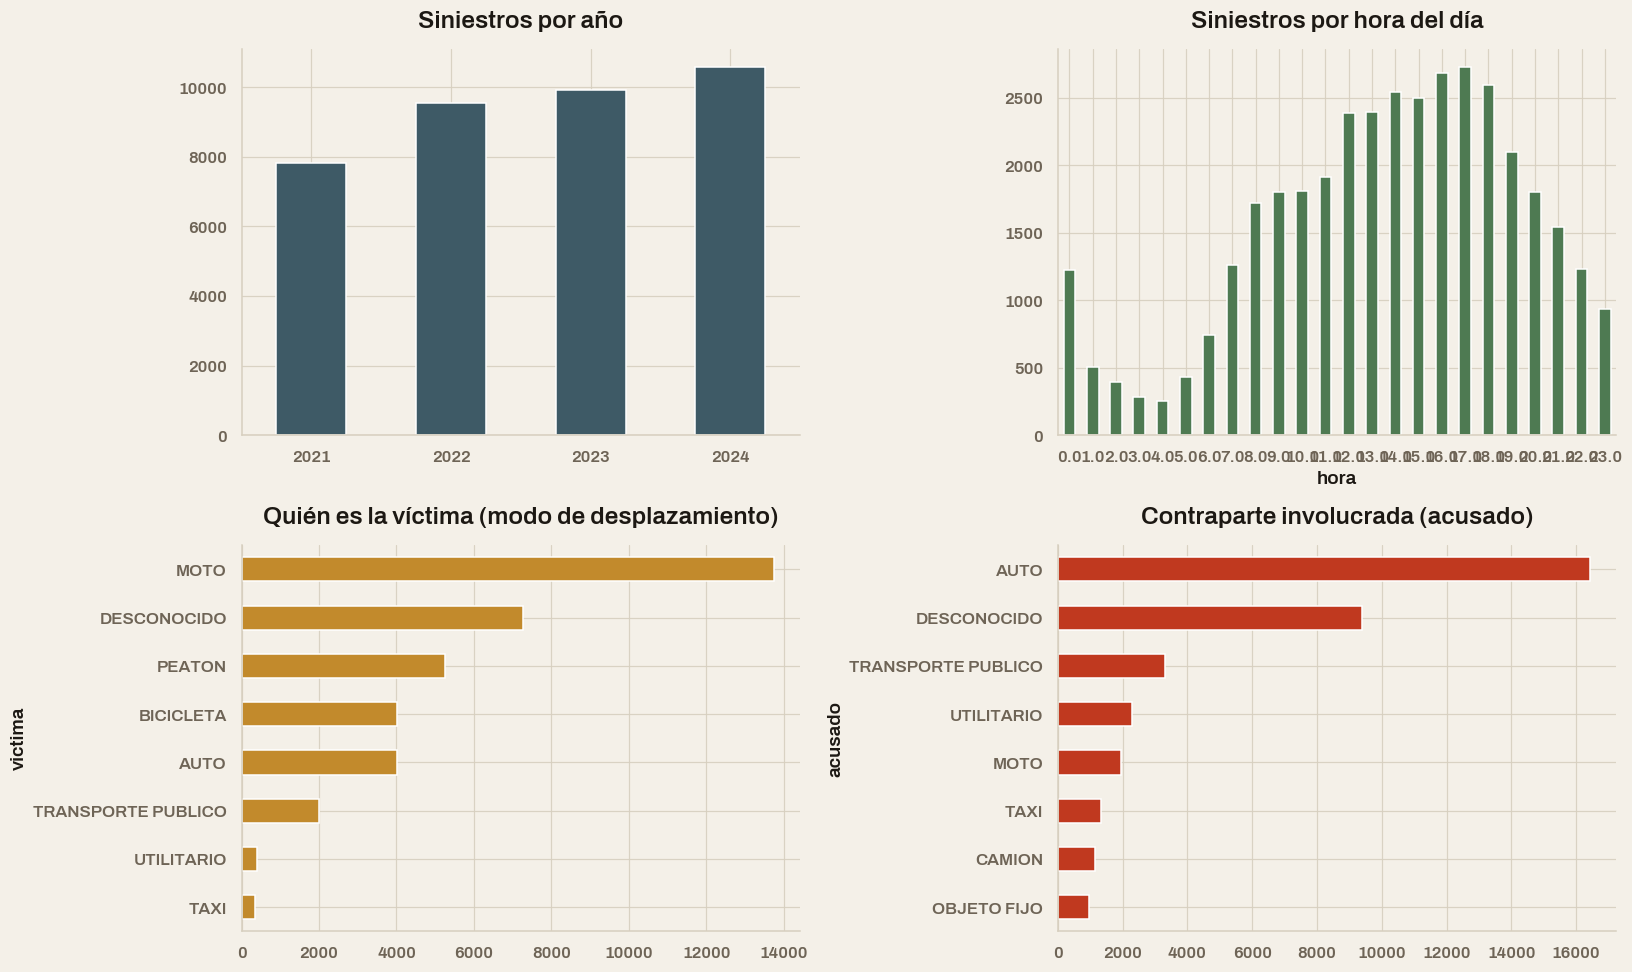

In [16]:
# ── Estadísticas generales: cuántos, cuándo, quiénes ──
if df_final is not None:
    print(f"Siniestros totales 2021-2024: {len(df_final):,}")
    print(f"Promedio: {len(df_final)/1461:.1f} por día")
    print(f"Severos (GRAVE + MORTAL): {df_final['gravedad'].isin(['GRAVE','MORTAL']).mean()*100:.2f}%")

    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    df_final.groupby('año').size().plot(kind='bar', ax=axes[0, 0], color='#3E5A66', edgecolor='white')
    axes[0, 0].set_title('Siniestros por año'); axes[0, 0].set_xlabel('')
    axes[0, 0].tick_params(axis='x', rotation=0)

    df_final.groupby('hora_num').size().plot(kind='bar', ax=axes[0, 1], color='#4E7A52', edgecolor='white')
    axes[0, 1].set_title('Siniestros por hora del día'); axes[0, 1].set_xlabel('hora')
    axes[0, 1].tick_params(axis='x', rotation=0)

    df_final['victima'].value_counts().head(8).sort_values().plot(
        kind='barh', ax=axes[1, 0], color='#C28A2C', edgecolor='white')
    axes[1, 0].set_title('Quién es la víctima (modo de desplazamiento)')

    df_final['acusado'].value_counts().head(8).sort_values().plot(
        kind='barh', ax=axes[1, 1], color='#C0391F', edgecolor='white')
    axes[1, 1].set_title('Contraparte involucrada (acusado)')

    plt.tight_layout()
    plt.savefig('outputs/estadisticas_generales.png', dpi=150, bbox_inches='tight')
    plt.show()

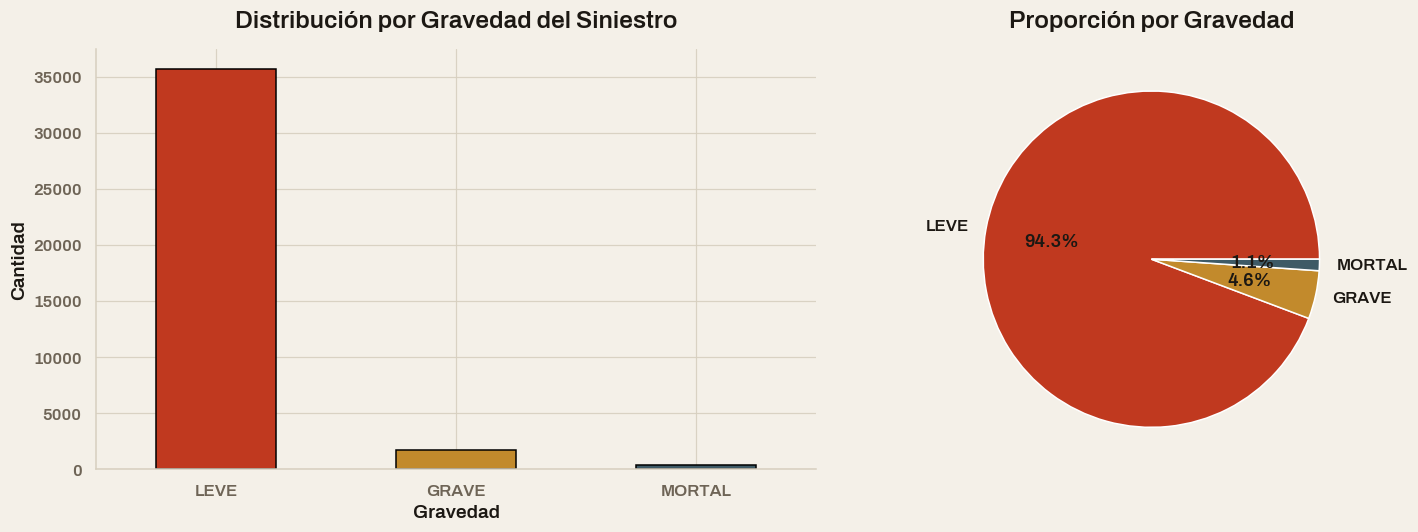

In [17]:
if df_final is not None:
    # ── Distribución de gravedad ──────────────────────────
    if 'gravedad' in df_final.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        df_final['gravedad'].value_counts().plot(
            kind='bar', ax=axes[0], color=['#C0391F', '#C28A2C', '#3E5A66'], edgecolor='black')
        axes[0].set_title('Distribución por Gravedad del Siniestro')
        axes[0].set_xlabel('Gravedad')
        axes[0].set_ylabel('Cantidad')
        axes[0].tick_params(axis='x', rotation=0)

        df_final['gravedad'].value_counts().plot(
            kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=['#C0391F', '#C28A2C', '#3E5A66'])
        axes[1].set_title('Proporción por Gravedad')
        axes[1].set_ylabel('')

        plt.tight_layout()
        plt.savefig('outputs/gravedad_distribucion.png', dpi=150, bbox_inches='tight')
        plt.show()


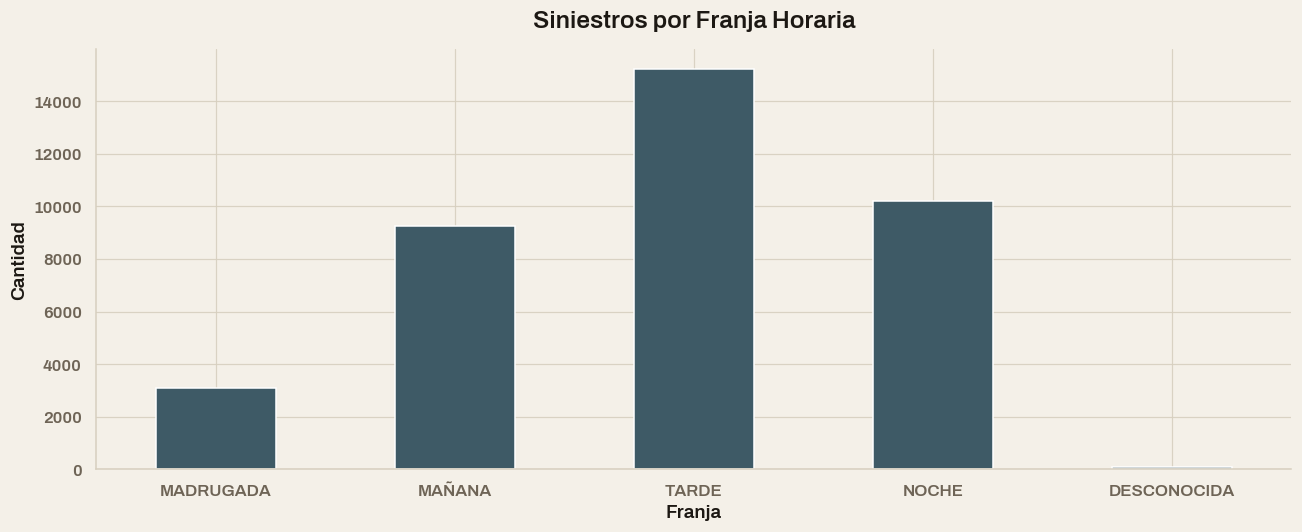

In [18]:
if df_final is not None:
    # ── Siniestros por franja horaria ─────────────────────
    if 'franja_horaria' in df_final.columns:
        orden = ['MADRUGADA', 'MAÑANA', 'TARDE', 'NOCHE', 'DESCONOCIDA']
        conteo = df_final['franja_horaria'].value_counts().reindex(orden).dropna()

        plt.figure()
        conteo.plot(kind='bar', color='#3E5A66', edgecolor='white')
        plt.title('Siniestros por Franja Horaria')
        plt.xlabel('Franja')
        plt.ylabel('Cantidad')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.savefig('outputs/siniestros_franja_horaria.png', dpi=150, bbox_inches='tight')
        plt.show()


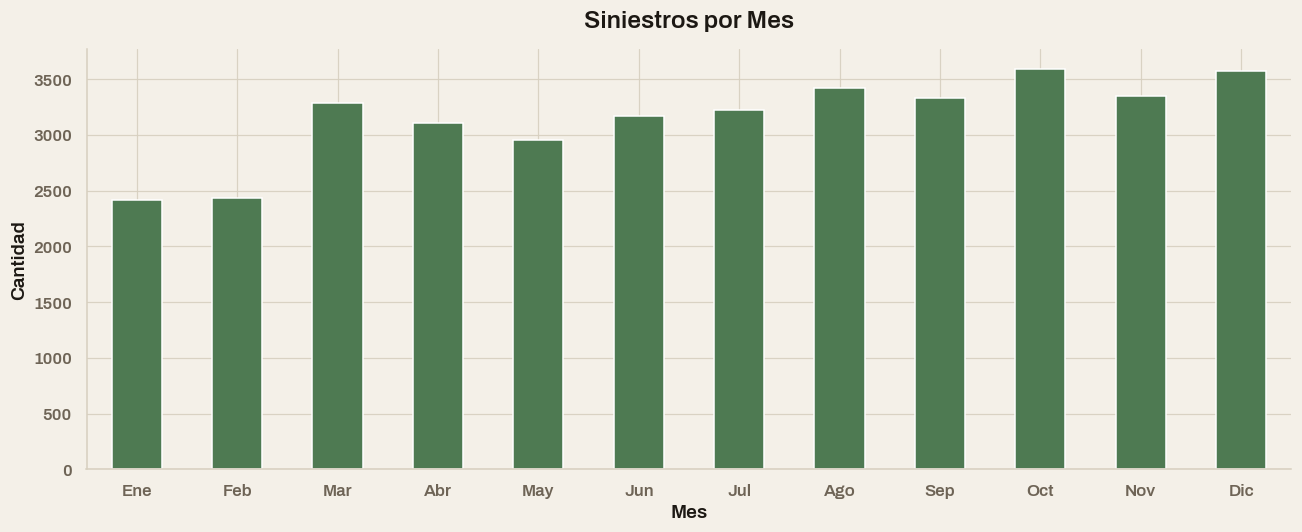

In [19]:
if df_final is not None:
    # ── Siniestros por mes ────────────────────────────────
    if 'mes' in df_final.columns:
        meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
        conteo_mes = df_final.groupby('mes').size()

        plt.figure()
        conteo_mes.plot(kind='bar', color='#4E7A52', edgecolor='white')
        plt.title('Siniestros por Mes')
        plt.xlabel('Mes')
        plt.ylabel('Cantidad')
        plt.xticks(ticks=range(12), labels=meses, rotation=0)
        plt.tight_layout()
        plt.savefig('outputs/siniestros_mes.png', dpi=150, bbox_inches='tight')
        plt.show()


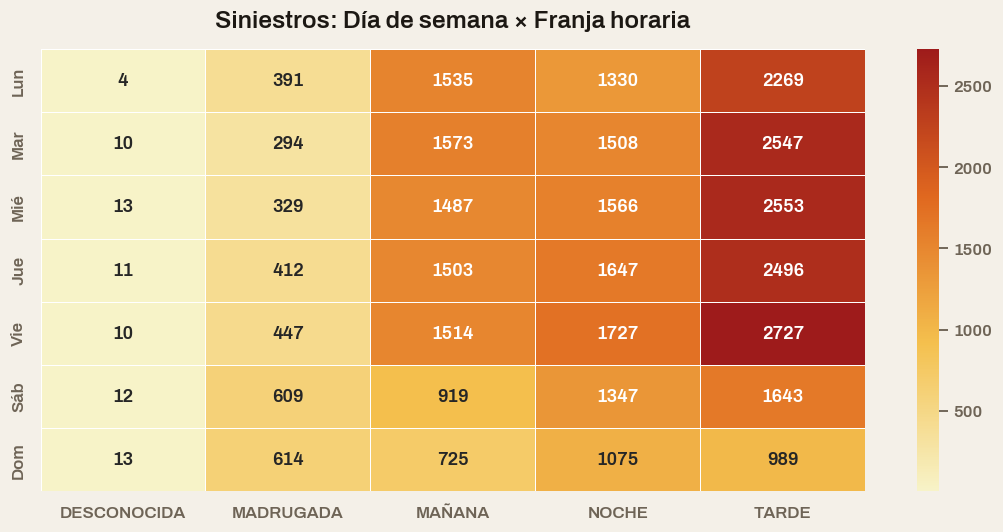

In [20]:
if df_final is not None:
    # ── Heatmap: día de semana × franja horaria ───────────
    if 'dia_semana' in df_final.columns and 'franja_horaria' in df_final.columns:
        dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
        pivot = df_final.groupby(['dia_semana', 'franja_horaria']).size().unstack(fill_value=0)
        pivot.index = [dias[i] for i in pivot.index if i < 7]

        plt.figure(figsize=(10, 5))
        _axhm = sns.heatmap(pivot, annot=True, fmt='d', cmap=CMAP_SEC, linewidths=0.5)
        _axhm.set_xlabel(''); _axhm.set_ylabel('')
        plt.title('Siniestros: Día de semana × Franja horaria')
        plt.tight_layout()
        plt.savefig('outputs/heatmap_dia_franja.png', dpi=150, bbox_inches='tight')
        plt.show()


### ¿Los días de lluvia tienen más siniestros?

**No — tienen MENOS (-8%), y el efecto es dosis-dependiente: con lluvia >20mm caen -21%.**
Se mantiene controlando por día de semana, y la composición de víctimas casi no cambia (moto 36,6% → 35,7%),
o sea que es una **reducción general de exposición**: con lluvia circula menos gente.
La gravedad del siniestro individual tampoco cambia (% SEVERO 5,7 seco vs 5,9 lluvia) — por eso
el clima no sirve como feature del clasificador de gravedad, pero **sí** para modelar la
**cantidad diaria** de siniestros (regresión, sección 10d).

Días secos: 1001 | con lluvia: 460
Siniestros/día — seco: 26.57 | lluvia: 24.45 (-8.0%)
Correlación de Pearson prcp vs n_siniestros: r = -0.108
  días hábiles: seco 29.3 vs lluvia 27.2 siniestros/día
  fin de semana: seco 19.4 vs lluvia 18.2 siniestros/día
  Mix de víctimas — % siniestros con moto: seco 36.6% | lluvia 35.7%
  % SEVERO — seco: 5.7% | lluvia: 5.9%


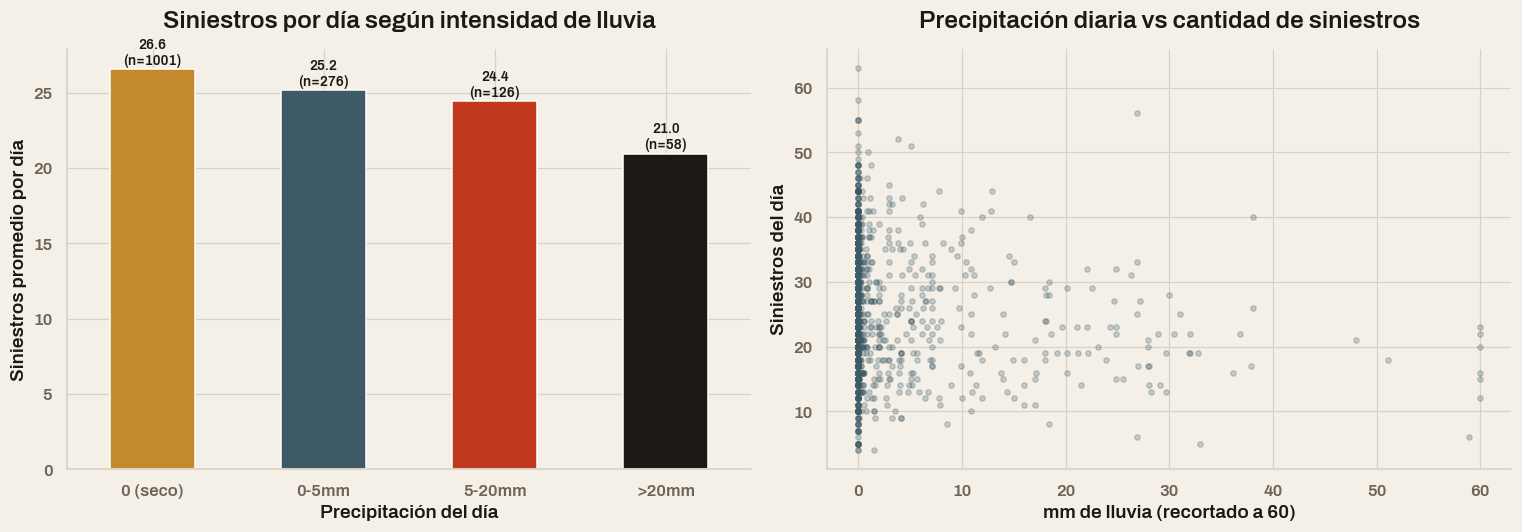

In [21]:
# Siniestros por día según lluvia (clima diario Meteostat)
if df_final is not None and df_clima_diario is not None:
    clima_d = df_clima_diario[df_clima_diario['fecha'].dt.year.between(2021, 2024)].copy()
    por_dia = df_final.groupby('fecha_siniestro').size().rename('n_siniestros')
    d = clima_d.set_index('fecha').join(por_dia).fillna({'n_siniestros': 0})

    seco   = d.loc[d['prcp'] == 0, 'n_siniestros']
    lluvia = d.loc[d['prcp'] > 0,  'n_siniestros']
    print(f"Días secos: {len(seco)} | con lluvia: {len(lluvia)}")
    print(f"Siniestros/día — seco: {seco.mean():.2f} | lluvia: {lluvia.mean():.2f} "
          f"({(lluvia.mean()/seco.mean()-1)*100:+.1f}%)")
    # Coeficiente de correlación de Pearson: lluvia del día vs cantidad de siniestros
    r = d['prcp'].corr(d['n_siniestros'])
    print(f"Correlación de Pearson prcp vs n_siniestros: r = {r:.3f}")

    # Respaldo de las afirmaciones del markdown: control por tipo de día, mix de moto, severidad
    d['finde'] = d.index.dayofweek >= 5
    for flag, lbl in [(False, 'días hábiles'), (True, 'fin de semana')]:
        s_ = d[d['finde'] == flag]
        print(f"  {lbl}: seco {s_.loc[s_['prcp'] == 0, 'n_siniestros'].mean():.1f} "
              f"vs lluvia {s_.loc[s_['prcp'] > 0, 'n_siniestros'].mean():.1f} siniestros/día")
    sec, llu = df_final[df_final['llovio_dia'] == 0], df_final[df_final['llovio_dia'] == 1]
    print(f"  Mix de víctimas — % siniestros con moto: seco {sec['hay_moto'].mean()*100:.1f}% | "
          f"lluvia {llu['hay_moto'].mean()*100:.1f}%")
    print(f"  % SEVERO — seco: {sec['gravedad'].isin(['GRAVE','MORTAL']).mean()*100:.1f}% | "
          f"lluvia: {llu['gravedad'].isin(['GRAVE','MORTAL']).mean()*100:.1f}%")

    bins = pd.cut(d['prcp'], [-0.1, 0, 5, 20, 1000],
                  labels=['0 (seco)', '0-5mm', '5-20mm', '>20mm'])
    resumen = d.groupby(bins, observed=True)['n_siniestros'].agg(['count', 'mean'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    resumen['mean'].plot(kind='bar', ax=axes[0], color=['#C28A2C', '#3E5A66', '#C0391F', '#1C1813'],
                         edgecolor='white')
    axes[0].set_title('Siniestros por día según intensidad de lluvia')
    axes[0].set_xlabel('Precipitación del día')
    axes[0].set_ylabel('Siniestros promedio por día')
    axes[0].tick_params(axis='x', rotation=0)
    for i, (m, n) in enumerate(zip(resumen['mean'], resumen['count'])):
        axes[0].text(i, m + 0.3, f'{m:.1f}\n(n={n})', ha='center', fontsize=9)

    axes[1].scatter(d['prcp'].clip(upper=60), d['n_siniestros'], alpha=0.25, s=12, color='#3E5A66')
    axes[1].set_title('Precipitación diaria vs cantidad de siniestros')
    axes[1].set_xlabel('mm de lluvia (recortado a 60)')
    axes[1].set_ylabel('Siniestros del día')

    plt.tight_layout()
    plt.savefig('outputs/lluvia_vs_siniestros.png', dpi=150, bbox_inches='tight')
    plt.show()

### Validación independiente: registros de Seguridad Vial de AUSA

BA Data publica además los **registros propios de AUSA** de incidentes en autopistas
(`seguridad-vial-autopistas-ausa`, 2022-2025, ~3.200 incidentes — universo distinto al de hechos:
incluye incidentes sin víctimas, no se puede mergear). Su valor único: registra la
**condición de la superficie en el momento del incidente** (SECA/MOJADA) — la medida de exposición
correcta para testear lluvia→severidad, en el tipo de vía donde más debería importar.


In [22]:
# Incidentes AUSA: ¿la superficie mojada aumenta la lesividad en autopistas?
if df_final is not None:
    sv = pd.read_csv(EXT + 'ausa_seguridad_vial_2022_2025.csv', low_memory=False)
    sup_col = [c for c in sv.columns if 'SUPERFICIE' in c][0]
    sv['LESIONADOS'] = pd.to_numeric(sv['LESIONADOS'], errors='coerce').fillna(0)
    sv['FALLECIDOS'] = pd.to_numeric(sv['FALLECIDOS'], errors='coerce').fillna(0)
    sv['con_victimas'] = (sv['LESIONADOS'] + sv['FALLECIDOS']) > 0
    sv['mojada'] = (sv[sup_col].astype(str).str.strip().str.upper()
                    .str.contains('MOJADA|HUMEDA|DESLIZANTE|ANEGADA', regex=True))

    print(f"Incidentes AUSA 2022-2025: {len(sv):,}")
    for lbl, m in [('SECA', ~sv['mojada']), ('MOJADA/HÚMEDA', sv['mojada'])]:
        s = sv[m]
        print(f"  {lbl:14s} n={len(s):5,} | % con víctimas: {s['con_victimas'].mean()*100:.1f}%"
              f" | fallecidos: {s['FALLECIDOS'].sum():.0f}")
    # Tabla de contingencia: condición de la superficie × resultado del incidente
    tabla_cont = pd.crosstab(sv['mojada'].map({False: 'SECA', True: 'MOJADA/HÚMEDA'}),
                             sv['con_victimas'].map({False: 'sin víctimas', True: 'con víctimas'}),
                             normalize='index') * 100
    print("\n  Tabla de contingencia (% por fila):")
    print(tabla_cont.round(1).to_string())

    moto_sv = pd.to_numeric(sv['MOTO'], errors='coerce').fillna(0) > 0
    print(f"\nMoto involucrada ({moto_sv.mean()*100:.0f}% de incidentes):"
          f" % con víctimas {sv[moto_sv]['con_victimas'].mean()*100:.0f}% vs sin moto {sv[~moto_sv]['con_victimas'].mean()*100:.0f}%")
    print("\n→ Aún a nivel incidente y en autopistas, la superficie mojada NO aumenta la lesividad"
          " (la reduce: la gente maneja más despacio). Confirmación independiente del"
          " hallazgo lluvia→frecuencia-sí/severidad-no. Y la moto cuadruplica la lesividad del incidente.")

Incidentes AUSA 2022-2025: 3,208
  SECA           n=2,945 | % con víctimas: 39.1% | fallecidos: 18
  MOJADA/HÚMEDA  n=  263 | % con víctimas: 27.8% | fallecidos: 4

  Tabla de contingencia (% por fila):
con_victimas   con víctimas  sin víctimas
mojada                                   
MOJADA/HÚMEDA          27.8          72.2
SECA                   39.1          60.9

Moto involucrada (36% de incidentes): % con víctimas 72% vs sin moto 19%

→ Aún a nivel incidente y en autopistas, la superficie mojada NO aumenta la lesividad (la reduce: la gente maneja más despacio). Confirmación independiente del hallazgo lluvia→frecuencia-sí/severidad-no. Y la moto cuadruplica la lesividad del incidente.


### Lluvia a nivel HORARIO: ¿llovía en el momento exacto del siniestro?

Tercera granularidad del clima (mensual → diaria → **horaria**, Open-Meteo/ERA5,
`clima_horario_openmeteo.csv`, 35.064 horas sin huecos). Solo el 9,4% de las horas tiene lluvia
(vs 31,5% de los días) — la medida de exposición más precisa posible:
- **Frecuencia:** -4,9% de siniestros por hora mientras llueve (consistente con el -8% diario)
- **Gravedad:** 5,6% vs 6,0% SEVERO — diferencia mínima. Hay un gradiente sugestivo con la
  intensidad (>5 mm/h → 8,2%) pero son apenas n=159 casos, muy poco para afirmarlo — queda como
  hipótesis (aquaplaning en lluvia torrencial), no como hallazgo.

In [23]:
# Lluvia en la hora exacta del siniestro (Open-Meteo horario)
if df_final is not None:
    ch = pd.read_csv(EXT + 'clima_horario_openmeteo.csv', parse_dates=['fecha_hora'])
    dfh = df_final[df_final['hora_num'].notna()].copy()
    dfh['fecha_hora'] = dfh['fecha_siniestro'] + pd.to_timedelta(dfh['hora_num'].astype(int), unit='h')
    dfh = dfh.merge(ch, on='fecha_hora', how='left')
    dfh['llovia_en_hora'] = dfh['prcp_mm'] > 0
    dfh['severo'] = dfh['gravedad'].isin(['GRAVE', 'MORTAL'])

    n_horas = (ch['prcp_mm'] > 0).value_counts()
    t_seco   = (~dfh['llovia_en_hora']).sum() / n_horas[False]
    t_lluvia = dfh['llovia_en_hora'].sum() / n_horas[True]
    print(f"Match horario: {dfh['prcp_mm'].notna().mean()*100:.0f}% de los siniestros con hora válida")
    print(f"FRECUENCIA — siniestros/hora: sin lluvia {t_seco:.3f} | lloviendo {t_lluvia:.3f}"
          f" ({(t_lluvia/t_seco-1)*100:+.1f}%)")

    sev = dfh.groupby('llovia_en_hora')['severo'].mean() * 100
    print(f"GRAVEDAD — % SEVERO: sin lluvia {sev[False]:.2f}% | lloviendo {sev[True]:.2f}% (diferencia mínima)")

    bins = pd.cut(dfh['prcp_mm'], [-0.1, 0, 1, 5, 100], labels=['0', '0-1mm/h', '1-5mm/h', '>5mm/h'])
    print('\nPor intensidad en la hora del siniestro:')
    print(dfh.groupby(bins, observed=True).agg(n=('severo', 'size'),
          pct_severo=('severo', lambda s: round(s.mean()*100, 2))).to_string())
    print('\n→ La conclusión se sostiene en las tres granularidades: la lluvia reduce la FRECUENCIA'
          ' y prácticamente no cambia la GRAVEDAD.')

Match horario: 100% de los siniestros con hora válida
FRECUENCIA — siniestros/hora: sin lluvia 1.082 | lloviendo 1.030 (-4.9%)
GRAVEDAD — % SEVERO: sin lluvia 5.63% | lloviendo 6.04% (diferencia mínima)

Por intensidad en la hora del siniestro:
             n  pct_severo
prcp_mm                   
0        34368        5.63
0-1mm/h   2540        5.87
1-5mm/h    709        6.21
>5mm/h     159        8.18

→ La conclusión se sostiene en las tres granularidades: la lluvia reduce la FRECUENCIA y prácticamente no cambia la GRAVEDAD.


## 7b. Analytics descriptivo (Fase 3)

Tres miradas complementarias al EDA visual: evolución temporal, tasas por comuna
normalizadas por población (Censo 2022, INDEC) y **combinaciones de variables**
(los cruces dicen más que las variables aisladas).


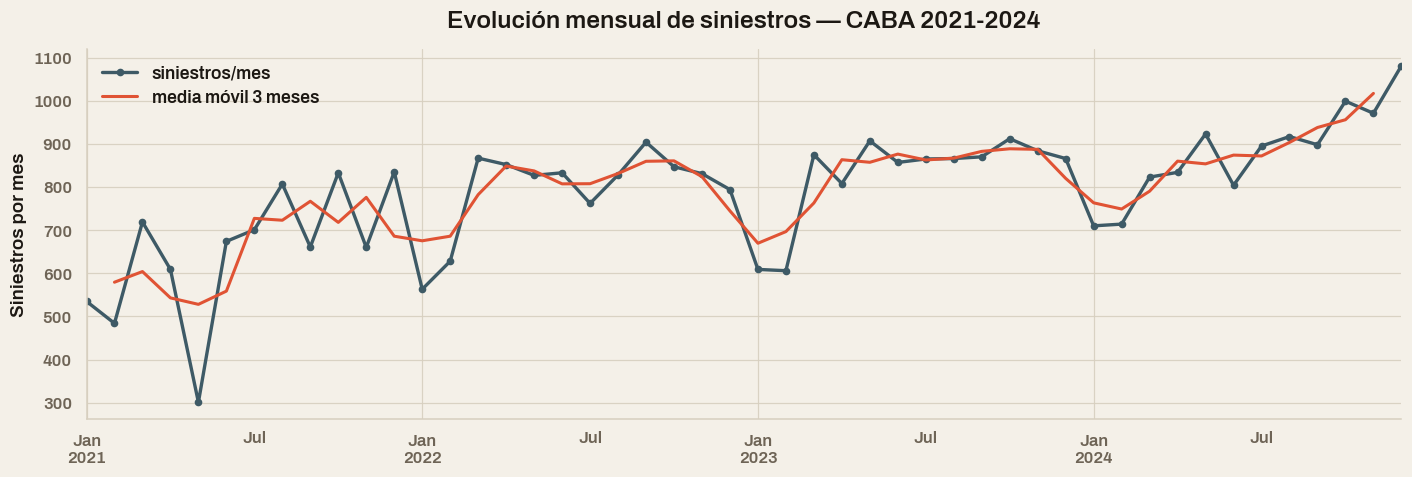

Siniestros por año: {np.int64(2021): 7819, np.int64(2022): 9536, np.int64(2023): 9925, np.int64(2024): 10569}
Crecimiento 2021→2024: +35.2%


In [24]:
# ── Serie temporal: siniestros por mes ───────────────────
if df_final is not None:
    serie = df_final.set_index('fecha_siniestro').resample('MS').size()

    plt.figure(figsize=(13, 4.5))
    serie.plot(marker='o', ms=4, color='#3E5A66', label='siniestros/mes')
    serie.rolling(3, center=True).mean().plot(color='#E05334', lw=2, label='media móvil 3 meses')
    plt.title('Evolución mensual de siniestros — CABA 2021-2024')
    plt.xlabel('')
    plt.ylabel('Siniestros por mes')
    plt.legend()
    plt.tight_layout()
    plt.savefig('outputs/serie_temporal_siniestros.png', dpi=150, bbox_inches='tight')
    plt.show()

    por_año = df_final.groupby('año').size()
    print('Siniestros por año:', por_año.to_dict())
    print(f"Crecimiento 2021→2024: {(por_año[2024]/por_año[2021]-1)*100:+.1f}%")

### Tasas por comuna (Censo 2022)

Los conteos crudos por comuna engañan: una comuna con más habitantes/tránsito tiene más siniestros
por exposición. Normalizamos por población (INDEC, Censo 2022 — `poblacion_comunas_censo2022.csv`,
total CABA 3.121.707) → **tasa anual de siniestros cada 100.000 habitantes**.

> ⚠️ La población **residente** no es lo mismo que la **exposición real**: la Comuna 1 (Microcentro)
> tiene pocos residentes pero recibe cientos de miles de personas por día — su tasa per cápita está
> inflada por tránsito de no-residentes. Normalizar por tránsito real no es posible: no existe dataset
> público de conteo vehicular con cobertura de CABA (los radares AUSA cubren solo 4 autopistas y el
> Anillo Digital murió en feb 2022 con 6-9 sensores). La tasa por habitante es el estándar
> epidemiológico cuando no hay medida de exposición.

✅ Población comunas (Censo 2022): 15 filas × 2 columnas


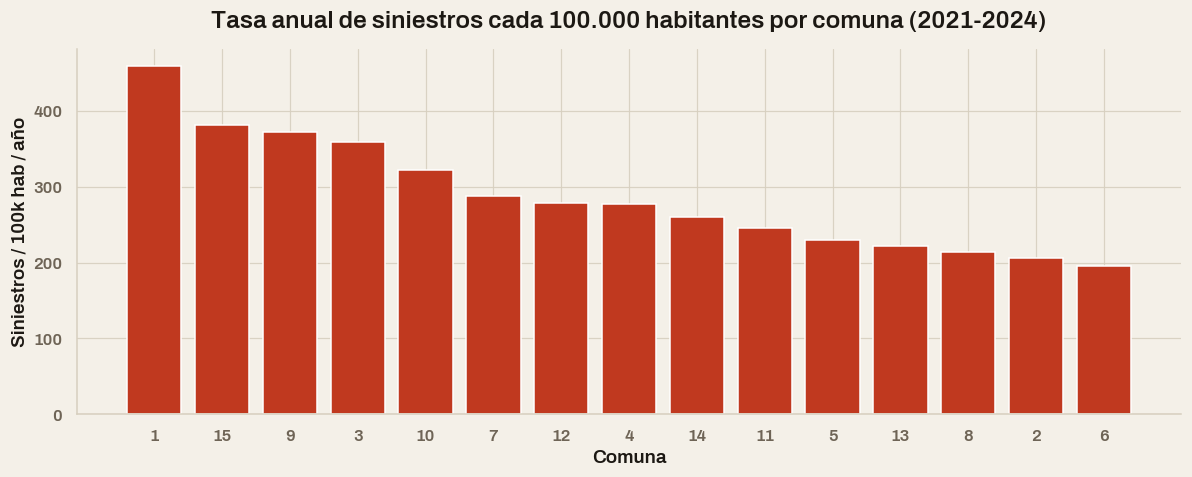

 comuna  poblacion  siniestros  tasa_anual_100k
      1     223554        4100            458.5
     15     196876        3005            381.6
      9     169063        2518            372.3
      3     196240        2822            359.5
     10     173004        2228            322.0
      7     215896        2489            288.2
     12     236887        2644            279.0
      4     229240        2539            276.9
     14     248635        2583            259.7
     11     204601        2006            245.1
      5     194271        1782            229.3
     13     264385        2342            221.5
      8     204367        1744            213.3
      2     161645        1336            206.6
      6     203043        1587            195.4



✅ Choropleth guardado en outputs/mapa_tasas_comunas.html


In [25]:
# ── Tasa anual de siniestros cada 100k habitantes por comuna ──
if df_final is not None:
    df_pob = cargar_csv(EXT + 'poblacion_comunas_censo2022.csv', 'Población comunas (Censo 2022)', encoding='utf-8')

    com = df_final['comuna_siniestro'].str.extract(r'(\d+)')[0].dropna().astype(int)
    tasa = (com.value_counts().rename_axis('comuna').rename('siniestros').reset_index()
            .merge(df_pob, on='comuna'))
    tasa['tasa_anual_100k'] = tasa['siniestros'] / 4 / tasa['poblacion'] * 100_000
    tasa = tasa.sort_values('tasa_anual_100k', ascending=False)

    plt.figure(figsize=(11, 4.5))
    plt.bar(tasa['comuna'].astype(str), tasa['tasa_anual_100k'], color='#C0391F', edgecolor='white')
    plt.title('Tasa anual de siniestros cada 100.000 habitantes por comuna (2021-2024)')
    plt.xlabel('Comuna')
    plt.ylabel('Siniestros / 100k hab / año')
    plt.tight_layout()
    plt.savefig('outputs/tasa_comunas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(tasa[['comuna', 'poblacion', 'siniestros', 'tasa_anual_100k']].round(1).to_string(index=False))

    # Choropleth interactivo (geojson oficial BA Data, key 'comuna')
    import importlib.util, json as _json
    if importlib.util.find_spec('folium') is not None:
        import folium
        geo = _json.load(open(EXT + 'comunas_caba.geojson'))
        m = folium.Map(location=[-34.61, -58.44], zoom_start=11, tiles='CartoDB positron')
        folium.Choropleth(
            geo_data=geo, data=tasa, columns=['comuna', 'tasa_anual_100k'],
            key_on='feature.properties.comuna', fill_color='YlOrRd',
            fill_opacity=0.75, line_opacity=0.4,
            legend_name='Siniestros anuales cada 100k habitantes'
        ).add_to(m)
        m.save('outputs/mapa_tasas_comunas.html')
        print("\n✅ Choropleth guardado en outputs/mapa_tasas_comunas.html")

### Combinaciones interesantes

Cruces de variables (más informativos que las variables aisladas). El quinto cruce clásico,
**velocidad × gravedad, no es posible con estos datos** — ningún dataset trae velocidad (los
radares cuentan vehículos, no miden velocidad); el mejor proxy es `tipo_de_calle`
(autopista ≈ alta velocidad), y ese gradiente aparece abajo.


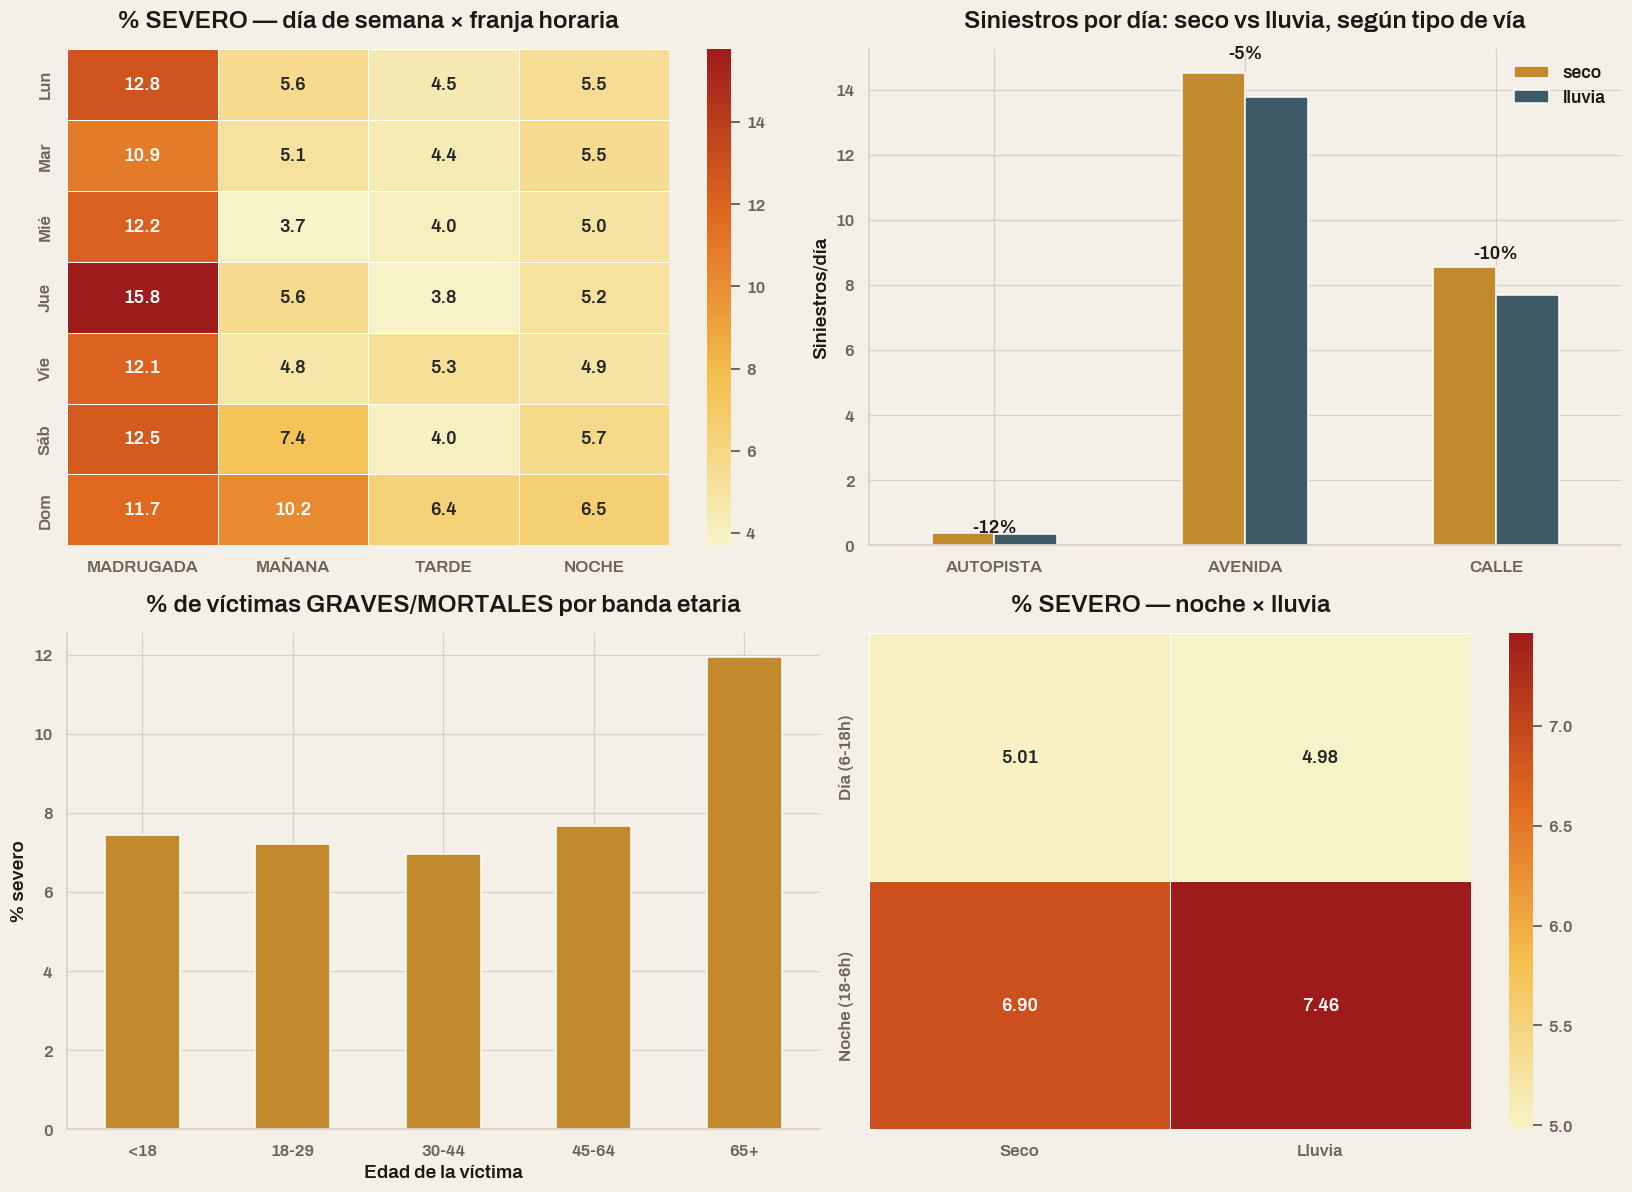

✅ Láminas separadas: combinaciones_cuando.png / combinaciones_quien_via.png
1) Madrugadas de sáb/dom: 1,223 siniestros vs 685 de lun+mar → ~2x. Y son MÁS severas: 12.1% vs 5.5% del resto.
2) La lluvia NO castiga más a las autopistas: la frecuencia baja en todos los tipos de vía (ver % en el gráfico). El gradiente de severidad por vía: CALLE 3.8% < AVENIDA 5.4% < AUTOPISTA 14.1% (proxy de velocidad).
3) Los jóvenes NO tienen los siniestros más severos: la banda crítica es 65+ (fragilidad).
4) Noche × lluvia: la noche es el factor dominante en severidad; la lluvia suma poco y además REDUCE la frecuencia (exposición).


In [26]:
# ── Combinaciones: hora×día / clima×vía / edad×gravedad / noche×lluvia ──
if df_final is not None and df_clima_diario is not None:
    df_final['severo'] = df_final['gravedad'].isin(['GRAVE', 'MORTAL'])
    n_dias = (df_clima_diario[df_clima_diario['fecha'].dt.year.between(2021, 2024)]
              ['llovio_dia'].value_counts())  # 0 = secos, 1 = lluvia

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    dias_lbl = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

    # 1) Hora × día de semana — % SEVERO (complementa el heatmap de conteos)
    piv = (df_final.groupby(['dia_semana', 'franja_horaria'])['severo'].mean() * 100).unstack()
    piv = piv[['MADRUGADA', 'MAÑANA', 'TARDE', 'NOCHE']]
    piv.index = [dias_lbl[int(i)] for i in piv.index]
    sns.heatmap(piv, annot=True, fmt='.1f', cmap=CMAP_SEC, linewidths=.5, ax=axes[0, 0])
    axes[0, 0].set_title('% SEVERO — día de semana × franja horaria')
    axes[0, 0].set_xlabel(''); axes[0, 0].set_ylabel('')

    # 2) Clima × tipo de vía — siniestros/día en seco vs lluvia
    tipos = ['AUTOPISTA', 'AVENIDA', 'CALLE']
    filas = []
    for t in tipos:
        sub = df_final[df_final['tipo_de_calle'] == t]
        filas.append({'tipo': t,
                      'seco':   (sub['llovio_dia'] == 0).sum() / n_dias[0],
                      'lluvia': (sub['llovio_dia'] == 1).sum() / n_dias[1]})
    cv = pd.DataFrame(filas).set_index('tipo')
    cv.plot(kind='bar', ax=axes[0, 1], color=['#C28A2C', '#3E5A66'], edgecolor='white')
    axes[0, 1].set_title('Siniestros por día: seco vs lluvia, según tipo de vía')
    axes[0, 1].set_xlabel(''); axes[0, 1].set_ylabel('Siniestros/día')
    axes[0, 1].tick_params(axis='x', rotation=0)
    for i, t in enumerate(tipos):
        d = (cv.loc[t, 'lluvia'] / cv.loc[t, 'seco'] - 1) * 100
        axes[0, 1].text(i, cv.loc[t].max() * 1.03, f'{d:+.0f}%', ha='center', fontweight='bold')

    # 3) Edad × gravedad (nivel víctima)
    if df_victimas is not None:
        v = df_victimas.copy()
        v['sev'] = v['gravedad_victima'].isin(['GRAVE', 'MORTAL'])
        bandas = pd.cut(v['edad_victima'], [0, 17, 29, 44, 64, 120],
                        labels=['<18', '18-29', '30-44', '45-64', '65+'])
        eg = v.groupby(bandas, observed=True)['sev'].mean() * 100
        eg.plot(kind='bar', ax=axes[1, 0], color='#C28A2C', edgecolor='white')
        axes[1, 0].set_title('% de víctimas GRAVES/MORTALES por banda etaria')
        axes[1, 0].set_xlabel('Edad de la víctima'); axes[1, 0].set_ylabel('% severo')
        axes[1, 0].tick_params(axis='x', rotation=0)

    # 4) Noche × lluvia — frecuencia y severidad
    df_final['noche'] = df_final['franja_horaria'].isin(['NOCHE', 'MADRUGADA'])
    nl = pd.DataFrame([{'noche': n, 'lluvia': ll,
                        'sin_dia': len(s) / n_dias[int(ll)],
                        'pct_severo': s['severo'].mean() * 100}
                       for n in [False, True] for ll in [False, True]
                       for s in [df_final[(df_final['noche'] == n) & (df_final['llovio_dia'] == int(ll))]]])
    pv = nl.pivot(index='noche', columns='lluvia', values='pct_severo')
    pv.index = ['Día (6-18h)', 'Noche (18-6h)']; pv.columns = ['Seco', 'Lluvia']
    sns.heatmap(pv, annot=True, fmt='.2f', cmap=CMAP_SEC, linewidths=.5, ax=axes[1, 1])
    axes[1, 1].set_title('% SEVERO — noche × lluvia')
    axes[1, 1].set_xlabel(''); axes[1, 1].set_ylabel('')

    plt.tight_layout()
    plt.savefig('outputs/combinaciones_interesantes.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Versiones separadas para informe/slides: el CUÁNDO y el QUIÉN/VÍA
    for nombre_fig, pares in [('combinaciones_cuando', [(0, 0), (1, 1)]),
                              ('combinaciones_quien_via', [(0, 1), (1, 0)])]:
        fig2, axs2 = plt.subplots(1, 2, figsize=(15, 5.5))
        for k, (fi, fj) in enumerate(pares):
            # redibujar el panel correspondiente
            if (fi, fj) == (0, 0):
                sns.heatmap(piv, annot=True, fmt='.1f', cmap=CMAP_SEC, linewidths=.5,
                            ax=axs2[k], annot_kws={'size': 12})
                axs2[k].set_title('% SEVERO — día de semana × franja horaria')
                axs2[k].set_xlabel(''); axs2[k].set_ylabel('')
            elif (fi, fj) == (1, 1):
                sns.heatmap(pv, annot=True, fmt='.2f', cmap=CMAP_SEC, linewidths=.5,
                            ax=axs2[k], annot_kws={'size': 13})
                axs2[k].set_title('% SEVERO — noche × lluvia')
                axs2[k].set_xlabel(''); axs2[k].set_ylabel('')
            elif (fi, fj) == (0, 1):
                cv.plot(kind='bar', ax=axs2[k], color=['#C28A2C', '#3E5A66'], edgecolor='white')
                axs2[k].set_title('Siniestros por día: seco vs lluvia, según tipo de vía')
                axs2[k].set_xlabel(''); axs2[k].set_ylabel('Siniestros/día')
                axs2[k].tick_params(axis='x', rotation=0)
                for i2, t2 in enumerate(tipos):
                    d2 = (cv.loc[t2, 'lluvia'] / cv.loc[t2, 'seco'] - 1) * 100
                    axs2[k].text(i2, cv.loc[t2].max() * 1.03, f'{d2:+.0f}%', ha='center', fontweight='bold')
            else:
                eg.plot(kind='bar', ax=axs2[k], color='#C28A2C', edgecolor='white')
                axs2[k].set_title('% de víctimas GRAVES/MORTALES por banda etaria')
                axs2[k].set_xlabel('Edad de la víctima'); axs2[k].set_ylabel('% severo')
                axs2[k].tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.savefig(f'outputs/{nombre_fig}.png', dpi=150, bbox_inches='tight')
        plt.close(fig2)
    print('✅ Láminas separadas: combinaciones_cuando.png / combinaciones_quien_via.png')

    # Respuestas en texto
    mad = df_final[df_final['franja_horaria'] == 'MADRUGADA'].groupby('dia_semana').size()
    sev_mf = df_final[(df_final['franja_horaria'] == 'MADRUGADA') & (df_final['dia_semana'] >= 5)]['severo'].mean() * 100
    sev_resto = df_final[~((df_final['franja_horaria'] == 'MADRUGADA') & (df_final['dia_semana'] >= 5))]['severo'].mean() * 100
    print(f"1) Madrugadas de sáb/dom: {mad.get(5, 0) + mad.get(6, 0):,} siniestros vs {mad.get(0, 0) + mad.get(1, 0):,} de lun+mar"
          f" → ~2x. Y son MÁS severas: {sev_mf:.1f}% vs {sev_resto:.1f}% del resto.")
    print(f"2) La lluvia NO castiga más a las autopistas: la frecuencia baja en todos los tipos de vía"
          f" (ver % en el gráfico). El gradiente de severidad por vía: CALLE "
          f"{df_final[df_final['tipo_de_calle']=='CALLE']['severo'].mean()*100:.1f}% < AVENIDA "
          f"{df_final[df_final['tipo_de_calle']=='AVENIDA']['severo'].mean()*100:.1f}% < AUTOPISTA "
          f"{df_final[df_final['tipo_de_calle']=='AUTOPISTA']['severo'].mean()*100:.1f}% (proxy de velocidad).")
    print("3) Los jóvenes NO tienen los siniestros más severos: la banda crítica es 65+ (fragilidad).")
    print("4) Noche × lluvia: la noche es el factor dominante en severidad; la lluvia suma poco"
          " y además REDUCE la frecuencia (exposición).")

### Velocidad de la vía y severidad: áreas de prioridad peatonal (20 km/h)

No existe dataset público de velocidad por calle (medida ni reglamentaria); el límite legal en CABA
lo fija el tipo de vía (calle 40 / avenida 60 / autopista 80+), o sea que `tipo_de_calle` ya es el
proxy de velocidad. El único corte adicional disponible son las **áreas de prioridad peatonal**
(BA Data: Microcentro, Casco Histórico, Tribunales, Once y Retiro — zonas 20 km/h), que cruzan
el gradiente completo: **20 km/h → 3,4% SEVERO · calle 40 → 3,8% · avenida 60 → 5,4% · autopista 80+ → 14,1%**.
La velocidad de la vía ordena la severidad de punta a punta (evidencia del mecanismo, no feature del modelo:
solo el 2% de los siniestros cae dentro de esas áreas — muestra chica).


Áreas 20 km/h: ['Microcentro', 'Casco Histórico', 'Tribunales', 'Once', 'Retiro']


Siniestros dentro: 712 (2.0%)
% SEVERO — dentro (20 km/h): 3.37% | fuera: 5.10%


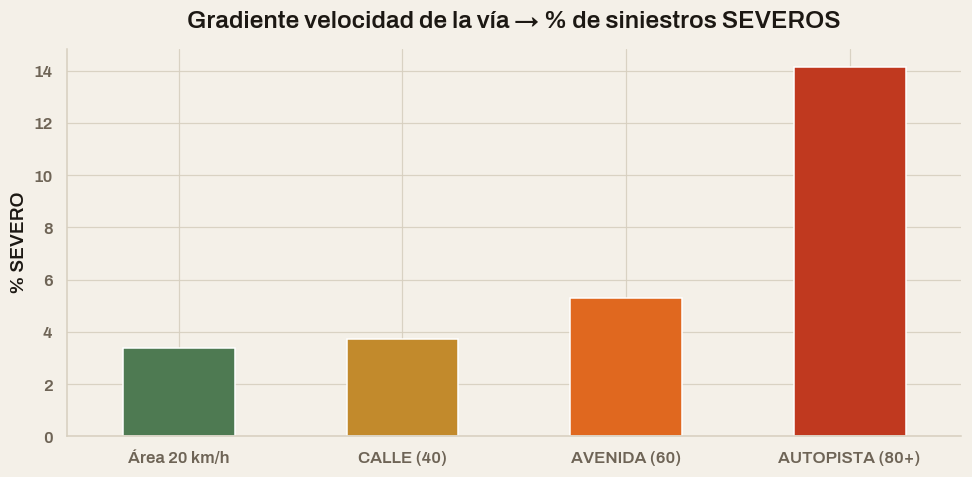

In [27]:
# Áreas de prioridad peatonal (20 km/h) vs severidad — requiere shapely
import importlib.util

if df_final is not None and importlib.util.find_spec('shapely') is not None:
    from shapely import wkt
    from shapely.prepared import prep
    from shapely.geometry import Point

    areas = pd.read_csv(EXT + 'areas_prioridad_peatonal.csv')
    polys = [prep(wkt.loads(w)) for w in areas['WKT']]
    print(f"Áreas 20 km/h: {areas['nombre'].tolist()}")

    geo_ok = (df_final['lat'].between(-34.75, -34.52) & df_final['lon'].between(-58.55, -58.33))
    sub = df_final[geo_ok].copy()
    sub['en_area_20'] = [any(p.contains(Point(lo, la)) for p in polys)
                         for lo, la in zip(sub['lon'], sub['lat'])]
    sub['severo'] = sub['gravedad'].isin(['GRAVE', 'MORTAL'])

    print(f"Siniestros dentro: {sub['en_area_20'].sum():,} ({sub['en_area_20'].mean()*100:.1f}%)")
    print(f"% SEVERO — dentro (20 km/h): {sub.loc[sub['en_area_20'], 'severo'].mean()*100:.2f}%"
          f" | fuera: {sub.loc[~sub['en_area_20'], 'severo'].mean()*100:.2f}%")

    # El gradiente completo velocidad → severidad
    grad = pd.Series({
        'Área 20 km/h': sub.loc[sub['en_area_20'], 'severo'].mean() * 100,
        'CALLE (40)':   sub.loc[sub['tipo_de_calle'] == 'CALLE', 'severo'].mean() * 100,
        'AVENIDA (60)': sub.loc[sub['tipo_de_calle'] == 'AVENIDA', 'severo'].mean() * 100,
        'AUTOPISTA (80+)': sub.loc[sub['tipo_de_calle'] == 'AUTOPISTA', 'severo'].mean() * 100,
    })
    plt.figure(figsize=(9, 4.5))
    grad.plot(kind='bar', color=['#4E7A52', '#C28A2C', '#E0681F', '#C0391F'], edgecolor='white')
    plt.title('Gradiente velocidad de la vía → % de siniestros SEVEROS')
    plt.ylabel('% SEVERO')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig('outputs/gradiente_velocidad_severidad.png', dpi=150, bbox_inches='tight')
    plt.show()

### Edad × fin de semana: ¿los jóvenes chocan más los findes?

**Sí.** La franja 18-29 pasa del 28,8% de las víctimas entre semana al **33,4% el fin de semana**
(+4,6 pp) y la edad mediana baja de 35 a 33. El efecto se concentra en la
**madrugada de finde**: mediana 31 años, y el 43,9% de esos siniestros tiene víctimas de
menos de 30 (vs 33,6% el resto del tiempo). Combinado con el hallazgo anterior (madrugada de
finde = 2× severidad), el perfil de riesgo queda completo: **jóvenes, de madrugada, en fin de
semana** — aunque la *severidad individual* por edad la dominan los 65+ (fragilidad).


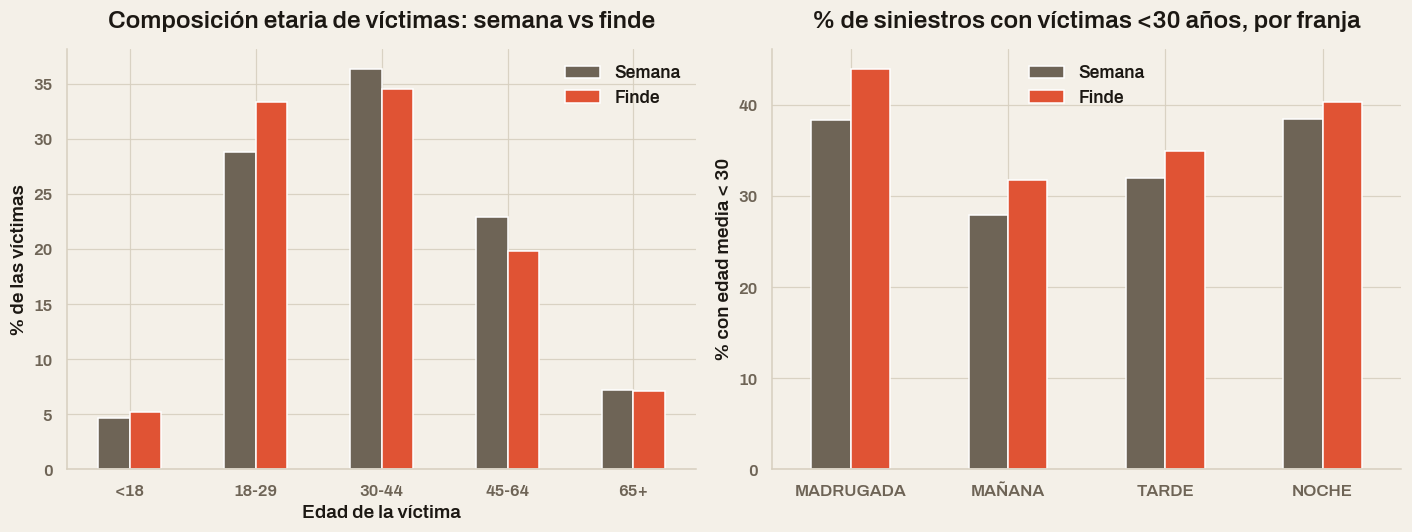

18-29 entre semana: 28.8% → finde: 33.4%
Edad mediana — semana: 35 | finde: 33
Madrugada de finde: mediana 31 años, 43.9% con víctimas <30 (sobre edad conocida)


In [28]:
# Edad × fin de semana (nivel víctima + zoom madrugada)
if df_victimas is not None and df_final is not None:
    v = df_victimas[df_victimas['edad_victima'].notna()].copy()
    v['finde'] = v['fecha_siniestro'].dt.dayofweek >= 5
    v['banda'] = pd.cut(v['edad_victima'], [0, 17, 29, 44, 64, 120],
                        labels=['<18', '18-29', '30-44', '45-64', '65+'])

    comp = v.groupby('finde')['banda'].value_counts(normalize=True).unstack(0) * 100
    comp.columns = ['Semana', 'Finde']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    comp.plot(kind='bar', ax=axes[0], color=['#6E6456', '#E05334'], edgecolor='white')
    axes[0].set_title('Composición etaria de víctimas: semana vs finde')
    axes[0].set_xlabel('Edad de la víctima'); axes[0].set_ylabel('% de las víctimas')
    axes[0].tick_params(axis='x', rotation=0)

    # Zoom: % de siniestros con víctimas jóvenes (<30) por franja, semana vs finde
    df_final['joven'] = df_final['edad_media'] < 30
    piv = (df_final[df_final['edad_media'].notna()]
           .groupby(['franja_horaria', 'es_fin_semana'])['joven'].mean() * 100).unstack()
    piv = piv.loc[['MADRUGADA', 'MAÑANA', 'TARDE', 'NOCHE']]
    piv.columns = ['Semana', 'Finde']
    piv.plot(kind='bar', ax=axes[1], color=['#6E6456', '#E05334'], edgecolor='white')
    axes[1].set_title('% de siniestros con víctimas <30 años, por franja')
    axes[1].set_xlabel(''); axes[1].set_ylabel('% con edad media < 30')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('outputs/edad_x_finde.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"18-29 entre semana: {comp.loc['18-29', 'Semana']:.1f}% → finde: {comp.loc['18-29', 'Finde']:.1f}%")
    print(f"Edad mediana — semana: {v.loc[~v['finde'], 'edad_victima'].median():.0f}"
          f" | finde: {v.loc[v['finde'], 'edad_victima'].median():.0f}")
    mf = df_final[(df_final['franja_horaria'] == 'MADRUGADA') & (df_final['es_fin_semana'] == 1)]
    print(f"Madrugada de finde: mediana {mf['edad_media'].median():.0f} años, "
          f"{(mf['edad_media'].dropna() < 30).mean()*100:.1f}% con víctimas <30 (sobre edad conocida)")

### ¿Qué cruces y arterias concentran los siniestros?

`direccion_normalizada` trae el **cruce** del hecho ("CALLE A y CALLE B", ~75% de cobertura), así que
podemos ponerle nombre a la concentración. Dos rankings: cruces exactos y arterias (cada dirección
"A y B" aporta a ambas calles).

> ⚠️ **Concentración ≠ riesgo individual.** Sin datos de flujo vehicular (descartados por cobertura)
> no podemos normalizar por exposición: una avenida con 10× más tránsito "debería" tener más siniestros
> aunque sea igual de segura por vehículo. Por eso este ranking dice *dónde están* los siniestros
> (útil para intervenir), no *qué tan peligrosa es* cada calle para quien la transita. Es el complemento
> con nombres del análisis DBSCAN (sección 10e), que encuentra lo mismo por densidad espacial.

Siniestros con dirección: 35,071 de 37,849 (93%)

Top 10 cruces por cantidad de siniestros (2021-2024):
                                               n  pct_severo
cruce                                                       
BALBIN, RICARDO, DR. AV. Y PAZ, GRAL. AV.    141         4.3
CABILDO AV. Y PAZ, GRAL. AV.                  61        14.8
DE LOS CONSTITUYENTES AV. Y PAZ, GRAL. AV.    59         5.1
9 DE JULIO AV. Y SAN JUAN AV.                 56         3.6
PAZ, GRAL. AV. Y PERON, EVA AV.               50         4.0
9 DE JULIO AV. Y CALVO, CARLOS                48         2.1
NAZARRE Y PAZ, GRAL. AV.                      46         6.5
PAZ, GRAL. AV. Y SUPERI                       44         6.8
ALBERDI, JUAN BAUTISTA AV. Y PAZ, GRAL. AV.   44         2.3
DEL LIBERTADOR AV. Y PAZ, GRAL. AV.           41         9.8

Top 10 arterias (una dirección 'A y B' cuenta para ambas):
                               n  pct_severo
arteria                                     
PAZ, GRAL. AV.

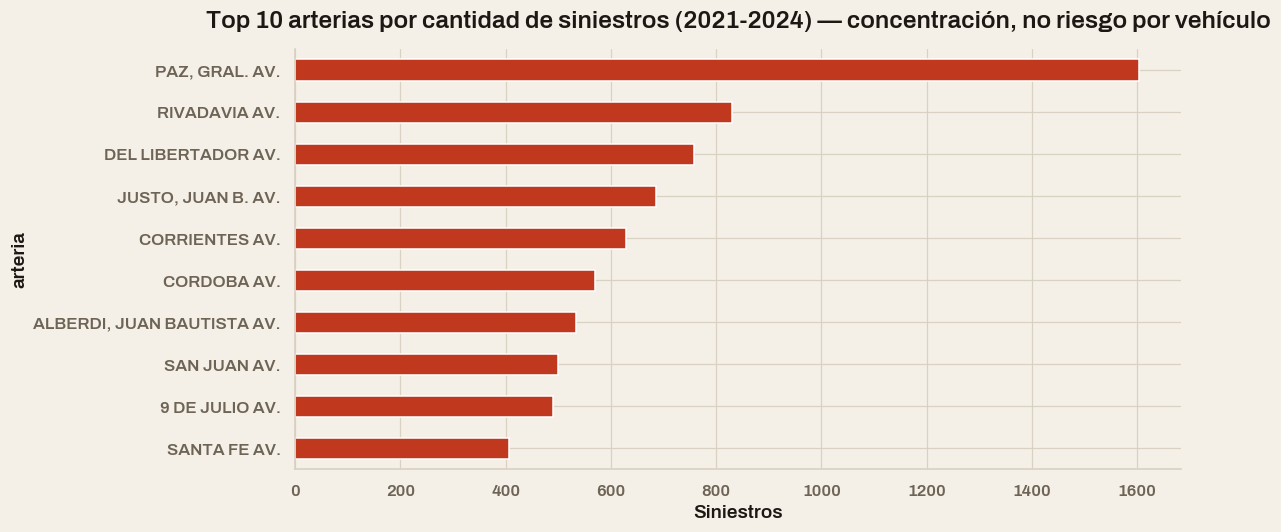

In [29]:
# ── Top cruces y arterias por cantidad de siniestros ──
if df_final is not None and 'direccion_normalizada_siniestro' in df_final.columns:
    df_final['severo'] = df_final['gravedad'].isin(['GRAVE', 'MORTAL'])
    d = df_final[['direccion_normalizada_siniestro', 'severo']].dropna()
    d = d.assign(dir=d['direccion_normalizada_siniestro'].str.strip())
    print(f"Siniestros con dirección: {len(d):,} de {len(df_final):,} ({len(d)/len(df_final)*100:.0f}%)\n")

    # Top 10 cruces exactos (mínimo 20 siniestros)
    # Canonicalizar: "A y B" y "B y A" son el mismo cruce → ordenamos las partes
    d['cruce'] = d['dir'].str.split(' Y ').apply(lambda p: ' Y '.join(sorted(x.strip() for x in p)))
    top_cruces = (d.groupby('cruce').agg(n=('severo', 'size'), pct_severo=('severo', 'mean'))
                    .query('n >= 20').sort_values('n', ascending=False).head(10))
    top_cruces['pct_severo'] = (top_cruces['pct_severo'] * 100).round(1)
    print("Top 10 cruces por cantidad de siniestros (2021-2024):")
    print(top_cruces.to_string())

    # Top 10 arterias: cada dirección "A y B" cuenta para ambas calles
    partes = d.assign(arteria=d['dir'].str.split(' Y ')).explode('arteria')
    partes['arteria'] = partes['arteria'].str.strip()
    partes = partes[partes['arteria'].str.len() > 3]
    top_art = (partes.groupby('arteria').agg(n=('severo', 'size'), pct_severo=('severo', 'mean'))
                 .query('n >= 100').sort_values('n', ascending=False).head(10))
    top_art['pct_severo'] = (top_art['pct_severo'] * 100).round(1)
    print("\nTop 10 arterias (una dirección 'A y B' cuenta para ambas):")
    print(top_art.to_string())

    fig, ax = plt.subplots(figsize=(11, 5))
    top_art.sort_values('n')['n'].plot(kind='barh', ax=ax, color='#C0391F', edgecolor='white')
    ax.set_title('Top 10 arterias por cantidad de siniestros (2021-2024) — concentración, no riesgo por vehículo')
    ax.set_xlabel('Siniestros')
    plt.tight_layout()
    plt.savefig('outputs/top_arterias.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7c. ¿Más siniestros porque hay más tránsito? Normalización por exposición

Los siniestros crecieron **+35% entre 2021 y 2024**. La pregunta honesta es: ¿empeoró la seguridad
vial, o simplemente **circulan más vehículos** (recuperación post-pandemia)? Hasta acá no podíamos
responderla: los radares AUSA y el Anillo Digital no tienen cobertura. Dos fuentes nuevas lo resuelven:

- **Peajes de autopistas (IDECBA/AUSA)** — vehículos que pasan por cada peaje, mensual 2014-2026
  (`peajes_autopistas_idecba.csv`). Es el único conteo vehicular *continuo* de la Ciudad → lo usamos
  como **proxy del tránsito general** (asume que el tránsito de autopistas acompaña al de superficie).
- **Sensores de volumen vehicular (BA Data)** — conteos 2024 en 95 puntos de avenidas y autopistas
  (`volumen_vehicular_2024.csv`) → permite normalizar las arterias del ranking anterior.

Correlación de Pearson tránsito vs siniestros (48 meses): r = 0.878

            veh  siniestros  sin_por_Mveh
año                                      
2021  114746667        7819          68.1
2022  134118364        9536          71.1
2023  140428448        9925          70.7
2024  140397345       10569          75.3

Descomposición del crecimiento 2021→2024:
  Siniestros:            +35.2%
  Tránsito (exposición): +22.4%  ← explica ~2/3 del aumento
  Tasa por millón veh.:  +10.5%  ← el tercio restante es suba real de riesgo


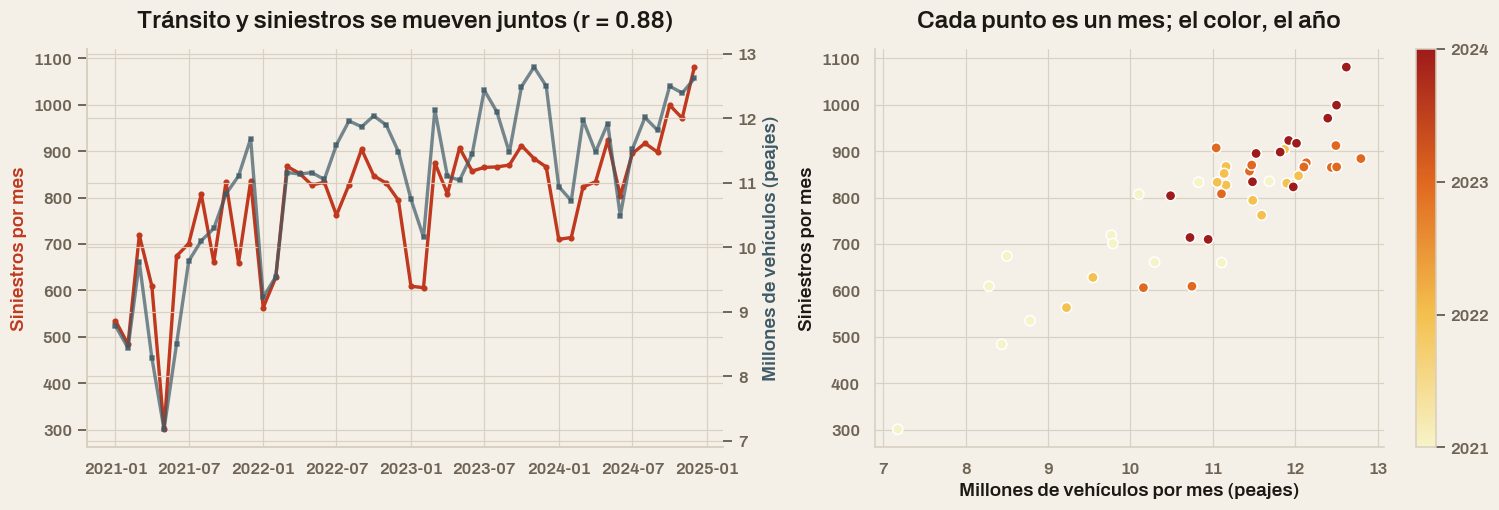

In [30]:
# ── Macro: tránsito mensual (peajes) vs siniestros mensuales ──
if df_final is not None:
    pj = pd.read_csv(EXT + 'peajes_autopistas_idecba.csv')
    pj = pj[pj['año'].between(2021, 2024)]
    sm = (df_final.groupby([df_final['año'].rename('año'), df_final['mes'].rename('mes')])
          .size().rename('siniestros').reset_index())
    mensual = pj[['año', 'mes', 'total']].merge(sm, on=['año', 'mes'])

    r = mensual['total'].corr(mensual['siniestros'])
    print(f"Correlación de Pearson tránsito vs siniestros (48 meses): r = {r:.3f}\n")

    anual = mensual.groupby('año').agg(veh=('total', 'sum'), siniestros=('siniestros', 'sum'))
    anual['sin_por_Mveh'] = anual['siniestros'] / (anual['veh'] / 1e6)
    print(anual.round(1).to_string())

    g_veh = anual.loc[2024, 'veh'] / anual.loc[2021, 'veh'] - 1
    g_sin = anual.loc[2024, 'siniestros'] / anual.loc[2021, 'siniestros'] - 1
    g_tasa = anual.loc[2024, 'sin_por_Mveh'] / anual.loc[2021, 'sin_por_Mveh'] - 1
    print(f"\nDescomposición del crecimiento 2021→2024:")
    print(f"  Siniestros:            {g_sin:+.1%}")
    print(f"  Tránsito (exposición): {g_veh:+.1%}  ← explica ~2/3 del aumento")
    print(f"  Tasa por millón veh.:  {g_tasa:+.1%}  ← el tercio restante es suba real de riesgo")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    fechas = pd.to_datetime(mensual['año'].astype(str) + '-' + mensual['mes'].astype(str) + '-01')
    ax2 = axes[0].twinx()
    axes[0].plot(fechas, mensual['siniestros'], 'o-', ms=3, color='#C0391F', label='siniestros/mes')
    ax2.plot(fechas, mensual['total'] / 1e6, 's-', ms=3, color='#3E5A66', alpha=0.7, label='M vehículos/mes')
    axes[0].set_ylabel('Siniestros por mes', color='#C0391F')
    ax2.set_ylabel('Millones de vehículos (peajes)', color='#3E5A66')
    axes[0].set_title(f'Tránsito y siniestros se mueven juntos (r = {r:.2f})')

    axes[1].scatter(mensual['total'] / 1e6, mensual['siniestros'], c=mensual['año'],
                    cmap=CMAP_SEC, s=45, edgecolor='white')
    axes[1].set_xlabel('Millones de vehículos por mes (peajes)')
    axes[1].set_ylabel('Siniestros por mes')
    axes[1].set_title('Cada punto es un mes; el color, el año')
    cb = plt.colorbar(axes[1].collections[0], ax=axes[1])
    cb.set_ticks([2021, 2022, 2023, 2024])
    plt.tight_layout()
    plt.savefig('outputs/transito_vs_siniestros.png', dpi=150, bbox_inches='tight')
    plt.show()

### Hallazgo: el aumento de siniestros es ~2/3 exposición, ~1/3 riesgo

El tránsito mensual y los siniestros mensuales se mueven **juntos** (r ≈ 0,88). Descomponiendo el
crecimiento 2021→2024: el tránsito subió **+22%** y la tasa de siniestros por millón de vehículos
**+10%** (68 → 75). Es decir: **la mayor parte del "+35% de siniestros" no es que manejar se volvió
más peligroso — es que volvió el tránsito** después de la pandemia. Pero no todo: la tasa por
vehículo también subió, y eso sí es deterioro real de la seguridad vial.

> Este es el tipo de control que cambia la lectura de una estadística: sin normalizar por exposición,
> "+35% de siniestros" sugiere una crisis; normalizado, dos tercios son simplemente más autos en la calle.

In [31]:
# ── Autopistas: tasa de siniestros por millón de vehículos (2021-2024) ──
if df_final is not None:
    veh = pj[cols_peajes := ['alberti', 'avellaneda', 'dellepiane', 'illia', 'retiro',
                             'sarmiento', 'salguero']].sum()
    # peaje → autopista: Alberti→25 de Mayo · Avellaneda→Perito Moreno ·
    # Dellepiane→Dellepiane · Illia/Retiro/Sarmiento/Salguero→Illia
    flujo_M = {'25 DE MAYO': veh['alberti'] / 1e6,
               'PERITO MORENO': veh['avellaneda'] / 1e6,
               'DELLEPIANE': veh['dellepiane'] / 1e6,
               'ILLIA': (veh['illia'] + veh['retiro'] + veh['sarmiento'] + veh['salguero']) / 1e6}

    au = df_final[(df_final['tipo_de_calle'] == 'AUTOPISTA')
                  & df_final['direccion_normalizada_siniestro'].notna()].copy()
    dirs = au['direccion_normalizada_siniestro'].str.upper()
    filas = []
    for pat, M in flujo_M.items():
        m = dirs.str.contains(pat)
        filas.append({'autopista': pat.title(), 'siniestros': int(m.sum()),
                      'M_vehiculos': round(M, 1),
                      'por_millon': round(m.sum() / M, 2),
                      'pct_severo': round(au.loc[m, 'severo'].mean() * 100, 1)})
    tabla_au = pd.DataFrame(filas).set_index('autopista').sort_values('por_millon', ascending=False)
    print("Tasa de siniestros por millón de vehículos que pagan peaje (2021-2024):")
    print(tabla_au.to_string())

    # Corredor oeste combinado: Perito Moreno y 25 de Mayo comparten flujo
    # (un vehículo que entra por Avellaneda sigue a 25 de Mayo sin pasar por Alberti)
    n_oeste = tabla_au.loc[['25 De Mayo', 'Perito Moreno'], 'siniestros'].sum()
    M_oeste = tabla_au.loc[['25 De Mayo', 'Perito Moreno'], 'M_vehiculos'].sum()
    print(f"\nCorredor oeste (25 de Mayo + Perito Moreno, flujo compartido): "
          f"{n_oeste} siniestros / {M_oeste:.0f}M → {n_oeste / M_oeste:.2f} por millón")
    print("\n⚠️ El peaje cuenta pasadas por la cabina, no vehículos-km: la tasa de 25 de Mayo aislada"
          "\n   está inflada (mucho de su tránsito paga en Avellaneda). El corredor combinado es la"
          "\n   comparación honesta: aun así, el corredor oeste quintuplica la tasa de Illia.")

    # ── ¿Por qué la Illia tiene los siniestros más graves? Firma de velocidad ──
    sev_illia = au[dirs.str.contains('ILLIA') & au['severo']]
    print(f"\nLos {len(sev_illia)} severos de la Illia — todos MORTALES:")
    print(sev_illia[['victima', 'acusado', 'franja_horaria', 'gravedad']].to_string(index=False))
    noct = {p: (au.loc[dirs.str.contains(p), 'franja_horaria'] == 'NOCHE').mean() * 100
            for p in flujo_M}
    print(f"\n% de siniestros NOCTURNOS por autopista: " +
          " · ".join(f"{k.title()} {v:.0f}%" for k, v in sorted(noct.items(), key=lambda x: -x[1])))
    print("→ La Illia es la autopista más nocturna y sus severos incluyen choques contra OBJETO FIJO")
    print("  de noche/madrugada — la firma del exceso de velocidad en flujo libre. Con n chico es una")
    print("  señal cualitativa, no una estadística.")

    # ── Validación con el registro completo de AUSA (incluye incidentes sin víctimas) ──
    sv_val = pd.read_csv(EXT + 'ausa_seguridad_vial_2022_2025.csv', low_memory=False)
    inc = sv_val['AUTOPISTA'].astype(str).str.strip().str.upper().value_counts()
    print(f"\nValidación independiente — incidentes totales registrados por AUSA (2022-2025):")
    print(f"  25 de Mayo {inc.get('AU 25 DE MAYO', 0)} · Dellepiane {inc.get('AU DELLEPIANE', 0)}"
          f" · Perito Moreno {inc.get('AU PERITO MORENO', 0)} · Illia {inc.get('AU ILLIA', 0)}")
    print("→ El registro completo de AUSA confirma el patrón: la Illia tiene ~4,5× menos incidentes")
    print("  que la 25 de Mayo. 'Pocos choques' no es un artefacto de nuestro dataset.")
    print("\n⚠️ Atribución por nombre: ~la mitad de los siniestros de autopista no nombra cuál")
    print("  (dirección vacía o 'AU.' genérica) → los conteos por autopista son un piso; el faltante")
    print("  afecta a todas por igual, así que el ranking comparativo se sostiene.")

Tasa de siniestros por millón de vehículos que pagan peaje (2021-2024):
               siniestros  M_vehiculos  por_millon  pct_severo
autopista                                                     
25 De Mayo             76         28.0        2.71        22.4
Dellepiane             74        121.0        0.61        14.9
Perito Moreno          43        189.0        0.23        20.9
Illia                  17        163.9        0.10        29.4

Corredor oeste (25 de Mayo + Perito Moreno, flujo compartido): 119 siniestros / 217M → 0.55 por millón

⚠️ El peaje cuenta pasadas por la cabina, no vehículos-km: la tasa de 25 de Mayo aislada
   está inflada (mucho de su tránsito paga en Avellaneda). El corredor combinado es la
   comparación honesta: aun así, el corredor oeste quintuplica la tasa de Illia.

Los 5 severos de la Illia — todos MORTALES:
victima     acusado franja_horaria gravedad
   MOTO      CAMION          NOCHE   MORTAL
   AUTO OBJETO FIJO          NOCHE   MORTAL
   MOTO  UT

Arterias con sensor 2024 — índice de siniestros por millón de vehículos (en el punto medido):
                                   siniestros_2024  veh_dia_punto  indice_por_Mveh
arteria                                                                           
RIVADAVIA AV.                                  249          10452            65.09
JUSTO, JUAN B. AV.                             177           8919            54.22
SANTA FE AV.                                   134           7759            47.18
PERON, EVA AV.                                  88           5233            45.94
GARAY, JUAN DE AV.                              94           9950            25.81
DEL LIBERTADOR AV.                             235          25028            25.65
CASEROS AV.                                     39           4175            25.52
CABILDO AV.                                    107          12506            23.38
BEIRO, FRANCISCO AV.                            55           6916           

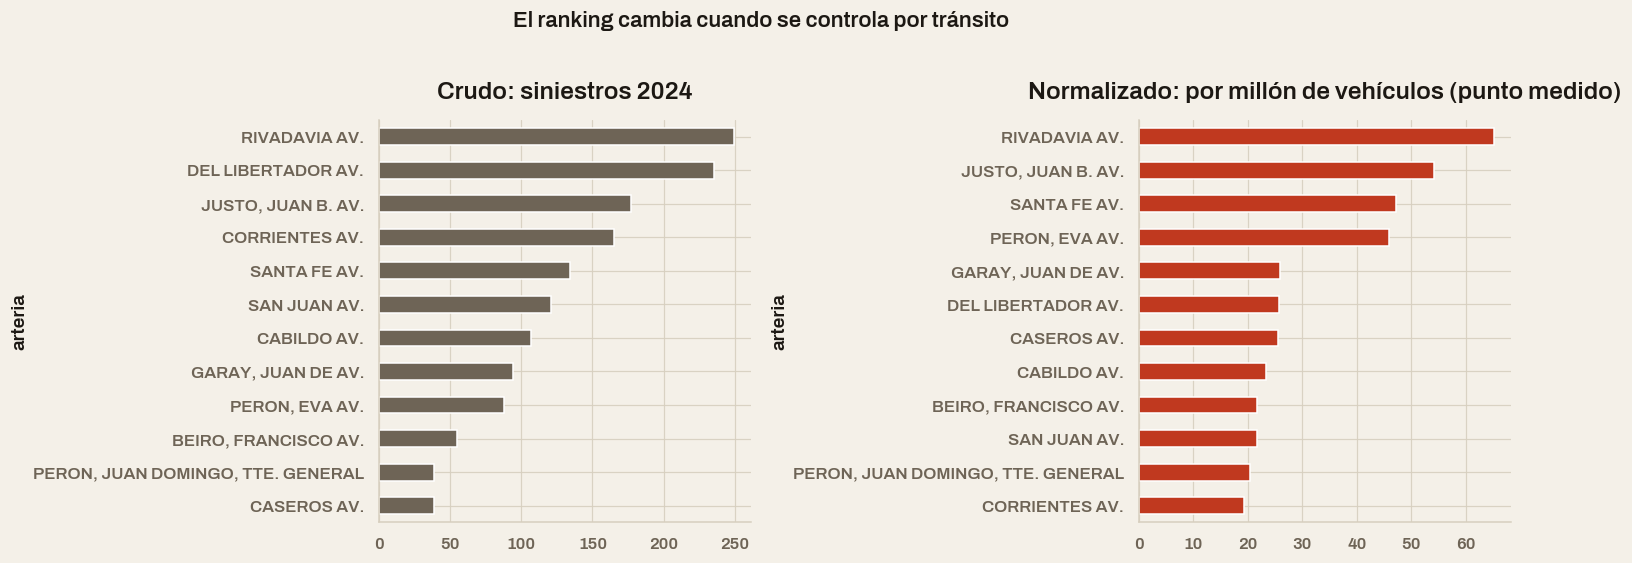


⚠️ El sensor mide UN punto de la arteria (no toda su extensión): el índice es comparativo,
   no una tasa absoluta. Aun así, el contraste crudo vs normalizado muestra que parte del
   ranking de arterias 'peligrosas' es solo que llevan más tránsito.


In [32]:
# ── Arterias normalizadas por tránsito (sensores 2024) ──
if df_final is not None:
    vv = pd.read_csv(EXT + 'volumen_vehicular_2024.csv')
    sens = (vv[vv['especificacion_via_conteos'] == 'calle_avenida']
            .groupby('ubicacion_conteo')['conteo_vehiculos'].mean())

    # siniestros 2024 por arteria (mismo parsing que el ranking anterior)
    d24 = df_final[(df_final['año'] == 2024) & df_final['direccion_normalizada_siniestro'].notna()]
    partes = (d24.assign(arteria=d24['direccion_normalizada_siniestro'].str.strip().str.split(' Y '))
              .explode('arteria'))
    partes['arteria'] = partes['arteria'].str.strip()
    sin24 = partes.groupby('arteria').agg(n=('severo', 'size'), pct_severo=('severo', 'mean'))

    filas = []
    for arteria in sin24[sin24['n'] >= 25].index:
        base = arteria.replace(' AV.', '').split(',')[0].strip()
        if len(base) < 5:
            continue
        hits = [u for u in sens.index if base in u.upper()]
        if hits:
            veh_dia = sens[hits].mean()  # promedio si hay más de un sensor
            filas.append({'arteria': arteria, 'siniestros_2024': int(sin24.loc[arteria, 'n']),
                          'veh_dia_punto': int(veh_dia),
                          'indice_por_Mveh': round(sin24.loc[arteria, 'n'] / (veh_dia * 366 / 1e6), 2)})
    norm = (pd.DataFrame(filas).set_index('arteria')
            .sort_values('indice_por_Mveh', ascending=False).head(12))
    print("Arterias con sensor 2024 — índice de siniestros por millón de vehículos (en el punto medido):")
    print(norm.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    norm.sort_values('siniestros_2024')['siniestros_2024'].plot(
        kind='barh', ax=axes[0], color='#6E6456', edgecolor='white')
    axes[0].set_title('Crudo: siniestros 2024')
    norm.sort_values('indice_por_Mveh')['indice_por_Mveh'].plot(
        kind='barh', ax=axes[1], color='#C0391F', edgecolor='white')
    axes[1].set_title('Normalizado: por millón de vehículos (punto medido)')
    plt.suptitle('El ranking cambia cuando se controla por tránsito', y=1.02)
    plt.tight_layout()
    plt.savefig('outputs/arterias_normalizadas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n⚠️ El sensor mide UN punto de la arteria (no toda su extensión): el índice es comparativo,"
          "\n   no una tasa absoluta. Aun así, el contraste crudo vs normalizado muestra que parte del"
          "\n   ranking de arterias 'peligrosas' es solo que llevan más tránsito.")

## 8. Mapa de calor geoespacial


In [33]:
import importlib.util

if df_final is not None and 'lat' in df_final.columns and 'lon' in df_final.columns:
    if importlib.util.find_spec('folium') is not None:
        import folium
        from folium.plugins import HeatMap

        coords = df_final[['lat', 'lon']].dropna()
        # Filtrar coordenadas dentro de CABA (bounding box aproximado)
        coords = coords[
            (coords['lat'].between(-34.75, -34.52)) &
            (coords['lon'].between(-58.55, -58.33))
        ]

        m = folium.Map(location=[-34.61, -58.44], zoom_start=12, tiles='CartoDB positron')
        HeatMap(coords.values.tolist(), radius=10, blur=15, max_zoom=13).add_to(m)

        m.save('outputs/mapa_calor_siniestros.html')
        print("✅ Mapa guardado en outputs/mapa_calor_siniestros.html")
        print(f"   Coordenadas válidas usadas: {len(coords):,}")
        m
    else:
        print("⚠️  Folium no instalado. Ejecutá: pip install folium")
else:
    print("⚠️  Sin columnas lat/lon disponibles para el mapa")


✅ Mapa guardado en outputs/mapa_calor_siniestros.html
   Coordenadas válidas usadas: 36,202


In [34]:
# ── Mapa con capas: todos los siniestros vs solo SEVEROS ──
import importlib.util

if df_final is not None and importlib.util.find_spec('folium') is not None:
    import folium
    from folium.plugins import HeatMap

    geo_ok = (df_final['lat'].between(-34.75, -34.52) & df_final['lon'].between(-58.55, -58.33))
    todos = df_final.loc[geo_ok, ['lat', 'lon', 'gravedad']]
    severos = todos[todos['gravedad'].isin(['GRAVE', 'MORTAL'])]

    m = folium.Map(location=[-34.61, -58.44], zoom_start=12, tiles='CartoDB positron')
    fg_todos = folium.FeatureGroup(name=f'Todos ({len(todos):,})', show=True)
    HeatMap(todos[['lat', 'lon']].values.tolist(), radius=10, blur=15).add_to(fg_todos)
    fg_sev = folium.FeatureGroup(name=f'Solo SEVEROS ({len(severos):,})', show=False)
    HeatMap(severos[['lat', 'lon']].values.tolist(), radius=12, blur=15,
            gradient={'0.4': '#F4C04E', '0.7': '#E0681F', '1': '#9E1B1B'}).add_to(fg_sev)
    fg_todos.add_to(m); fg_sev.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    m.save('outputs/mapa_severidad.html')
    print(f"✅ Mapa con capas guardado en outputs/mapa_severidad.html"
          f" — alternar 'Todos' vs 'Solo SEVEROS' ({len(severos):,} casos)")

✅ Mapa con capas guardado en outputs/mapa_severidad.html — alternar 'Todos' vs 'Solo SEVEROS' (1,833 casos)


## 9. Modelo explicativo de gravedad — Pipeline de clasificación

Entramos en la etapa de **modelado**: **aprendizaje supervisado**, porque los datos están etiquetados — la variable target (Y) es `gravedad` y las features (X) son las características del siniestro. Como el target es categórico, es un problema de **clasificación** (no de regresión).

El modelo clasifica la gravedad una vez conocidas características del siniestro (`victima`, `acusado`, edad, etc.). Por eso se interpreta como modelo explicativo/de screening post-siniestro, no como predictor operacional previo al hecho.


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score)
from sklearn.base import BaseEstimator, TransformerMixin

import os
os.makedirs('outputs', exist_ok=True)


In [36]:
def preparar_features(df):
    """Selecciona y prepara features y target para el modelo.
    Fase 2: clima (mensual Y diario) y flujo quedan FUERA del feature set del
    clasificador — la ablación por CV muestra que la lluvia no cambia la
    gravedad de un siniestro dado (% SEVERO 5,7 seco vs 5,9 con lluvia — sección 7b); toda la mejora viene de los agregados de
    víctimas. El clima diario se reserva para el modelo de REGRESIÓN de cantidad de
    siniestros (Fase 4), donde sí se espera efecto sobre la frecuencia."""
    if df is None:
        return None, None, None, None, None

    TARGET = 'gravedad'
    if TARGET not in df.columns:
        print(f"⚠️  Columna '{TARGET}' no encontrada. Columnas disponibles: {list(df.columns)}")
        return None, None, None, None, None

    # Features numéricas potenciales
    FEAT_NUM = [c for c in [
        'hora_num', 'dia_semana', 'mes',
        'es_fin_semana', 'es_feriado',
        'n_victimas', 'edad_media', 'pct_masculino',
        'hay_peaton', 'hay_moto', 'hay_mayor', 'hay_menor'
    ] if c in df.columns]

    # Features categóricas potenciales
    FEAT_CAT = [c for c in [
        'franja_horaria', 'estacion', 'tipo_de_calle',
        'victima', 'acusado', 'sexo'
    ] if c in df.columns]

    print(f"Features numéricas ({len(FEAT_NUM)}): {FEAT_NUM}")
    print(f"Features categóricas ({len(FEAT_CAT)}): {FEAT_CAT}")

    df_model = df[FEAT_NUM + FEAT_CAT + [TARGET]].dropna(subset=[TARGET])

    # Codificar target
    le = LabelEncoder()
    y = le.fit_transform(df_model[TARGET].astype(str))
    X = df_model[FEAT_NUM + FEAT_CAT]

    print(f"\nClases del target: {dict(zip(le.classes_, range(len(le.classes_))))}")
    print(f"Distribución: {pd.Series(y).value_counts().to_dict()}")
    print(f"Shape X: {X.shape}")

    return X, y, le, FEAT_NUM, FEAT_CAT

resultado = preparar_features(df_final)

if resultado[0] is not None:
    X, y, le, FEAT_NUM, FEAT_CAT = resultado

Features numéricas (12): ['hora_num', 'dia_semana', 'mes', 'es_fin_semana', 'es_feriado', 'n_victimas', 'edad_media', 'pct_masculino', 'hay_peaton', 'hay_moto', 'hay_mayor', 'hay_menor']
Features categóricas (5): ['franja_horaria', 'estacion', 'tipo_de_calle', 'victima', 'acusado']

Clases del target: {'GRAVE': 0, 'LEVE': 1, 'MORTAL': 2}
Distribución: {1: 35681, 0: 1752, 2: 416}
Shape X: (37849, 17)


In [37]:
if 'X' in dir() and X is not None:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    # ── Preprocessors por tipo de columna ─────────────────
    # Numéricas: imputación por mediana + estandarización (StandardScaler)
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Solo incluir transformadores para columnas que existen
    transformers = []
    if FEAT_NUM:
        transformers.append(('num', num_transformer, FEAT_NUM))
    if FEAT_CAT:
        transformers.append(('cat', cat_transformer, FEAT_CAT))

    preprocessor = ColumnTransformer(transformers=transformers)

    # ── Pipeline completo ─────────────────────────────────
    pipeline_rf = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100, max_depth=10,
            class_weight='balanced', random_state=42, n_jobs=-1))
    ])

    pipeline_lr = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=42))
    ])

    print("✅ Pipelines definidos")
    print("   → pipeline_rf: Random Forest")
    print("   → pipeline_lr: Regresión Logística (baseline)")


✅ Pipelines definidos
   → pipeline_rf: Random Forest
   → pipeline_lr: Regresión Logística (baseline)


In [38]:
if 'pipeline_rf' in dir():
    print("🔄 Entrenando modelos...")

    # Baseline: Regresión Logística
    pipeline_lr.fit(X_train, y_train)
    y_pred_lr = pipeline_lr.predict(X_test)
    print("\n── REGRESIÓN LOGÍSTICA (Baseline) ───────────────")
    print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

    # Modelo principal: Random Forest
    pipeline_rf.fit(X_train, y_train)
    y_pred_rf = pipeline_rf.predict(X_test)
    print("\n── RANDOM FOREST ────────────────────────────────")
    print(classification_report(y_test, y_pred_rf, target_names=le.classes_))


🔄 Entrenando modelos...



── REGRESIÓN LOGÍSTICA (Baseline) ───────────────
              precision    recall  f1-score   support

       GRAVE       0.10      0.53      0.17       351
        LEVE       0.98      0.66      0.79      7136
      MORTAL       0.06      0.65      0.11        83

    accuracy                           0.66      7570
   macro avg       0.38      0.61      0.36      7570
weighted avg       0.93      0.66      0.75      7570




── RANDOM FOREST ────────────────────────────────
              precision    recall  f1-score   support

       GRAVE       0.12      0.58      0.19       351
        LEVE       0.98      0.74      0.85      7136
      MORTAL       0.09      0.43      0.16        83

    accuracy                           0.73      7570
   macro avg       0.40      0.59      0.40      7570
weighted avg       0.93      0.73      0.81      7570



## 10. Evaluación del modelo


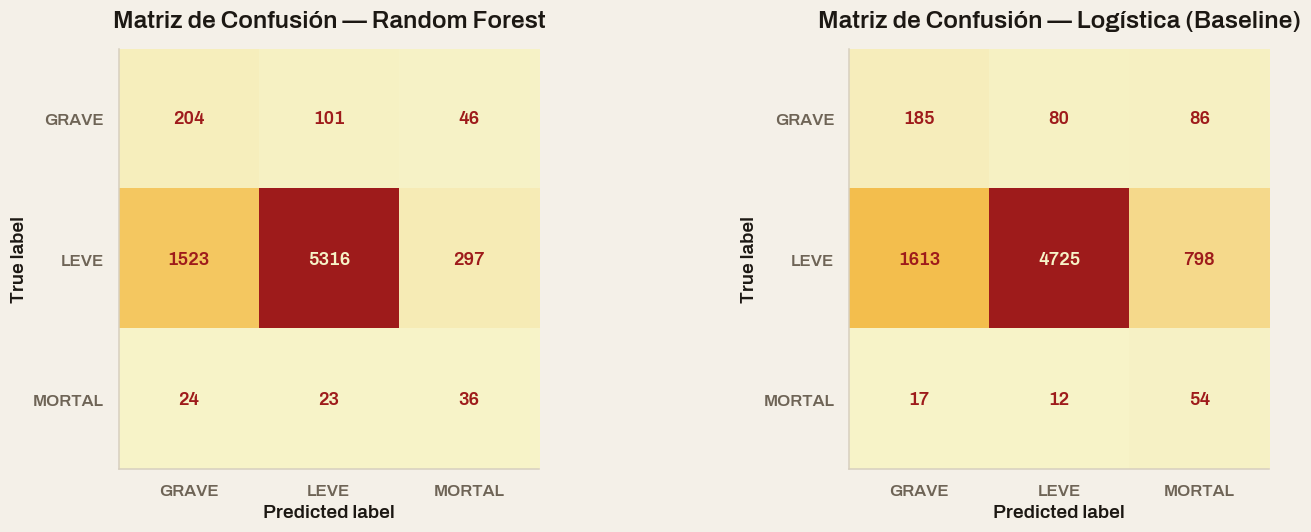

In [39]:
if 'y_pred_rf' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusión — Random Forest
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred_rf),
        display_labels=le.classes_
    ).plot(ax=axes[0], colorbar=False, cmap=CMAP_SEC)
    axes[0].grid(False)
    axes[0].set_title('Matriz de Confusión — Random Forest')

    # Matriz de confusión — Logística
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred_lr),
        display_labels=le.classes_
    ).plot(ax=axes[1], colorbar=False, cmap=CMAP_SEC)
    axes[1].grid(False)
    axes[1].set_title('Matriz de Confusión — Logística (Baseline)')

    plt.tight_layout()
    plt.savefig('outputs/matrices_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()


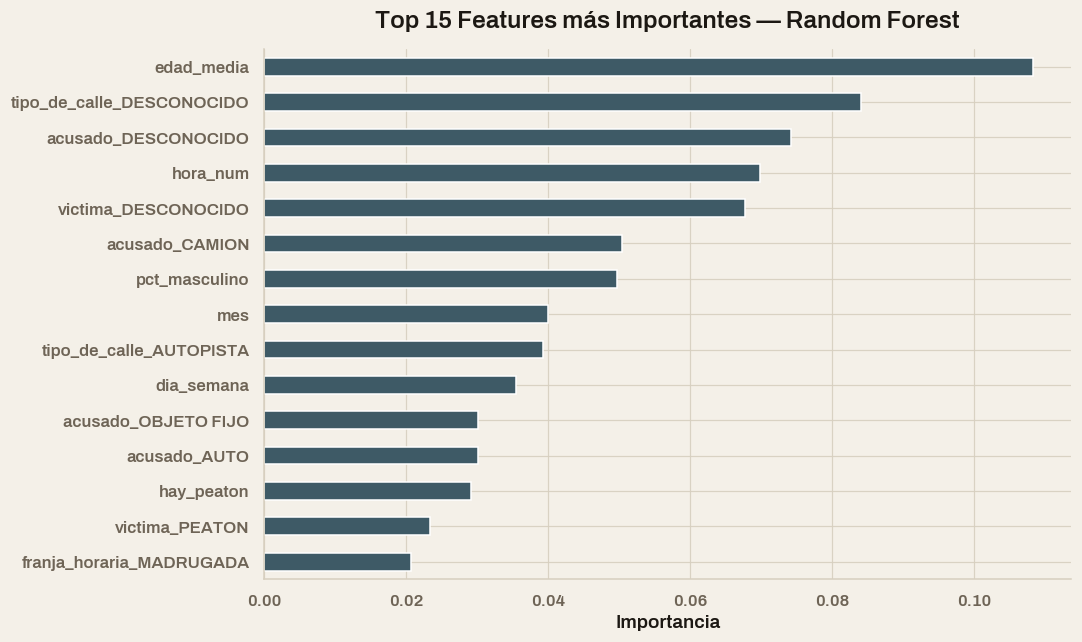

In [40]:
if 'pipeline_rf' in dir():
    # Feature importance del Random Forest
    rf_model = pipeline_rf.named_steps['classifier']
    prep = pipeline_rf.named_steps['preprocessor']

    # Obtener nombres de features post-transformación
    feature_names = []
    for name, transformer, cols in prep.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            ohe = transformer.named_steps['ohe']
            feature_names.extend(ohe.get_feature_names_out(cols))

    importances = pd.Series(rf_model.feature_importances_, index=feature_names)
    top15 = importances.nlargest(15)

    plt.figure(figsize=(10, 6))
    top15.sort_values().plot(kind='barh', color='#3E5A66', edgecolor='white')
    plt.title('Top 15 Features más Importantes — Random Forest')
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()


### 10b. Manejo del desbalance de clases

El target está muy desbalanceado: **LEVE 35.681 (94%) / GRAVE 1.752 (4,6%) / MORTAL 416 (1,1%)**. Acá aplica directo lo visto en la materia: con datasets desbalanceados la **accuracy engaña** — un modelo que predice siempre LEVE "acierta" el 94% sin detectar ni un solo caso grave. Por eso evaluamos con **matriz de confusión, precision, recall y F1-Score**, mirando especialmente el **recall** de la clase minoritaria (¿cuántos siniestros severos detecta el modelo?).

Dos decisiones para tratar el desbalance:

1. **Reagrupar el target**: con 3 clases el modelo no logra separar GRAVE de MORTAL (demasiado pocos casos de cada una). GRAVE + MORTAL → **SEVERO**, y el problema queda binario (LEVE vs SEVERO), que además tiene sentido operativo: lo que importa es detectar los siniestros severos.
2. **Ponderación de clases** (`class_weight='balanced'`): los errores sobre la clase minoritaria pesan más durante el entrenamiento, para que el modelo no la ignore. No agrega datos sintéticos ni dependencias nuevas.

> Nota: la *estandarización* (StandardScaler) ya está en el pipeline y resuelve la escala de los features, no el desbalance de clases — son problemas distintos.


── RANDOM FOREST BINARIO (LEVE vs SEVERO) ───────
              precision    recall  f1-score   support

        LEVE       0.98      0.75      0.85      7136
      SEVERO       0.15      0.70      0.24       434

    accuracy                           0.75      7570
   macro avg       0.56      0.73      0.55      7570
weighted avg       0.93      0.75      0.81      7570

Accuracy: 0.748 — engañosa con desbalance: mirar recall y F1 de SEVERO


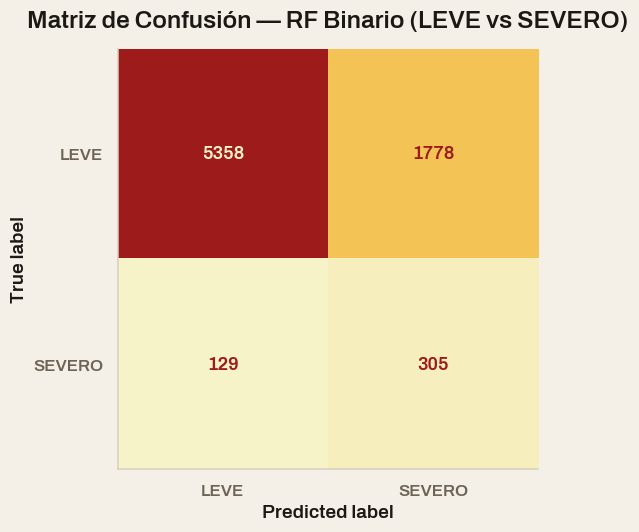

In [41]:
# Reagrupamos el target (GRAVE + MORTAL → SEVERO) y reentrenamos el mismo pipeline
from sklearn.base import clone
from sklearn.metrics import accuracy_score

if 'X' in dir() and X is not None:
    y_bin = df_final.loc[X.index, 'gravedad'].isin(['GRAVE', 'MORTAL']).map(
        {True: 'SEVERO', False: 'LEVE'})

    Xb_train, Xb_test, yb_train, yb_test = train_test_split(
        X, y_bin, test_size=0.2, random_state=42, stratify=y_bin)

    pipeline_rf_bin = Pipeline([
        ('preprocessor', clone(preprocessor)),  # clone: no pisa el preprocessor ya fiteado
        ('classifier', RandomForestClassifier(
            n_estimators=100, max_depth=10,
            class_weight='balanced', random_state=42, n_jobs=-1))
    ])
    pipeline_rf_bin.fit(Xb_train, yb_train)
    yb_pred = pipeline_rf_bin.predict(Xb_test)

    print("── RANDOM FOREST BINARIO (LEVE vs SEVERO) ───────")
    print(classification_report(yb_test, yb_pred))
    acc = accuracy_score(yb_test, yb_pred)
    print(f"Accuracy: {acc:.3f} — engañosa con desbalance: mirar recall y F1 de SEVERO")

    ConfusionMatrixDisplay(
        confusion_matrix(yb_test, yb_pred),
        display_labels=['LEVE', 'SEVERO']
    ).plot(colorbar=False, cmap=CMAP_SEC)
    plt.gca().grid(False)
    plt.title('Matriz de Confusión — RF Binario (LEVE vs SEVERO)')
    plt.tight_layout()
    plt.savefig('outputs/matriz_confusion_binario.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10c. Comparación de clasificadores (Clases 7-8) — Fase 4

¿Qué modelo da mejores resultados? Primero separamos un **test holdout del 20%** (estratificado) que queda intacto: toda la selección de modelos ocurre solo sobre el train. Sobre ese train comparamos bajo el MISMO protocolo (**validación cruzada estratificada** de 5 folds, `random_state=42`) los modelos vistos en la materia: **Árbol de Decisión** (Clase 7), **Random Forest** (Clase 8, método de ensamble) y **Regresión Logística** (Clase 9), con las métricas de clasificación de la materia: accuracy, precision, recall, F1-Score y ROC-AUC.

Los árboles usan el **índice de Gini** como criterio de impureza (el default de scikit-learn, equivalente en la práctica a la entropía) y limitamos `max_depth` / `min_samples_leaf` como **poda preventiva** contra el **sobreajuste (overfitting)**: un árbol sin límite memoriza el train y generaliza mal.

Además probamos **combinar técnicas**: una zona geográfica generada por k-means (Clase 10) como **variable sintética** del clasificador (RF + zona).

Para evitar leakage de validación, k-means se ajusta **dentro de cada fold** mediante un transformer
de scikit-learn: cada fold aprende las zonas solo con su train y asigna el fold de validación con
`predict`. Esto evita usar información geográfica del fold de validación al crear la feature.

**Resultado (tabla de abajo):** gana **RF + zona k-means** — mejor F1 de SEVERO (0.261) y mejor ROC-AUC (0.830) — y queda como **modelo final**. El árbol de depth=4 queda además como **modelo interpretable de respaldo**: detecta el 93% de los severos (recall 0.93) a costa de muchos falsos positivos — útil como screening.


In [42]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans

class KMeansZonaAdder(BaseEstimator, TransformerMixin):
    """Agrega una feature categórica `zona` aprendida solo con el train del fold.

    Esto evita el leakage leve de calcular k-means una sola vez con todo el dataset
    antes de la validación cruzada. Las columnas `lat` y `lon` se usan solo para
    asignar zona; el ColumnTransformer posterior las descarta porque no están en
    FEAT_NUM ni FEAT_CAT.
    """
    def __init__(self, n_clusters=8, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state

    def _coords_validas(self, X):
        return (X["lat"].between(-34.75, -34.52) & X["lon"].between(-58.55, -58.33))

    def fit(self, X, y=None):
        X = X.copy()
        ok = self._coords_validas(X)
        self.kmeans_ = None
        if ok.sum() >= self.n_clusters:
            self.kmeans_ = KMeans(
                n_clusters=self.n_clusters,
                random_state=self.random_state,
                n_init=10,
            ).fit(X.loc[ok, ["lat", "lon"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["zona"] = "SIN_GPS"
        ok = self._coords_validas(X)
        if self.kmeans_ is not None and ok.any():
            labels = self.kmeans_.predict(X.loc[ok, ["lat", "lon"]])
            X.loc[ok, "zona"] = [f"Z{l}" for l in labels]
        return X

if 'X' in dir() and X is not None:
    yb = (y_bin == 'SEVERO').astype(int)
    X_geo = X.copy()
    X_geo[["lat", "lon"]] = df_final.loc[X.index, ["lat", "lon"]]

    def make_prep(cats):
        return ColumnTransformer([
            ('num', Pipeline([('i', SimpleImputer(strategy='median')), ('s', StandardScaler())]), FEAT_NUM),
            ('cat', Pipeline([('i', SimpleImputer(strategy='most_frequent')),
                              ('o', OneHotEncoder(handle_unknown='ignore'))]), cats)])

    modelos = {
        'Árbol d=4 (interpretable)': Pipeline([('prep', make_prep(FEAT_CAT)),
                                                ('clf', DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42))]),
        'Árbol d=7':                 Pipeline([('prep', make_prep(FEAT_CAT)),
                                                ('clf', DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42))]),
        'Random Forest (n300,d10)':  Pipeline([('prep', make_prep(FEAT_CAT)),
                                                ('clf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                                                                 class_weight='balanced', random_state=42, n_jobs=-1))]),
        'Reg. Logística':            Pipeline([('prep', make_prep(FEAT_CAT)),
                                                ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
        'RF + zona k-means':         Pipeline([('zona', KMeansZonaAdder(n_clusters=8, random_state=42)),
                                                ('prep', make_prep(FEAT_CAT + ['zona'])),
                                                ('clf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                                                                 class_weight='balanced', random_state=42, n_jobs=-1))]),
    }

    # Protocolo limpio: el holdout (20%) se separa ANTES de la selección de modelos.
    # Toda la CV corre solo sobre el train; el test no se toca hasta la celda siguiente.
    X_geo_train, X_geo_test, yb_train, yb_test = train_test_split(
        X_geo, yb, test_size=0.2, random_state=42, stratify=yb)

    skf = StratifiedKFold(5, shuffle=True, random_state=42)
    filas = []
    for nombre, pipe in modelos.items():
        # los pipelines sin zona ignoran lat/lon (el ColumnTransformer selecciona por nombre)
        cvres = cross_validate(pipe, X_geo_train, yb_train, cv=skf, n_jobs=1,
                               scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])
        filas.append({'modelo': nombre,
                      'accuracy': cvres['test_accuracy'].mean(),
                      'precision_SEVERO': cvres['test_precision'].mean(),
                      'recall_SEVERO': cvres['test_recall'].mean(),
                      'f1_SEVERO': cvres['test_f1'].mean(),
                      'f1_std': cvres['test_f1'].std(),
                      'roc_auc': cvres['test_roc_auc'].mean()})
    tabla = pd.DataFrame(filas).set_index('modelo').round(4).sort_values('f1_SEVERO', ascending=False)
    print(tabla.to_string())


                           accuracy  precision_SEVERO  recall_SEVERO  f1_SEVERO  f1_std  roc_auc
modelo                                                                                          
RF + zona k-means            0.7708            0.1599         0.7047     0.2607  0.0113   0.8304
Random Forest (n300,d10)     0.7637            0.1560         0.7082     0.2557  0.0101   0.8263
Reg. Logística               0.7143            0.1366         0.7497     0.2311  0.0065   0.8147
Árbol d=7                    0.6486            0.1212         0.7959     0.2094  0.0235   0.7894
Árbol d=4 (interpretable)    0.4909            0.0957         0.9337     0.1736  0.0060   0.7641


── MODELO FINAL: Random Forest + zona k-means ───
              precision    recall  f1-score   support

        LEVE       0.98      0.77      0.86      7136
      SEVERO       0.16      0.73      0.26       434

    accuracy                           0.76      7570
   macro avg       0.57      0.75      0.56      7570
weighted avg       0.93      0.76      0.82      7570



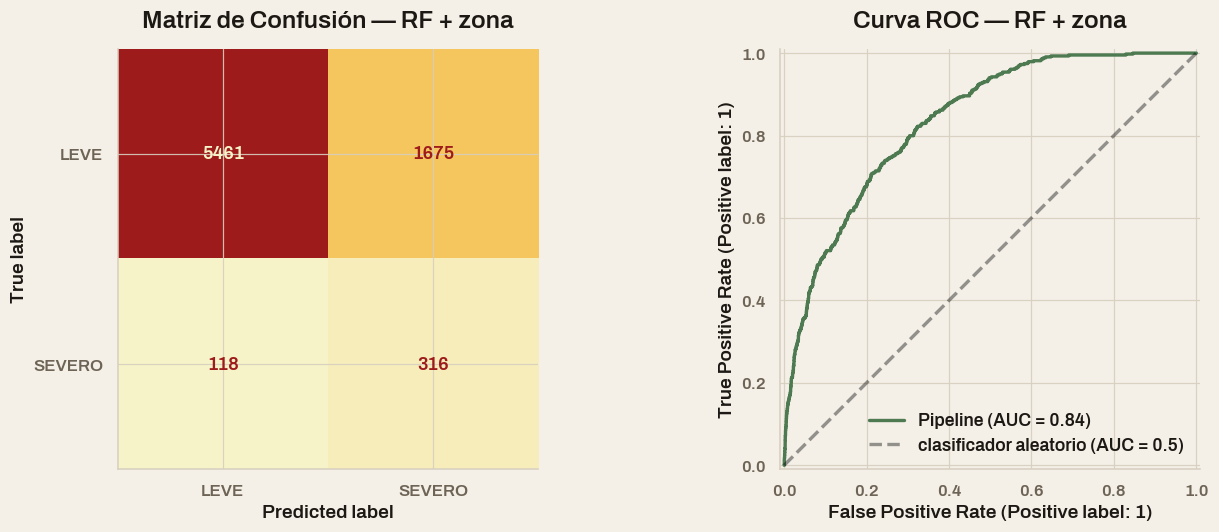

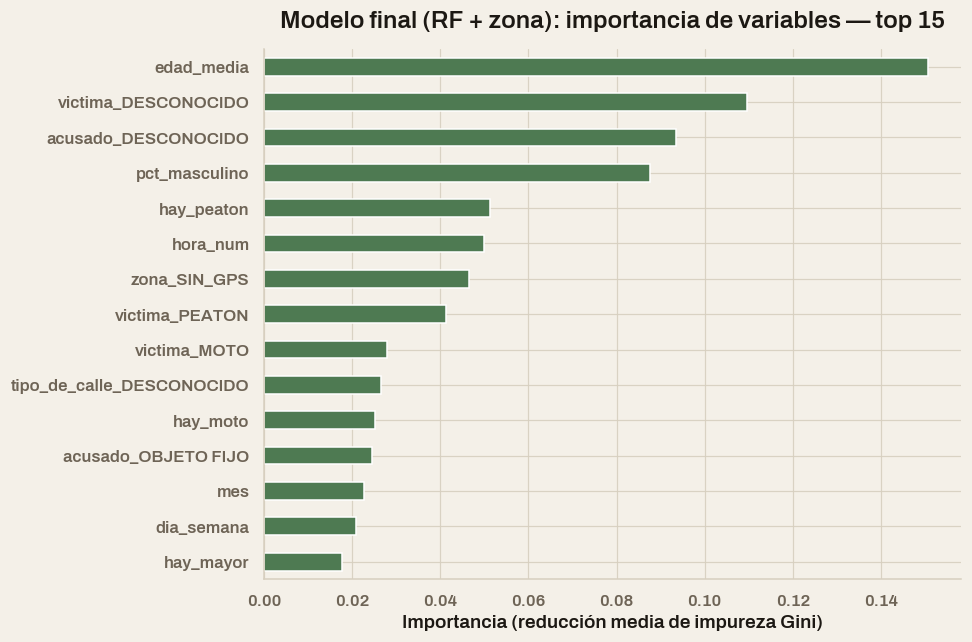


── Reglas del árbol depth=4 (primeras 20 líneas) ──
|--- cat__victima_DESCONOCIDO <= 0.50
|   |--- num__pct_masculino <= -0.50
|   |   |--- num__edad_media <= 0.05
|   |   |   |--- num__edad_media <= -0.22
|   |   |   |   |--- class: 1
|   |   |   |--- num__edad_media >  -0.22
|   |   |   |   |--- class: 0
|   |   |--- num__edad_media >  0.05
|   |   |   |--- num__hay_peaton <= 1.04
|   |   |   |   |--- class: 0
|   |   |   |--- num__hay_peaton >  1.04
|   |   |   |   |--- class: 1
|   |--- num__pct_masculino >  -0.50
|   |   |--- cat__tipo_de_calle_DESCONOCIDO <= 0.50
|   |   |   |--- num__hay_peaton <= 1.04
|   |   |   |   |--- class: 1
|   |   |   |--- num__hay_peaton >  1.04
|   |   |   |   |--- class: 1
|   |   |--- cat__tipo_de_calle_DESCONOCIDO >  0.50
|   |   |   |--- num__edad_media <= -0.03


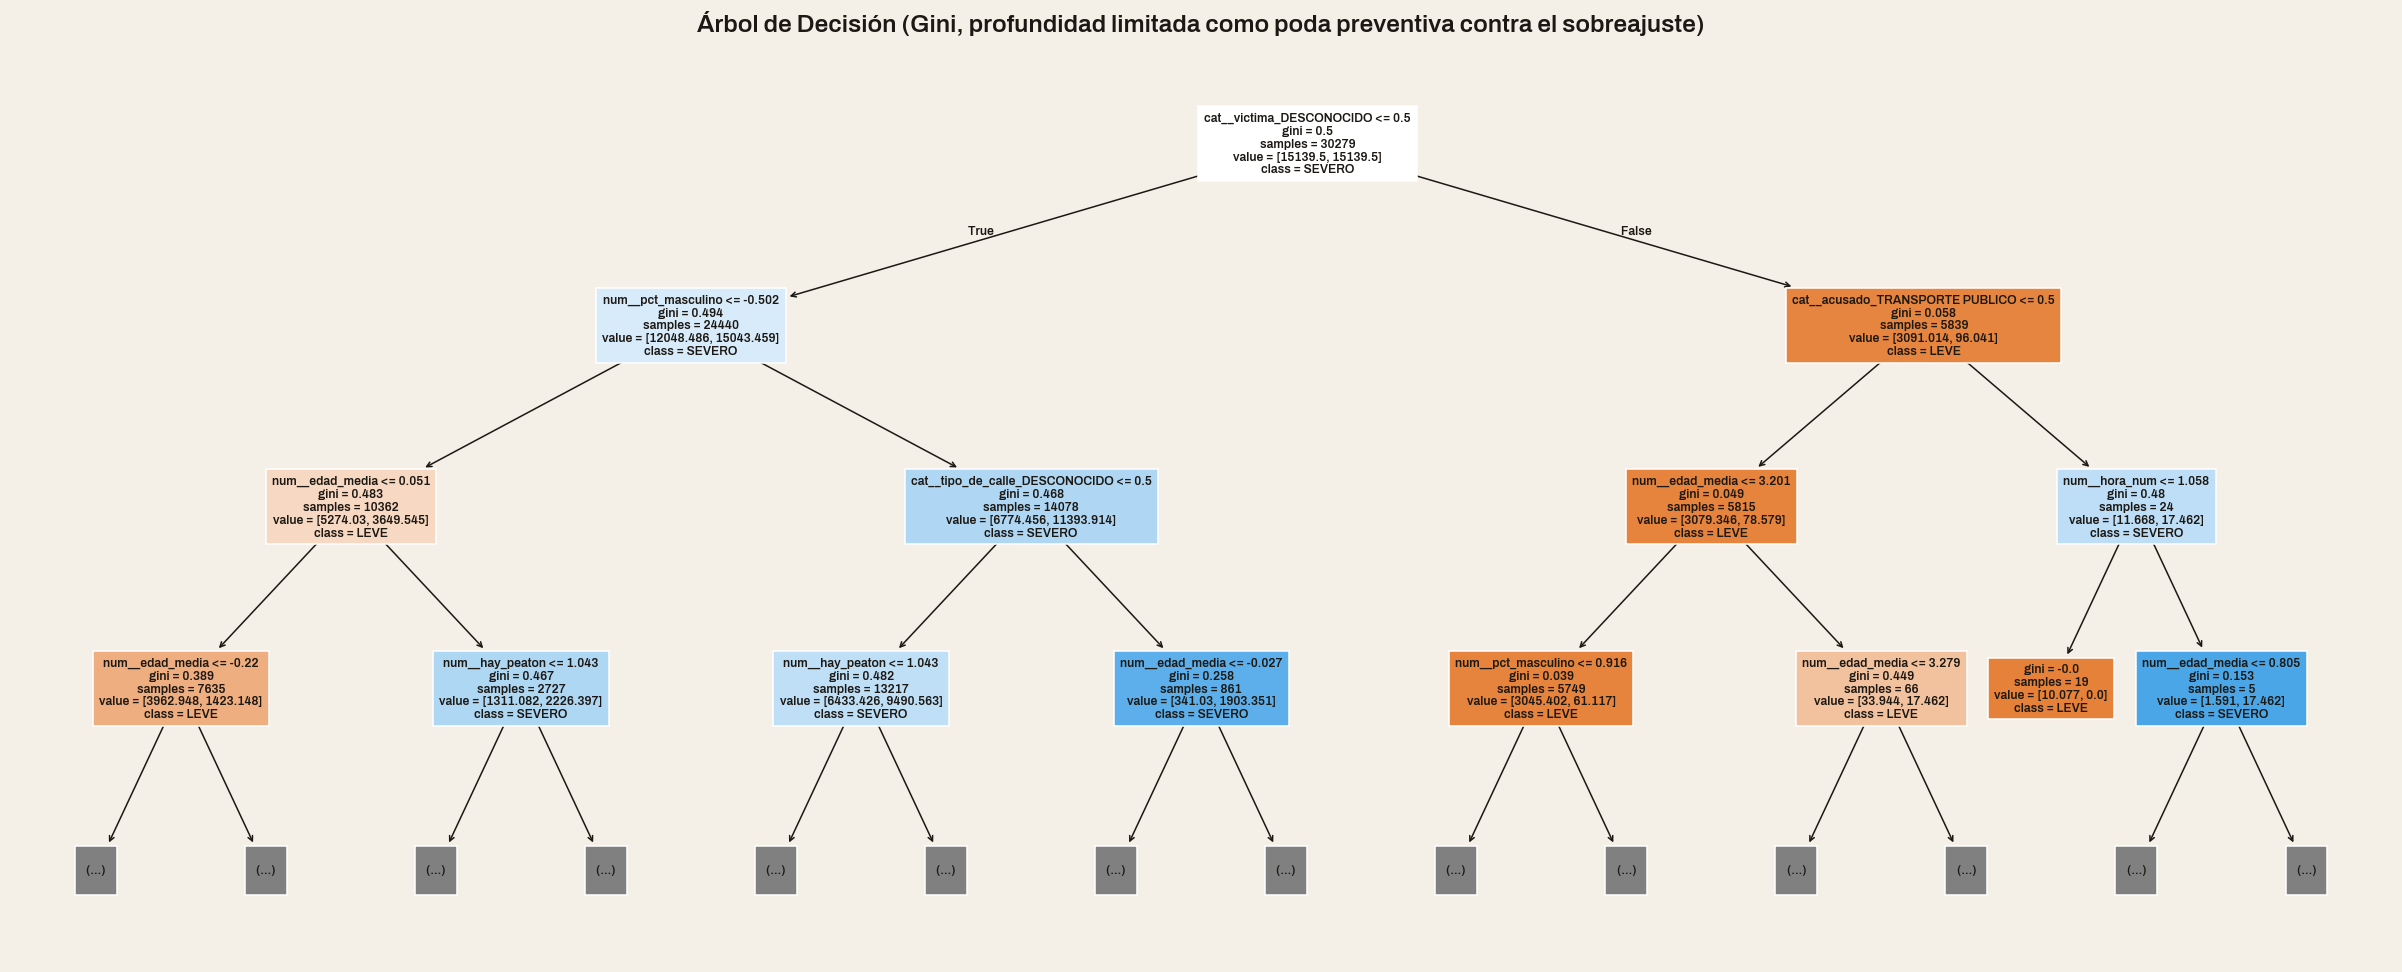

In [43]:
# ── Modelo final: Random Forest + zona | Árbol interpretable: reglas ──
if 'X_geo' in dir():
    # El split viene de la celda anterior: el test (20%) nunca participó de la selección de modelos
    Xf_train, Xf_test, yf_train, yf_test = X_geo_train, X_geo_test, yb_train, yb_test

    pipeline_rf_final = Pipeline([
        ('zona', KMeansZonaAdder(n_clusters=8, random_state=42)),
        ('prep', make_prep(FEAT_CAT + ['zona'])),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                       class_weight='balanced', random_state=42, n_jobs=-1))])
    pipeline_rf_final.fit(Xf_train, yf_train)
    yf_pred = pipeline_rf_final.predict(Xf_test)

    from sklearn.metrics import RocCurveDisplay
    print("── MODELO FINAL: Random Forest + zona k-means ───")
    print(classification_report(yf_test, yf_pred, target_names=['LEVE', 'SEVERO']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(confusion_matrix(yf_test, yf_pred),
                           display_labels=['LEVE', 'SEVERO']).plot(ax=axes[0], colorbar=False, cmap=CMAP_SEC)
    axes[0].set_title('Matriz de Confusión — RF + zona')
    RocCurveDisplay.from_estimator(pipeline_rf_final, Xf_test, yf_test, ax=axes[1], color='#4E7A52')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='clasificador aleatorio (AUC = 0.5)')
    axes[1].set_title('Curva ROC — RF + zona')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('outputs/modelo_final_rf.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Importancia de variables del MODELO FINAL (RF + zona)
    nombres = pipeline_rf_final.named_steps['prep'].get_feature_names_out()
    imp = pd.Series(pipeline_rf_final.named_steps['clf'].feature_importances_, index=nombres)
    imp = imp.sort_values(ascending=False).head(15)[::-1]
    imp.index = [n.split('__', 1)[1] for n in imp.index]
    plt.figure(figsize=(9, 6))
    imp.plot(kind='barh', color='#4E7A52', edgecolor='white')
    plt.title('Modelo final (RF + zona): importancia de variables — top 15')
    plt.xlabel('Importancia (reducción media de impureza Gini)')
    plt.tight_layout()
    plt.savefig('outputs/feature_importance_final.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Árbol interpretable (clase 7): reglas if-then con alto recall de SEVERO (screening)
    prep4 = make_prep(FEAT_CAT)
    Xt = prep4.fit_transform(Xf_train)
    arbol4 = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42).fit(Xt, yf_train)
    reglas = export_text(arbol4, feature_names=list(prep4.get_feature_names_out()))
    print("\n── Reglas del árbol depth=4 (primeras 20 líneas) ──")
    print('\n'.join(reglas.splitlines()[:20]))

    # Visualización del árbol (criterio de impureza: índice de Gini)
    plt.figure(figsize=(22, 9))
    plot_tree(arbol4, feature_names=list(prep4.get_feature_names_out()),
              class_names=['LEVE', 'SEVERO'], filled=True, fontsize=8, max_depth=3)
    plt.title('Árbol de Decisión (Gini, profundidad limitada como poda preventiva contra el sobreajuste)')
    plt.tight_layout()
    plt.savefig('outputs/arbol_decision.png', dpi=150, bbox_inches='tight')
    plt.show()


### Sesgo de registro: la completitud del dato codifica el target

Auditando el modelo encontramos un **canal de leakage sutil que hay que declarar**: la *completitud del registro* depende de la gravedad. Los siniestros graves siempre se documentan completos; muchos leves quedan con placeholders:

- la edad de la víctima (`edad_media`) falta en el **33,7% de los LEVE** pero solo en el **0,4% de los GRAVE** y **1,7% de los MORTAL**
- `victima = DESCONOCIDO` (19% del dataset) es LEVE el **99,8%** de las veces
- Donde falta `edad_media`, la tasa de SEVERO es **0,12%**; donde se conoce, **8,35%**

Consecuencia: el árbol interpretable abre exactamente por `victima_DESCONOCIDO` — el modelo aprende en parte *"qué tan documentado está el caso"*, no solo física del siniestro. Esto **no invalida** el modelo explicativo (la completitud también se conoce post-siniestro), pero **infla las métricas globales**. Para medir el poder discriminante real, re-evaluamos el modelo solo sobre los casos con datos completos de la víctima (donde este atajo no existe):

In [44]:
# ── Chequeo de robustez: el modelo sin el atajo del "sesgo de registro" ──
if 'X_geo' in dir():
    completos = (df_final.loc[X_geo.index, 'victima'].ne('DESCONOCIDO')
                 & df_final.loc[X_geo.index, 'edad_media'].notna())
    Xc, yc = X_geo[completos], yb[completos]
    print(f"Casos con datos completos de la víctima: {completos.sum():,} de {len(X_geo):,} "
          f"({completos.mean()*100:.1f}%)")
    print(f"Tasa SEVERO en el subconjunto: {yc.mean()*100:.2f}% (vs {yb.mean()*100:.2f}% global)\n")

    # Evidencia de los tres números del sesgo declarado arriba
    aux = df_final.loc[X_geo.index]
    sin_edad = aux['edad_media'].isna()
    print("Sin edad de víctima por gravedad: " + " · ".join(
        f"{g} {aux.loc[aux['gravedad'] == g, 'edad_media'].isna().mean()*100:.1f}%"
        for g in ['LEVE', 'GRAVE', 'MORTAL']))
    desconocido = aux['victima'].eq('DESCONOCIDO')
    sev_real = aux['gravedad'].isin(['GRAVE', 'MORTAL'])
    print(f"victima=DESCONOCIDO ({desconocido.mean()*100:.0f}% del dataset) es LEVE el "
          f"{aux.loc[desconocido, 'gravedad'].eq('LEVE').mean()*100:.1f}% de las veces")
    print(f"Tasa SEVERO — sin edad_media: {sev_real[sin_edad].mean()*100:.2f}% | "
          f"con edad_media: {sev_real[~sin_edad].mean()*100:.2f}%\n")

    pipe_c = Pipeline([
        ('zona', KMeansZonaAdder(n_clusters=8, random_state=42)),
        ('prep', make_prep(FEAT_CAT + ['zona'])),
        ('clf', RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=5,
                                       class_weight='balanced', random_state=42, n_jobs=-1))])
    cvc = cross_validate(pipe_c, Xc, yc, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], n_jobs=1)
    print("RF + zona, CV 5-fold SOLO sobre casos completos:")
    for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        print(f"  {m:10s}: {cvc['test_' + m].mean():.3f}")
    print("\n→ Estas son las métricas honestas del poder discriminante del modelo:"
          "\n  sin el atajo de la completitud del registro, sobre la población donde"
          "\n  el dato de la víctima existe de verdad.")

Casos con datos completos de la víctima: 21,646 de 37,849 (57.2%)
Tasa SEVERO en el subconjunto: 9.89% (vs 5.73% global)

Sin edad de víctima por gravedad: LEVE 33.7% · GRAVE 0.4% · MORTAL 1.7%
victima=DESCONOCIDO (19% del dataset) es LEVE el 99.8% de las veces
Tasa SEVERO — sin edad_media: 0.12% | con edad_media: 8.35%



RF + zona, CV 5-fold SOLO sobre casos completos:
  accuracy  : 0.794
  precision : 0.245
  recall    : 0.516
  f1        : 0.332
  roc_auc   : 0.739

→ Estas son las métricas honestas del poder discriminante del modelo:
  sin el atajo de la completitud del registro, sobre la población donde
  el dato de la víctima existe de verdad.


## 10d. Regresión: cantidad diaria de siniestros (Clase 9) — Fase 4

**Qué predecimos:** cuántos siniestros va a haber en CABA en un día dado (un número — problema de **regresión**, a diferencia de la clasificación de gravedad de la sección anterior).

**Con qué inputs:**
- **Calendario** (conocido de antemano): día de semana, mes, ¿es fin de semana?, ¿es feriado?
- **Clima del día** (pronóstico): ¿llovió?, mm de lluvia, temperatura media y máxima
- **Tránsito del mes:** vehículos por peaje (al cierre de esta sección). Ojo: el total mensual se
  conoce recién al cerrar el mes — en un uso operativo se usaría el tránsito del mes anterior o una
  proyección; acá su rol es **explicativo** (mostrar que la "tendencia" es exposición)

**Para qué sirve:** dimensionar recursos — guardias del SAME, operativos de tránsito. Ejemplo con los coeficientes del modelo: "mañana es feriado y llueve → esperá ~15 siniestros, no los ~26 de un día típico".

Comparamos los modelos de la materia — **Regresión Lineal Múltiple** (con dummies), **Árbol de Regresión** y **Random Forest de regresión** — con las métricas de la materia: **MSE, RMSE, MAE y R²**. Validación honesta con **split temporal**: train 2021-2023, test 2024 (un año nunca visto).

Hallazgo: gana la **Regresión Lineal con dummies** (los árboles no extrapolan la tendencia
creciente +35%); el efecto más fuerte no es la lluvia sino el **feriado (≈ -9,6 siniestros/día)**.

Y un paso más: la feature `tendencia` predice pero no explica. Al final de la sección la reemplazamos
por el **tránsito real del mes** (peajes, sección 7c) — si el modelo mejora, el "crecimiento" queda
explicado por su mecanismo: **exposición**.


                             MSE   RMSE    MAE     R²
modelo                                               
Lineal (dummies)          55.199  7.430  5.839  0.385
Árbol de Regresión (d=5)  68.184  8.257  6.363  0.241
RF Regressor              61.732  7.857  5.813  0.313

Coeficientes clave (siniestros/día):
  es_feriado     -9.574
  es_finde       -5.322
  llovio         -1.692
  prcp           -0.036
  tendencia      +0.008 (≈ +2.9/año)


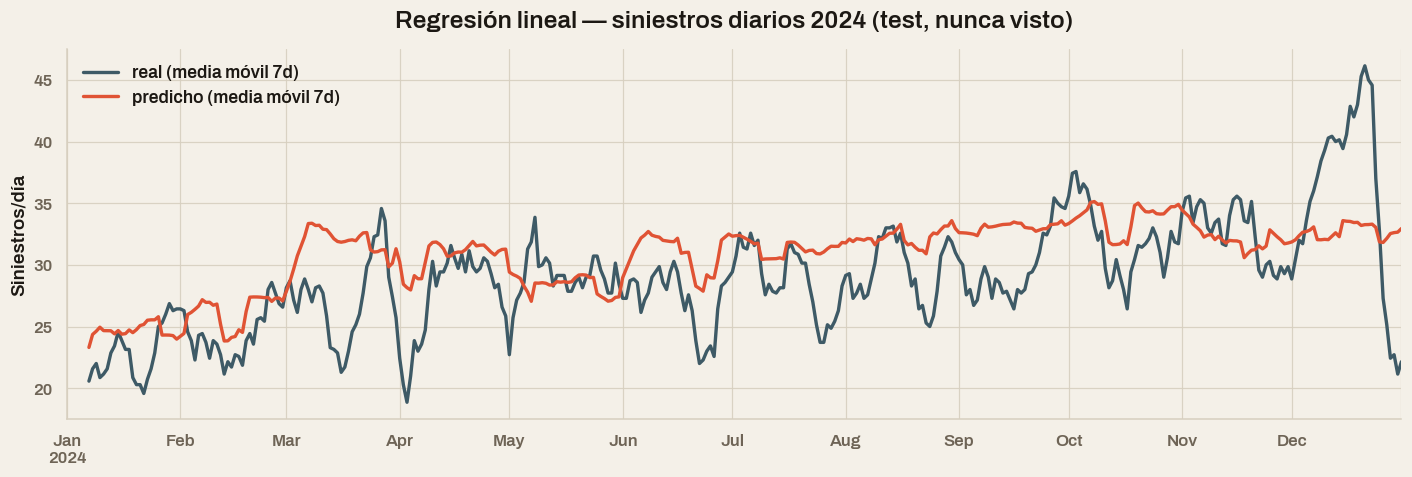

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

if df_final is not None and df_clima_diario is not None:
    # Dataset diario 2021-2024 (1461 días)
    diario = df_clima_diario[df_clima_diario['fecha'].dt.year.between(2021, 2024)][
        ['fecha', 'prcp', 'tavg', 'tmax']].copy()
    diario['llovio']       = (diario['prcp'] > 0).astype(int)
    diario['n_siniestros'] = diario['fecha'].map(df_final.groupby('fecha_siniestro').size()).fillna(0)
    diario['dia_semana']   = diario['fecha'].dt.dayofweek
    diario['mes']          = diario['fecha'].dt.month
    diario['es_finde']     = (diario['dia_semana'] >= 5).astype(int)
    diario['es_feriado']   = diario['fecha'].isin(fechas_feriado).astype(int)
    diario['tendencia']    = (diario['fecha'] - diario['fecha'].min()).dt.days

    FEAT_D = ['tendencia', 'es_finde', 'es_feriado', 'llovio', 'prcp', 'tavg', 'tmax']
    Xd = pd.get_dummies(diario[FEAT_D + ['dia_semana', 'mes']],
                        columns=['dia_semana', 'mes'], drop_first=True).astype(float)
    yd = diario['n_siniestros']
    tr = diario['fecha'].dt.year <= 2023   # train 2021-2023, test 2024

    regresores = {
        'Lineal (dummies)':         LinearRegression(),
        'Árbol de Regresión (d=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
        'RF Regressor':             RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    }
    filas = []
    for nombre, reg in regresores.items():
        reg.fit(Xd[tr], yd[tr])
        pred = reg.predict(Xd[~tr])
        mse = mean_squared_error(yd[~tr], pred)
        filas.append({'modelo': nombre,
                      'MSE': mse,
                      'RMSE': mse ** 0.5,
                      'MAE': mean_absolute_error(yd[~tr], pred),
                      'R²': r2_score(yd[~tr], pred)})
    print(pd.DataFrame(filas).set_index('modelo').round(3).to_string())

    # Coeficientes interpretables del lineal
    lin = regresores['Lineal (dummies)']
    coefs = pd.Series(lin.coef_, index=Xd.columns)
    print("\nCoeficientes clave (siniestros/día):")
    for k in ['es_feriado', 'es_finde', 'llovio', 'prcp', 'tendencia']:
        extra = ' (≈ {:+.1f}/año)'.format(coefs[k] * 365) if k == 'tendencia' else ''
        print(f"  {k:12s} {coefs[k]:+8.3f}{extra}")

    # Predicción vs real en 2024
    pred24 = pd.Series(lin.predict(Xd[~tr]), index=diario.loc[~tr, 'fecha'])
    real24 = yd[~tr].set_axis(diario.loc[~tr, 'fecha'])
    plt.figure(figsize=(13, 4.5))
    real24.rolling(7).mean().plot(color='#3E5A66', label='real (media móvil 7d)')
    pred24.rolling(7).mean().plot(color='#E05334', label='predicho (media móvil 7d)')
    plt.title('Regresión lineal — siniestros diarios 2024 (test, nunca visto)')
    plt.ylabel('Siniestros/día'); plt.xlabel('')
    plt.legend(); plt.tight_layout()
    plt.savefig('outputs/regresion_diaria.png', dpi=150, bbox_inches='tight')
    plt.show()

In [46]:
# ── ¿Y si la "tendencia" es en realidad el tránsito? ──
# La feature `tendencia` (días desde 2021) es abstracta: sube sola sin explicar POR QUÉ.
# La reemplazamos por el tránsito real del mes (peajes) y comparamos.
if df_final is not None and df_clima_diario is not None:
    pj_m = pd.read_csv(EXT + 'peajes_autopistas_idecba.csv')[['año', 'mes', 'total']]
    pj_m = pj_m.rename(columns={'total': 'veh_mes'})
    diario2 = diario.copy()
    diario2['año'] = diario2['fecha'].dt.year
    diario2 = diario2.merge(pj_m, on=['año', 'mes'], how='left')

    FEAT_T = ['veh_mes', 'es_finde', 'es_feriado', 'llovio', 'prcp', 'tavg', 'tmax']
    Xt2 = pd.get_dummies(diario2[FEAT_T + ['dia_semana', 'mes']],
                         columns=['dia_semana', 'mes'], drop_first=True).astype(float)
    # el merge resetea el índice → rehacemos la máscara temporal y usamos posiciones
    tr2 = (diario2['fecha'].dt.year <= 2023).values
    yd2 = diario2['n_siniestros'].values
    reg_t = LinearRegression().fit(Xt2[tr2], yd2[tr2])
    pred_t = reg_t.predict(Xt2[~tr2])
    mse_t = mean_squared_error(yd2[~tr2], pred_t)
    print("Lineal con TRÁNSITO mensual en lugar de tendencia:")
    print(f"  MSE {mse_t:.1f} | RMSE {mse_t**0.5:.2f} | MAE {mean_absolute_error(yd2[~tr2], pred_t):.2f}"
          f" | R² {r2_score(yd2[~tr2], pred_t):.3f}   (vs 0.385 de la tendencia abstracta)")
    coef_v = reg_t.coef_[list(Xt2.columns).index('veh_mes')]
    print(f"  Coeficiente: {coef_v * 1e6:+.2f} siniestros/día por cada millón de vehículos mensuales extra")
    print("\n→ El tránsito real no solo iguala a la tendencia: la SUPERA. La 'tendencia creciente'")
    print("  de siniestros queda explicada por su mecanismo: la recuperación del tránsito post-pandemia.")

Lineal con TRÁNSITO mensual en lugar de tendencia:
  MSE 54.2 | RMSE 7.36 | MAE 5.57 | R² 0.397   (vs 0.385 de la tendencia abstracta)
  Coeficiente: +2.87 siniestros/día por cada millón de vehículos mensuales extra

→ El tránsito real no solo iguala a la tendencia: la SUPERA. La 'tendencia creciente'
  de siniestros queda explicada por su mecanismo: la recuperación del tránsito post-pandemia.


## 10e. Aprendizaje No Supervisado (Clase 10) — Fase 4

Pasamos a **aprendizaje no supervisado**: acá no hay variable target — buscamos estructura en los datos sin etiquetar. Aplicamos las tres técnicas de la materia:

- **Clustering (k-means)** geográfico: zonas de siniestros, con el **método del codo** (inercia) para elegir k
- **PCA** (Análisis de Componentes Principales): ¿sufrimos la **maldición de la dimensionalidad**? ¿conviene reducir el espacio de features?
- **Reglas de asociación (Apriori)**: combinaciones de condiciones asociadas a SEVERO, medidas con **soporte, confianza y lift**

Nota: para la *descripción* usamos k=6 (zonas legibles); como *feature* del
clasificador usamos k=8 (en 10c, la variante con zona k=8 mejoró el CV del modelo).

*Nota metodológica: estas técnicas son **descriptivas** — se ajustan sobre el dataset completo porque no hay un conjunto de validación que contaminar. Es distinto del caso de la zona k-means usada como feature del clasificador, que sí se ajusta dentro de cada fold.*


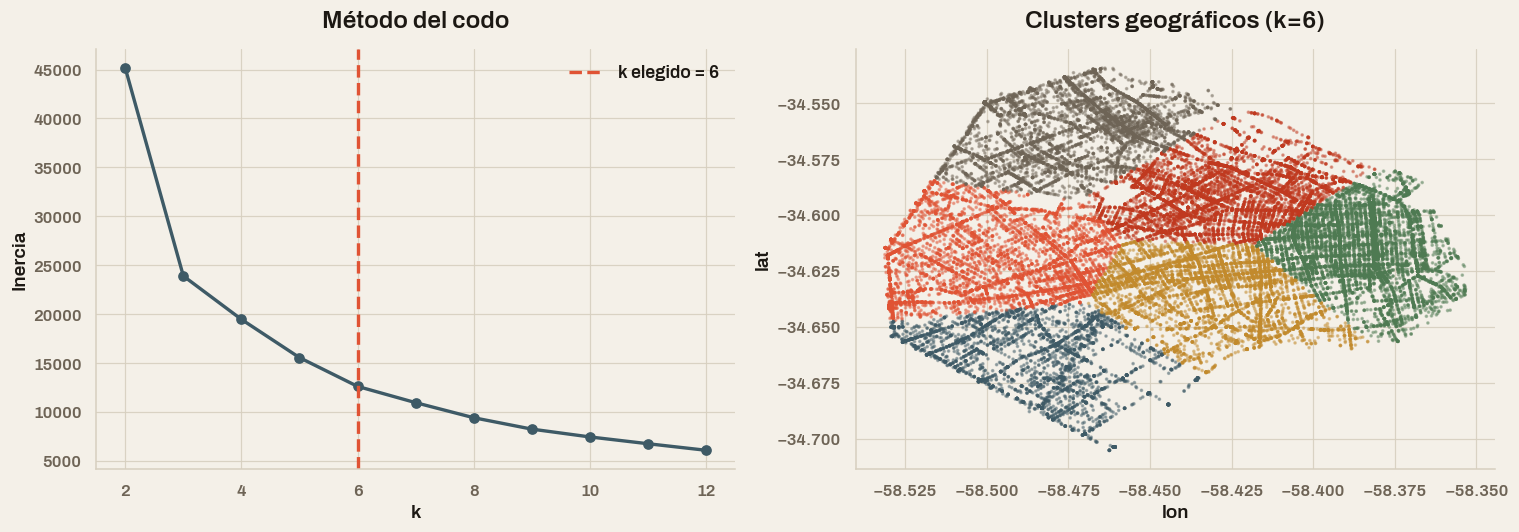

            n  pct_severo    lat    lon
cluster                                
4        5537        5.60 -34.56 -58.47
2        5693        5.25 -34.63 -58.43
1        3716        5.09 -34.66 -58.49
5        5730        5.01 -34.62 -58.50
0        6983        4.91 -34.59 -58.43
3        8543        4.74 -34.62 -58.39

Spread de severidad entre zonas: 0.86 pp → la severidad está geográficamente repartida; el VOLUMEN se concentra, la GRAVEDAD no.


In [47]:
# ── K-means geográfico: codo + clusters ──
if df_final is not None:
    geo = df_final.loc[(df_final['lat'].between(-34.75, -34.52) &
                        df_final['lon'].between(-58.55, -58.33)), ['lat', 'lon', 'gravedad']].copy()
    coords = StandardScaler().fit_transform(geo[['lat', 'lon']])

    ks = range(2, 13)
    inercias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(coords).inertia_ for k in ks]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(list(ks), inercias, 'o-', color='#3E5A66')
    axes[0].axvline(6, color='#E05334', ls='--', label='k elegido = 6')
    axes[0].set_title('Método del codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia')
    axes[0].legend()

    km6 = KMeans(n_clusters=6, random_state=42, n_init=10).fit(coords)
    geo['cluster'] = km6.labels_
    sc = axes[1].scatter(geo['lon'], geo['lat'], c=geo['cluster'], cmap=CMAP_CAT, s=2, alpha=0.4)
    axes[1].set_title('Clusters geográficos (k=6)'); axes[1].set_xlabel('lon'); axes[1].set_ylabel('lat')
    plt.tight_layout()
    plt.savefig('outputs/clusters_geograficos.png', dpi=150, bbox_inches='tight')
    plt.show()

    geo['severo'] = geo['gravedad'].isin(['GRAVE', 'MORTAL'])
    resumen = geo.groupby('cluster').agg(n=('severo', 'size'), pct_severo=('severo', 'mean'),
                                         lat=('lat', 'mean'), lon=('lon', 'mean'))
    resumen['pct_severo'] *= 100
    print(resumen.round(2).sort_values('pct_severo', ascending=False).to_string())
    print(f"\nSpread de severidad entre zonas: {resumen['pct_severo'].max()-resumen['pct_severo'].min():.2f} pp"
          " → la severidad está geográficamente repartida; el VOLUMEN se concentra, la GRAVEDAD no.")

### K-means de PERFILES: tipos de siniestro (no solo dónde, sino quién/cuándo)

El k-means geográfico mostró severidad pareja (spread 0,9 pp) — la geografía no discrimina gravedad.
Clusterizando en cambio el **perfil del siniestro** (hora, finde, edad, sexo, n víctimas,
moto/peatón/mayor) emergen **5 personas con severidades 6× distintas** (2,0% → 12,9%):

| Perfil | Quién | % SEVERO |
|---|---|---|
| **Peatón mayor** (mediana 73 años) | tarde, sin moto | **12,9%** |
| **Peatón adulto** (~36) | ~20% finde | 10,3% |
| **Moto laboral** (~32, 70% masc.) | entre semana | 7,0% |
| **Finde joven** (~32, 42% moto) | 100% finde | 6,3% |
| **Vehicular leve** (auto-auto) | sin moto ni peatón | 2,0% |

La lectura para política pública: el riesgo de gravedad no es un *lugar*, es un *tipo de siniestro*.


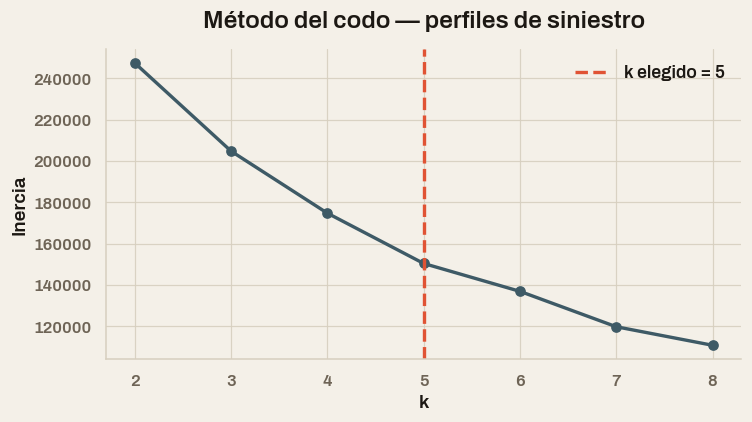


            n  pct_severo  edad_mediana  pct_masc  pct_finde  pct_moto  pct_peaton  pct_mayor
perfil                                                                                       
3        1913        12.9          73.0      41.7       21.3       5.3        41.9      100.0
1        4456        10.3          36.0      39.9       18.8       0.0       100.0        0.0
0       10834         7.0          32.0      69.6        0.0     100.0         0.0        0.0
2        6700         6.3          32.0      52.4      100.0      41.8         0.0        0.0
4       13946         2.0          35.5      41.2        0.0       0.0         0.0        0.0


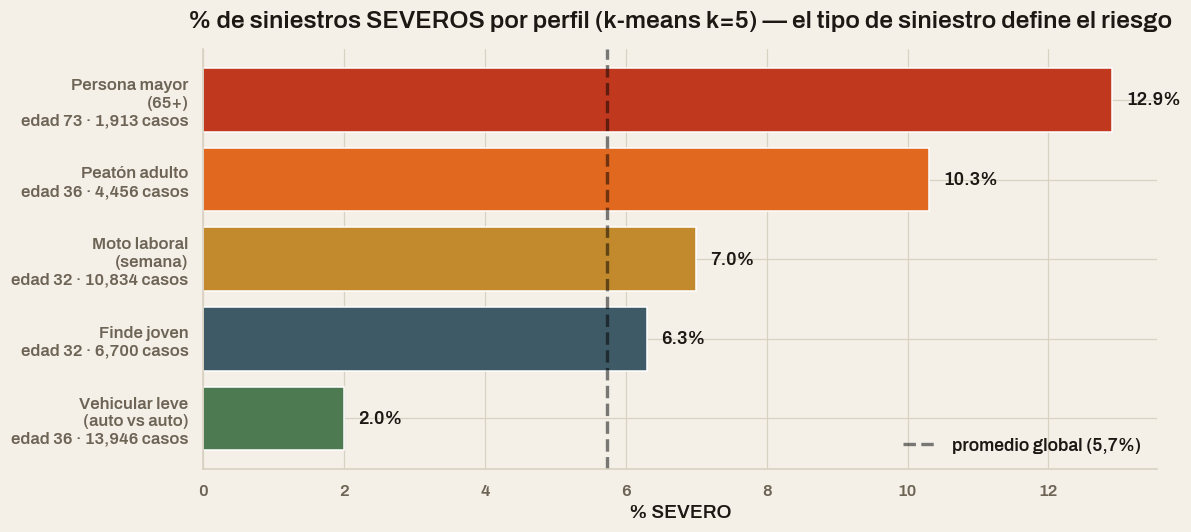


Quién es cada perfil:
  Persona mayor (65+): mediana 73 años, 42% varones, todos con víctima 65+ → 12.9% SEVERO
  Peatón adulto: mediana 36 años, 40% varones, 100% peatón → 10.3% SEVERO
  Moto laboral (semana): mediana 32 años, 70% varones, 100% moto → 7.0% SEVERO
  Finde joven: mediana 32 años, 52% varones, todos en finde → 6.3% SEVERO
  Vehicular leve (auto vs auto): mediana 36 años, 41% varones, sin moto, sin peatón, sin 65+ — choques entre vehículos → 2.0% SEVERO

Spread de severidad entre perfiles: 10.9 pp (vs el spread mínimo del k-means geográfico) → el TIPO de siniestro discrimina gravedad; el lugar, no.


In [48]:
# ── K-means de perfiles de siniestro ──
if df_final is not None:
    FEAT_PERFIL = ['hora_num', 'es_fin_semana', 'edad_media', 'pct_masculino',
                   'n_victimas', 'hay_moto', 'hay_peaton', 'hay_mayor']
    Xperf = SimpleImputer(strategy='median').fit_transform(df_final[FEAT_PERFIL])
    Xperf = StandardScaler().fit_transform(Xperf)

    # Método del codo para elegir k (mismo criterio que en el k-means geográfico)
    ks_p = range(2, 9)
    inercias_p = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xperf).inertia_ for k in ks_p]
    plt.figure(figsize=(7, 4))
    plt.plot(list(ks_p), inercias_p, 'o-', color='#3E5A66')
    plt.axvline(5, color='#E05334', ls='--', label='k elegido = 5')
    plt.title('Método del codo — perfiles de siniestro')
    plt.xlabel('k'); plt.ylabel('Inercia'); plt.legend()
    plt.tight_layout()
    plt.savefig('outputs/codo_perfiles.png', dpi=150, bbox_inches='tight')
    plt.show()

    km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(Xperf)
    df_final['perfil'] = km5.labels_
    df_final['severo'] = df_final['gravedad'].isin(['GRAVE', 'MORTAL'])

    desc = df_final.groupby('perfil').agg(
        n=('severo', 'size'), pct_severo=('severo', 'mean'), edad_mediana=('edad_media', 'median'),
        pct_masc=('pct_masculino', 'mean'), pct_finde=('es_fin_semana', 'mean'),
        pct_moto=('hay_moto', 'mean'), pct_peaton=('hay_peaton', 'mean'), pct_mayor=('hay_mayor', 'mean'))
    for c in desc.columns.drop(['n', 'edad_mediana']):
        desc[c] = (desc[c] * 100).round(1)
    desc = desc.sort_values('pct_severo', ascending=False)
    print('\n' + desc.to_string())

    # Nombrar cada perfil por su rasgo dominante (los flags binarios separan limpio)
    def nombrar(fila):
        if fila['pct_mayor'] > 50:  return 'Persona mayor\n(65+)'
        if fila['pct_peaton'] > 50: return 'Peatón adulto'
        if fila['pct_moto'] > 50 and fila['pct_finde'] < 50: return 'Moto laboral\n(semana)'
        if fila['pct_finde'] > 50:  return 'Finde joven'
        return 'Vehicular leve\n(auto vs auto)'
    desc['nombre'] = desc.apply(nombrar, axis=1)

    plt.figure(figsize=(11, 5))
    orden_plot = desc.sort_values('pct_severo')
    etiquetas = [f"{r['nombre']}\nedad {r['edad_mediana']:.0f} · {int(r['n']):,} casos"
                 for _, r in orden_plot.iterrows()]
    barras = plt.barh(etiquetas, orden_plot['pct_severo'],
                      color=['#4E7A52', '#3E5A66', '#C28A2C', '#E0681F', '#C0391F'], edgecolor='white')
    for b, v in zip(barras, orden_plot['pct_severo']):
        plt.text(v + 0.2, b.get_y() + b.get_height() / 2, f'{v:.1f}%', va='center', fontweight='bold')
    plt.axvline(df_final['severo'].mean() * 100, color='k', ls='--', alpha=0.5, label='promedio global (5,7%)')
    plt.title('% de siniestros SEVEROS por perfil (k-means k=5) — el tipo de siniestro define el riesgo')
    plt.xlabel('% SEVERO')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig('outputs/perfiles_siniestro.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nQuién es cada perfil:')
    for _, r in desc.iterrows():
        rasgos = []
        if r['pct_moto'] > 50:   rasgos.append(f"{r['pct_moto']:.0f}% moto")
        if r['pct_peaton'] > 50: rasgos.append(f"{r['pct_peaton']:.0f}% peatón")
        if r['pct_mayor'] > 50:  rasgos.append('todos con víctima 65+')
        if r['pct_finde'] > 50:  rasgos.append('todos en finde')
        if not rasgos:           rasgos.append('sin moto, sin peatón, sin 65+ — choques entre vehículos')
        print(f"  {r['nombre'].replace(chr(10), ' ')}: mediana {r['edad_mediana']:.0f} años, "
              f"{r['pct_masc']:.0f}% varones, {', '.join(rasgos)} → {r['pct_severo']:.1f}% SEVERO")
    print(f"\nSpread de severidad entre perfiles: {desc['pct_severo'].max() - desc['pct_severo'].min():.1f} pp"
          " (vs el spread mínimo del k-means geográfico) → el TIPO de siniestro discrimina gravedad; el lugar, no.")


### DBSCAN: micro-hotspots (esquinas/corredores) + tipología de comunas

En la materia se mencionaron, además de k-means, otras técnicas de clustering: **DBSCAN** (basado en
densidad, encuentra clusters de forma irregular) y el **clustering jerárquico**. Acá las usamos donde
k-means no llega:

K-means particiona TODO el espacio en zonas grandes; **DBSCAN** en cambio encuentra solo los
puntos densos: micro-concentraciones de ~60 m (esquinas, puentes, accesos). Con eps=60m y
min_samples=40 aparecen ~29 hotspots que concentran el 4,6% de los siniestros — el "top de
esquinas peligrosas", lo más accionable del análisis geográfico (los mayores están sobre los
accesos de Av. Gral. Paz en Comuna 12 y el microcentro).

Complemento: **clustering jerárquico (aglomerativo) de las 15 comunas** por su perfil (tasa, % moto,
% peatón, % nocturno, % severo) → 3 tipos: centro (1-2-3: tasa alta, severidad baja, menos moto),
oeste motero (9-10-12: tasa alta, máximo % moto) y el resto (perfil promedio).


In [49]:
# ── DBSCAN micro-hotspots + tipología de comunas ──
from sklearn.cluster import DBSCAN, AgglomerativeClustering

if df_final is not None:
    geo_h = df_final[(df_final['lat'].between(-34.75, -34.52)) &
                     (df_final['lon'].between(-58.55, -58.33))].copy()

    # eps en radianes: 60 metros sobre radio terrestre
    db = DBSCAN(eps=60 / 6_371_000, min_samples=40, metric='haversine',
                algorithm='ball_tree').fit(np.radians(geo_h[['lat', 'lon']]))
    geo_h['hotspot'] = db.labels_
    en_hot = (geo_h['hotspot'] >= 0).sum()
    print(f"Hotspots detectados: {geo_h['hotspot'].max() + 1} | "
          f"siniestros en hotspots: {en_hot:,} ({en_hot / len(geo_h) * 100:.1f}%)")

    top10 = (geo_h[geo_h['hotspot'] >= 0].groupby('hotspot')
             .agg(n=('severo', 'size'), pct_severo=('severo', 'mean'),
                  lat=('lat', 'mean'), lon=('lon', 'mean'),
                  comuna=('comuna_siniestro', lambda s: s.mode().iat[0] if len(s.mode()) else '—'))
             .sort_values('n', ascending=False).head(10))
    top10['pct_severo'] = (top10['pct_severo'] * 100).round(1)
    print('\nTop 10 hotspots (esquinas/corredores):')
    print(top10.round(4).to_string())

    # Mapa de hotspots
    import importlib.util
    if importlib.util.find_spec('folium') is not None:
        import folium
        m = folium.Map(location=[-34.61, -58.44], zoom_start=12, tiles='CartoDB positron')
        todos_hot = (geo_h[geo_h['hotspot'] >= 0].groupby('hotspot')
                     .agg(n=('severo', 'size'), pct=('severo', 'mean'),
                          lat=('lat', 'mean'), lon=('lon', 'mean')))
        for _, h in todos_hot.iterrows():
            folium.CircleMarker([h['lat'], h['lon']], radius=4 + h['n'] / 12,
                                color='#C0391F' if h['pct'] > 0.057 else '#C28A2C',
                                fill=True, fill_opacity=0.6,
                                tooltip=f"{int(h['n'])} siniestros | {h['pct']*100:.1f}% severo").add_to(m)
        m.save('outputs/mapa_hotspots.html')
        print("\n✅ Mapa de hotspots: outputs/mapa_hotspots.html (rojo = severidad sobre el promedio)")

    # ── Tipología de comunas (jerárquico, k=3) ──
    geo_h['com'] = geo_h['comuna_siniestro'].str.extract(r'(\d+)')[0].astype(float)
    df_pob_t = pd.read_csv(EXT + 'poblacion_comunas_censo2022.csv')
    prof_c = (geo_h.dropna(subset=['com']).groupby('com')
              .agg(pct_severo=('severo', 'mean'), pct_moto=('hay_moto', 'mean'),
                   pct_peaton=('hay_peaton', 'mean'),
                   pct_noche=('franja_horaria', lambda s: s.isin(['NOCHE', 'MADRUGADA']).mean()))
              .join(df_pob_t.set_index('comuna')))
    prof_c['tasa'] = geo_h.dropna(subset=['com']).groupby('com').size() / 4 / prof_c['poblacion'] * 1e5
    Zc = StandardScaler().fit_transform(prof_c[['pct_severo', 'pct_moto', 'pct_peaton', 'pct_noche', 'tasa']])
    prof_c['grupo'] = AgglomerativeClustering(n_clusters=3).fit(Zc).labels_

    print('\nTipología de comunas (jerárquico k=3):')
    for g in sorted(prof_c['grupo'].unique()):
        comunas = sorted(prof_c.index[prof_c['grupo'] == g].astype(int).tolist())
        sub = prof_c[prof_c['grupo'] == g]
        print(f"  Grupo {g}: comunas {comunas} | tasa {sub['tasa'].mean():.0f}/100k"
              f" | moto {sub['pct_moto'].mean()*100:.0f}% | peatón {sub['pct_peaton'].mean()*100:.0f}%"
              f" | severo {sub['pct_severo'].mean()*100:.1f}%")

Hotspots detectados: 29 | siniestros en hotspots: 1,676 (4.6%)

Top 10 hotspots (esquinas/corredores):
           n  pct_severo      lat      lon     comuna
hotspot                                              
5        153         4.6 -34.5497 -58.5005  COMUNA 12
8         78         2.6 -34.6094 -58.4060   COMUNA 3
25        76        11.8 -34.5395 -58.4753  COMUNA 12
12        75         2.7 -34.6222 -58.3811   COMUNA 1
10        72         1.4 -34.6197 -58.3808   COMUNA 1
11        67         3.0 -34.6270 -58.3824   COMUNA 1
9         65         6.2 -34.5700 -58.5090  COMUNA 12
17        65         4.6 -34.6176 -58.3808   COMUNA 1
18        62         4.8 -34.6307 -58.4697   COMUNA 7
7         59         5.1 -34.6863 -58.4831   COMUNA 8

✅ Mapa de hotspots: outputs/mapa_hotspots.html (rojo = severidad sobre el promedio)

Tipología de comunas (jerárquico k=3):
  Grupo 0: comunas [4, 5, 6, 7, 8, 11, 13, 14, 15] | tasa 256/100k | moto 38% | peatón 15% | severo 5.0%
  Grupo 1: comunas 

In [50]:
# ── PCA: ¿hay redundancia lineal entre las features numéricas? ──
from sklearn.decomposition import PCA

if df_final is not None:
    FEAT_PCA = ['hora_num', 'dia_semana', 'mes', 'n_victimas', 'edad_media',
                'pct_masculino', 'prcp_dia', 'temp_dia']
    Xp = SimpleImputer(strategy='median').fit_transform(df_final[FEAT_PCA])
    Xp = StandardScaler().fit_transform(Xp)
    pca = PCA().fit(Xp)

    var = pd.DataFrame({'var_explicada': pca.explained_variance_ratio_,
                        'acumulada': pca.explained_variance_ratio_.cumsum()},
                       index=[f'PC{i+1}' for i in range(len(FEAT_PCA))])
    print(var.round(3).to_string())
    n80 = (var['acumulada'] < 0.8).sum() + 1
    print(f"\nComponentes para ≥80% de varianza: {n80} de {len(FEAT_PCA)}"
          " → casi sin redundancia lineal: NO conviene reducir dimensionalidad, las features son ~ortogonales.")

    loadings = pd.DataFrame(pca.components_[:2].T, index=FEAT_PCA, columns=['PC1', 'PC2'])
    print("\nLoadings (PC1 ≈ eje estacional/climático, PC2 ≈ eje demográfico):")
    print(loadings.round(2).to_string())

     var_explicada  acumulada
PC1          0.150      0.150
PC2          0.135      0.285
PC3          0.132      0.418
PC4          0.124      0.542
PC5          0.123      0.665
PC6          0.116      0.781
PC7          0.114      0.895
PC8          0.105      1.000

Componentes para ≥80% de varianza: 7 de 8 → casi sin redundancia lineal: NO conviene reducir dimensionalidad, las features son ~ortogonales.

Loadings (PC1 ≈ eje estacional/climático, PC2 ≈ eje demográfico):
                PC1   PC2
hora_num      -0.13 -0.12
dia_semana     0.11  0.58
mes           -0.60  0.15
n_victimas     0.05  0.37
edad_media     0.04 -0.57
pct_masculino -0.08  0.37
prcp_dia       0.46  0.17
temp_dia       0.63 -0.05


In [51]:
# ── Apriori: reglas de asociación hacia SEVERO ──
import importlib.util

if df_final is not None and importlib.util.find_spec('mlxtend') is not None:
    from mlxtend.preprocessing import TransactionEncoder
    from mlxtend.frequent_patterns import apriori, association_rules

    trans = []
    for _, r in df_final[['gravedad', 'franja_horaria', 'tipo_de_calle', 'victima',
                          'acusado', 'es_fin_semana']].iterrows():
        items = [f"franja={r['franja_horaria']}", f"calle={r['tipo_de_calle']}",
                 f"vict={r['victima']}", f"acus={r['acusado']}",
                 'FINDE' if r['es_fin_semana'] else 'SEMANA']
        items.append('SEVERO' if r['gravedad'] in ('GRAVE', 'MORTAL') else 'LEVE')
        trans.append(items)

    te = TransactionEncoder()
    dft = pd.DataFrame(te.fit(trans).transform(trans), columns=te.columns_)
    freq = apriori(dft, min_support=0.01, use_colnames=True)
    reglas = association_rules(freq, metric='lift', min_threshold=1.2)

    # Reglas con consecuente exactamente {SEVERO} (antecedentes sin items de gravedad)
    hacia_severo = reglas[(reglas['consequents'] == frozenset({'SEVERO'})) &
                          (~reglas['antecedents'].apply(lambda a: any(x in ('LEVE', 'SEVERO') for x in a)))]
    top = (hacia_severo.sort_values('lift', ascending=False).head(10)
           [['antecedents', 'support', 'confidence', 'lift']])
    top['antecedents'] = top['antecedents'].apply(lambda a: ', '.join(sorted(a)))
    print("Top reglas → SEVERO (lift = cuántas veces multiplica la probabilidad base de 5,7%):")
    print(top.round(3).to_string(index=False))
else:
    print("⚠️  mlxtend no instalado: pip install mlxtend")

Top reglas → SEVERO (lift = cuántas veces multiplica la probabilidad base de 5,7%):
               antecedents  support  confidence  lift
calle=AVENIDA, vict=PEATON    0.011       0.126 2.197
          franja=MADRUGADA    0.010       0.126 2.194
               vict=PEATON    0.017       0.121 2.105
       SEMANA, vict=PEATON    0.013       0.118 2.054
                 vict=MOTO    0.028       0.079 1.371
                     FINDE    0.015       0.072 1.263
         SEMANA, vict=MOTO    0.020       0.071 1.233
      acus=AUTO, vict=MOTO    0.015       0.069 1.206


## 11. Guardar resultados


In [52]:
import pickle

# Dataset final limpio e integrado. Se exporta una versión segura para modelado,
# sin columnas que reexpresan directamente el target de gravedad.
LEAKAGE_COLS = [
    "numero_victimas_leve_siniestro",
    "numero_victimas_grave_siniestro",
    "numero_victimas_mortal_siniestro",
    "gravedad_encoded",
]

if df_final is not None:
    df_export = df_final.drop(columns=LEAKAGE_COLS, errors="ignore")
    df_export.to_csv("outputs/dataset_final_limpio.csv", index=False)
    print("✅ Dataset guardado en outputs/dataset_final_limpio.csv")
    print(f"   Columnas excluidas por leakage: {[c for c in LEAKAGE_COLS if c in df_final.columns]}")

# Modelos entrenados
if "pipeline_rf_final" in dir():
    with open("outputs/modelo_final_rf.pkl", "wb") as f:
        pickle.dump(pipeline_rf_final, f)

if "pipeline_rf" in dir():
    with open("outputs/modelo_random_forest.pkl", "wb") as f:
        pickle.dump(pipeline_rf, f)
    with open("outputs/modelo_logistica.pkl", "wb") as f:
        pickle.dump(pipeline_lr, f)
    with open("outputs/label_encoder.pkl", "wb") as f:
        pickle.dump(le, f)
    print("✅ Modelos guardados en outputs/")

print("\n🎉 Pipeline completo ejecutado exitosamente")


✅ Dataset guardado en outputs/dataset_final_limpio.csv
   Columnas excluidas por leakage: ['numero_victimas_leve_siniestro', 'numero_victimas_grave_siniestro', 'numero_victimas_mortal_siniestro', 'gravedad_encoded']
✅ Modelos guardados en outputs/

🎉 Pipeline completo ejecutado exitosamente


## 12. Resumen del Pipeline

```
[1] INGESTA LOCAL     → CSVs base en datasets/ + externos estáticos en datasets_externos/
       ↓
[2] EXPLORACIÓN       → EDA: shape, tipos, nulos, duplicados y cobertura
       ↓
[3] LIMPIEZA          → Normalización de texto, fechas, coordenadas y valores SD
       ↓
[4] INTEGRACIÓN       → Hechos + víctimas + clima diario + feriados; clima/flujo mensual documentados como negativos
       ↓
[5] FEATURE ENG.      → Franja, estación, agregados de víctimas, calendario
       ↓
[6] EDA / VALIDACIÓN  → Lluvia, tasas por comuna, exposición/tránsito, edad×finde, AUSA, mapas
       ↓
[7] MODELOS           → Clasificación (árbol / Random Forest / logística), regresión diaria, k-means, PCA, Apriori, DBSCAN
       ↓
[8] PERSISTENCIA      → CSV seguro sin leakage + modelos .pkl + gráficos/mapas regenerables
```

Las etapas se corresponden con el proceso **KDD / CRISP-DM** visto en la materia: selección y limpieza de datos (1-3), transformación (4-5), minería de datos (6-7) y evaluación/presentación (8).

### Archivos generados en `outputs/`
| Archivo | Descripción |
|---|---|
| `dataset_final_limpio.csv` | Dataset integrado exportado sin columnas que reexpresan el target |
| `modelo_final_rf.pkl` | Modelo final Random Forest + zona k-means |
| `modelo_random_forest.pkl`, `modelo_logistica.pkl` | Modelos comparativos |
| `*.png` | Gráficos estáticos del EDA y modelado |
| `*.html` | Mapas interactivos Folium |


## 13. Conclusiones finales

**Las tres preguntas del trabajo, respondidas:**

1. **¿Qué hace grave a un siniestro?** El *perfil*, no el lugar: peatón atropellado (lift ×2,1, y ×2,2 en avenida),
   víctima mayor de 65 (el perfil "persona mayor" tiene 12,9% de severidad vs 2,0% del choque vehicular leve),
   madrugada (×2,2) y la velocidad de la vía (zona 20 km/h 3,4% → calle 3,8% → avenida 5,4% → autopista 14,1%).
   El modelo final (**Random Forest + zona k-means**) detecta el **73% de los severos** en el test holdout
   (ROC-AUC 0,83); descontando el sesgo de registro, su poder discriminante honesto es **ROC-AUC 0,74**.
   Es un modelo **explicativo/screening post-siniestro**, no un predictor operativo.

2. **¿Cuántos siniestros va a haber en un día dado?** ~26 en un día típico. La **Regresión Lineal Múltiple**,
   validada sobre 2024 (año nunca visto), logra RMSE 7,36 y R² 0,397. El driver dominante es el **calendario**,
   no el clima: feriado **-9,6** siniestros/día, fin de semana -5,3, lluvia -1,7. Los árboles pierden porque
   no extrapolan la tendencia creciente.

3. **¿Manejar en CABA es más peligroso que en 2021?** Un tercio sí, dos tercios no: del +35% de siniestros,
   el tránsito explica +22% (peajes, r = 0,88 con los siniestros mensuales) y la tasa por millón de vehículos
   subió solo +10% (68 → 75). Sin normalizar por exposición, la cifra cruda engaña.

**Sobre los datos:** de los 6 datasets de la consigna, 4 no aportaban señal a su granularidad
(clima mensual, flujo de radares); se descartaron con evidencia y se reemplazaron por fuentes con la
granularidad correcta (clima diario, feriados, peajes, censo). La mejor señal del clasificador son los
**agregados de víctimas**. La lluvia **reduce la frecuencia** (-8%; -21% con >20 mm) pero **no cambia la
gravedad** del siniestro individual — confirmado en tres fuentes independientes (Meteostat diario,
Open-Meteo horario, AUSA por incidente).

**Limitaciones** (detalle en la sección 10c): sesgo de registro — la completitud del dato codifica en parte
el target —, precisión baja del screening (0,16), sin datos públicos de velocidad real ni alcoholemia,
y población residente ≠ exposición real al comparar comunas.
